In [ ]:
# [CELL 0]
# LastWave-style plotting utilities
# Faithful reproduction of LastWave's scalogram rendering from wtrans_graph.c and color.c
#
# Key ideas from the source:
#   1. Per-scale-line normalization (lglobal mode) — each scale row maps |W| independently
#      to the full colormap range, so no single scale dominates the visual
#   2. HSV colormap with power-law brightness: hue sweeps 270°→0° (blue→red),
#      value = (i/N)^0.3 gives perceptual depth without log transform
#   3. Raw |W| mapped linearly to color (no log anywhere in the display path)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap


def lastwave_colormap(n=256, name='lastwave'):
    """Build LastWave's default 'color' colormap from scripts/misc/color _CMInit.
    
    HSV construction:
        hue        = (1 - i/N) * 270   # blue (270°) → red (0°)
        saturation = 1.0
        value      = (i/N)^0.3          # power-law brightness
    """
    import matplotlib.colors as mc
    t = np.linspace(0, 1, n)
    h = (1 - t) * 270 / 360       # matplotlib wants [0,1] not degrees
    s = np.ones(n)
    v = t ** 0.3
    hsv = np.column_stack([h, s, v])
    rgb = np.array([mc.hsv_to_rgb(c) for c in hsv])
    return ListedColormap(rgb, name=name)


def lastwave_grey_colormap(n=256, name='lastwave_grey'):
    """Build LastWave's 'grey' colormap: linear black→white."""
    t = np.linspace(0, 1, n)
    rgb = np.column_stack([t, t, t])
    return ListedColormap(rgb, name=name)


def lastwave_b2r_colormap(n=256, name='lastwave_b2r'):
    """Build LastWave's 'blue2red' signed colormap from _CMInit blue2red branch.
    
    Blue→black→red with sqrt brightness ramp on each side.
    """
    half = n // 2
    extra = n % 2
    # blue side: bright blue → black
    t_blue = np.linspace(1, 0, half + extra) ** 0.5
    blue_rgb = np.column_stack([np.zeros(half + extra), np.zeros(half + extra), t_blue * 1.0])
    # red side: black → bright red
    t_red = np.linspace(0, 1, half) ** 0.5
    red_rgb = np.column_stack([t_red * 1.0, np.zeros(half), np.zeros(half)])
    rgb = np.vstack([blue_rgb, red_rgb])
    return ListedColormap(rgb, name=name)


def scalogram_lastwave(cwt_matrix, scales=None, x=None, ax=None,
                        norm_mode='lglobal', cmap=None, n_colors=256,
                        signed=False, vlim=None, causal_ranges=None,
                        interpolation='nearest', **imshow_kw):
    """Plot a CWT scalogram using LastWave's rendering approach.
    
    Parameters
    ----------
    cwt_matrix : 2D array, shape (n_scales, n_samples)
        CWT coefficients (raw, not log-transformed).
    scales : 1D array, optional
        Scale values for y-axis. If None, uses row indices.
    x : 1D array, optional
        Sample positions for x-axis. If None, uses column indices.
    ax : matplotlib Axes, optional
    norm_mode : str
        'lglobal'  — per-scale-line normalization (default, LastWave default)
        'global'   — single global normalization across all scales
        'signedglobal' — signed mode, preserves sign, symmetric around 0
    cmap : colormap, optional
        If None, uses lastwave_colormap() for unsigned or lastwave_b2r for signed.
    n_colors : int
        Number of discrete color levels.
    signed : bool
        If True, map signed values (not absolute). Forces signedglobal norm.
    vlim : (vmin, vmax), optional
        Override normalization bounds for global/signedglobal modes.
    causal_ranges : list of (first, last) tuples, optional
        Per-scale valid sample ranges (from CWT border effects).
        Samples outside range are drawn transparent.
    interpolation : str
        imshow interpolation method.
    
    Returns
    -------
    im : AxesImage
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))
    
    n_scales, n_samples = cwt_matrix.shape
    
    if signed or norm_mode == 'signedglobal':
        norm_mode = 'signedglobal'
        data = cwt_matrix.copy().astype(float)
    else:
        data = np.abs(cwt_matrix).astype(float)
    
    if cmap is None:
        if norm_mode == 'signedglobal':
            cmap = lastwave_b2r_colormap(n_colors)
        else:
            cmap = lastwave_colormap(n_colors)
    
    # Build the normalized image row by row, matching _DrawGraphWtrans
    img = np.zeros_like(data)
    
    if norm_mode == 'lglobal':
        # Per-scale normalization: each row independently
        for i in range(n_scales):
            row = data[i]
            if causal_ranges is not None:
                fp, lp = causal_ranges[i]
                valid = row[fp:lp+1]
            else:
                valid = row
            vmax = np.max(np.abs(valid)) if len(valid) > 0 else 1.0
            if vmax == 0:
                vmax = 1.0
            # LastWave: symmetric around 0, then takes |val|/valMax
            img[i] = row / vmax
    
    elif norm_mode == 'global':
        if vlim is not None:
            vmax = vlim[1]
        else:
            vmax = np.max(data)
        if vmax == 0:
            vmax = 1.0
        img = data / vmax
    
    elif norm_mode == 'signedglobal':
        if vlim is not None:
            vmin_s, vmax_s = vlim
        else:
            vmax_s = np.max(np.abs(data))
            vmin_s = -vmax_s
        if vmax_s == vmin_s:
            vmax_s = vmin_s + 1.0
        img = (data - vmin_s) / (vmax_s - vmin_s)
    
    # Mask out-of-causal-range samples
    if causal_ranges is not None:
        mask = np.ones_like(img, dtype=bool)
        for i in range(n_scales):
            fp, lp = causal_ranges[i]
            mask[i, fp:lp+1] = False
        img = np.ma.array(img, mask=mask)
        cmap.set_bad(alpha=0)
    
    # Clamp to [0,1]
    img = np.clip(img, 0, 1)
    
    # Build extent
    if x is not None:
        x0, x1 = x[0], x[-1]
    else:
        x0, x1 = 0, n_samples
    if scales is not None:
        log2s = np.log2(scales)
        if len(log2s) > 1:
            dy = log2s[1] - log2s[0]  # voice spacing in log2
        else:
            dy = 1.0
        y0 = log2s[0] - dy / 2
        y1 = log2s[-1] + dy / 2
    else:
        y0, y1 = 0, n_scales
    
    extent = [x0, x1, y0, y1]
    
    im = ax.imshow(img, aspect='auto', origin='lower', cmap=cmap,
                   extent=extent, interpolation=interpolation,
                   vmin=0, vmax=1, **imshow_kw)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    
    if scales is not None:
        n_oct = int(np.round(np.log2(scales[-1] / scales[0])))
        ax.set_ylabel('log₂(a)')
        ax.set_yticks(range(int(np.ceil(y0)), int(np.floor(y1)) + 1))
    
    ax.set_xlabel('Sample')
    
    return im


# Register colormaps globally so they can be used by name
_lw_cmap = lastwave_colormap(256)
_lw_grey = lastwave_grey_colormap(256)
_lw_b2r = lastwave_b2r_colormap(256)
try:
    plt.colormaps.register(_lw_cmap)
    plt.colormaps.register(_lw_grey)
    plt.colormaps.register(_lw_b2r)
except ValueError:
    pass  # already registered

print("LastWave plotting utilities loaded:")
print("  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'")
print("  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)")
print(f"              norm_mode='lglobal' (default) | 'global' | 'signedglobal'")
print(f"  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)")

LastWave plotting utilities loaded:
  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'
  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)
              norm_mode='lglobal' (default) | 'global' | 'signedglobal'
  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)


** Warning : Unable to read history file '/dev/null'



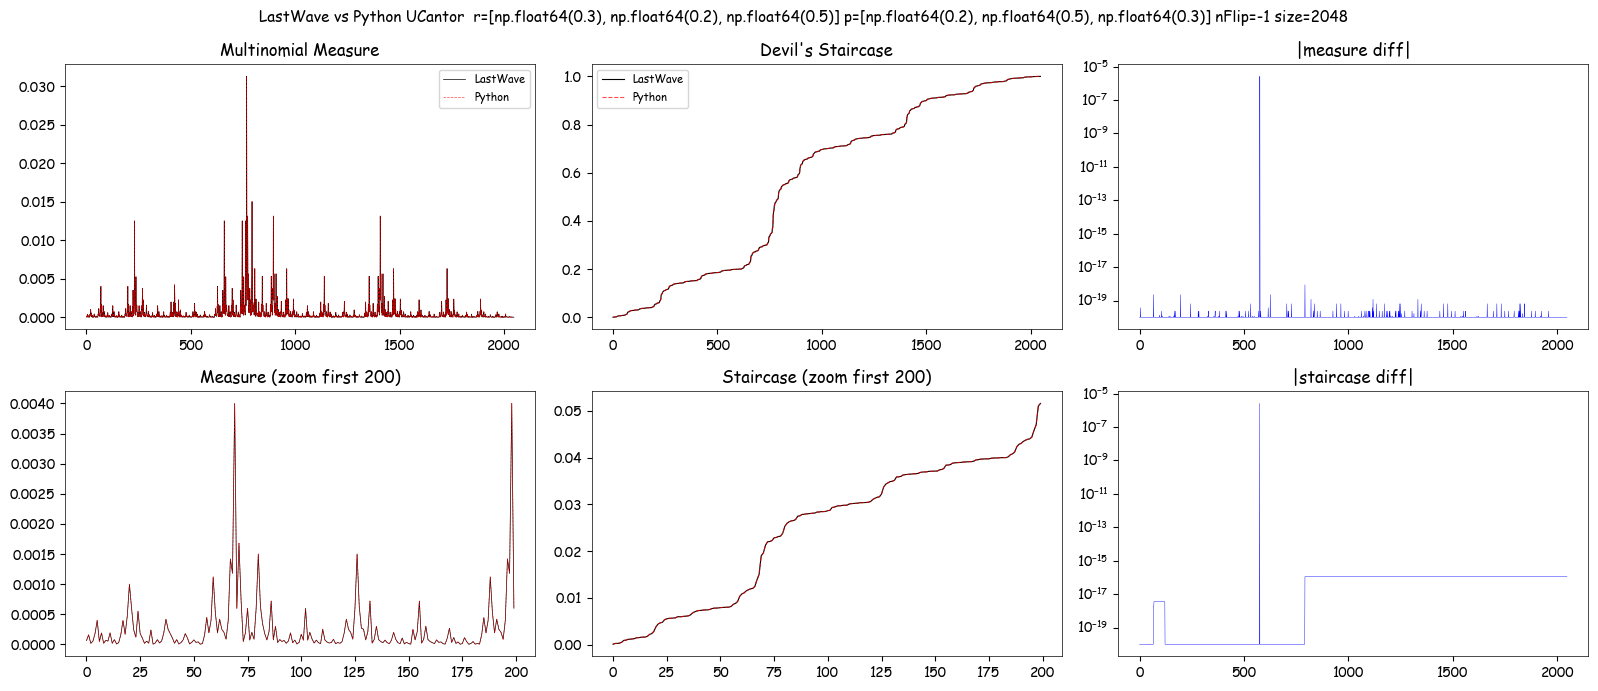

Max |measure diff|:   2.59e-06
Max |staircase diff|: 2.59e-06
Staircase range LW:   [0.000064, 1.000000]
Staircase range Py:   [0.000064, 1.000000]


Start octave 1.........
Start octave 2.........
Start octave 3.........
Start octave 4.........
Start octave 5.........


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_43282/1717371640.py:83: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


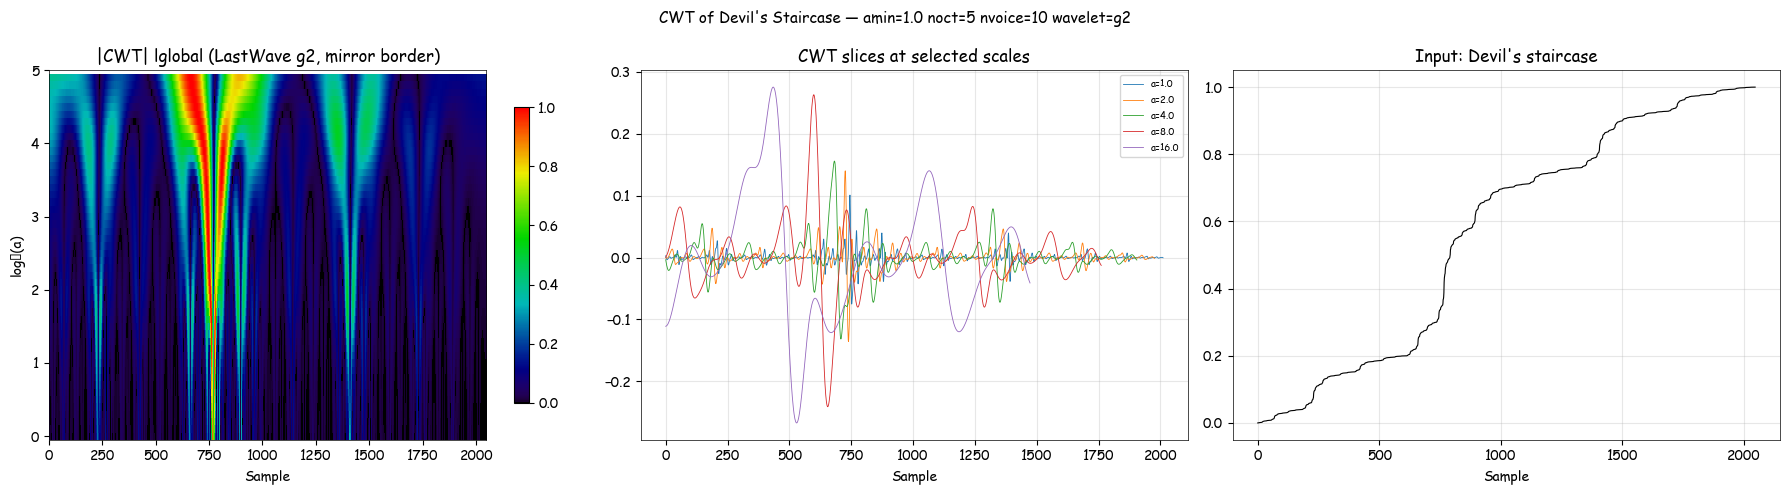

Scales: 50 total, range [1.00, 29.86]
  scale  0 (a=   1.00): valid range [18, 2029]
  scale 10 (a=   2.00): valid range [35, 2012]
  scale 20 (a=   4.00): valid range [71, 1976]
  scale 30 (a=   8.00): valid range [143, 1904]
  scale 40 (a=  16.00): valid range [287, 1760]


Total extrema found: 3645
Extracted 3645 extrema across 50 scales


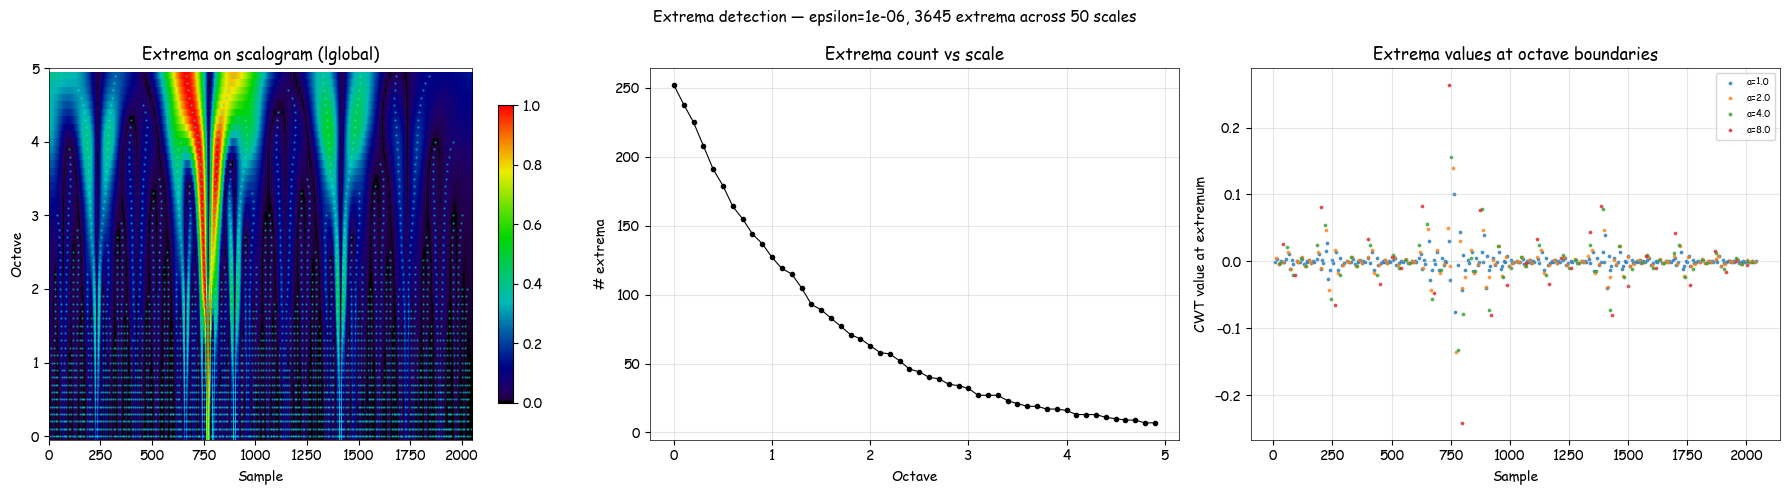


   Scale   Octave  # ext
--------------------------
    1.00    0.000    252
    2.00    1.000    127
    4.00    2.000     63
    8.00    3.000     32
   16.00    4.000     16


ChainDelete removed 0 unchained extrema
Chains remaining: 252
Extracted 252 chains, lengths: min=1, max=50, median=11


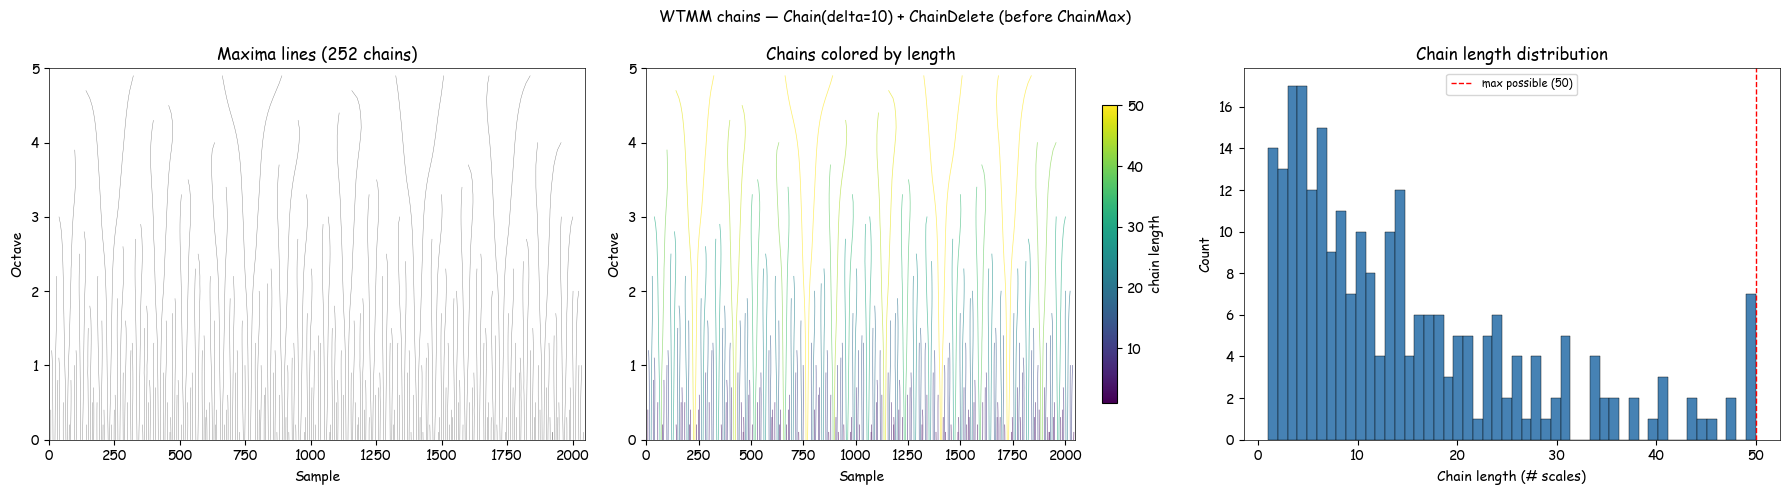

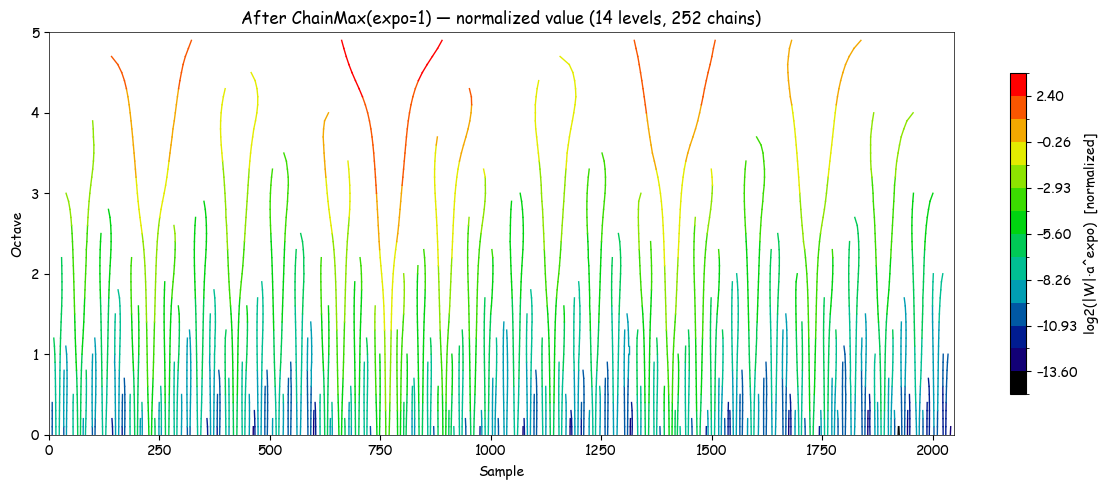

In [ ]:
# [CELL 7]
# Chains after ChainMax(expo=1) — colored by NORMALIZED value log2(|W|·a^expo)
# ChainMax guarantees monotonicity of the normalized value |W|·a^expo along each chain
# (non-increasing from fine→coarse). If ChainMax worked, each chain should appear
# as a single color or transition smoothly from warm (fine) to cool (coarse).

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14
expo = 1.0

fig, ax = plt.subplots(figsize=(12, 5))

# Compute normalized values: |ordinate| * a^expo = |ordinate| * a_min * 2^(expo * scale_idx / n_voice)
all_norm_vals = []
for ch in chains_cm:
    norm_val = np.log2(np.abs(ch['val']) + 1e-300) + expo * ch['scale_idx'] / n_voice + np.log2(a_min)
    all_norm_vals.append(norm_val)

all_norm_concat = np.concatenate(all_norm_vals)
vmin, vmax = np.percentile(all_norm_concat, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for ch, nv in zip(chains_cm, all_norm_vals):
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(nv[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2(|W|·a^expo)  [normalized]', shrink=0.8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — normalized value ({N_COLORS} levels, {len(chains_cm)} chains)')

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

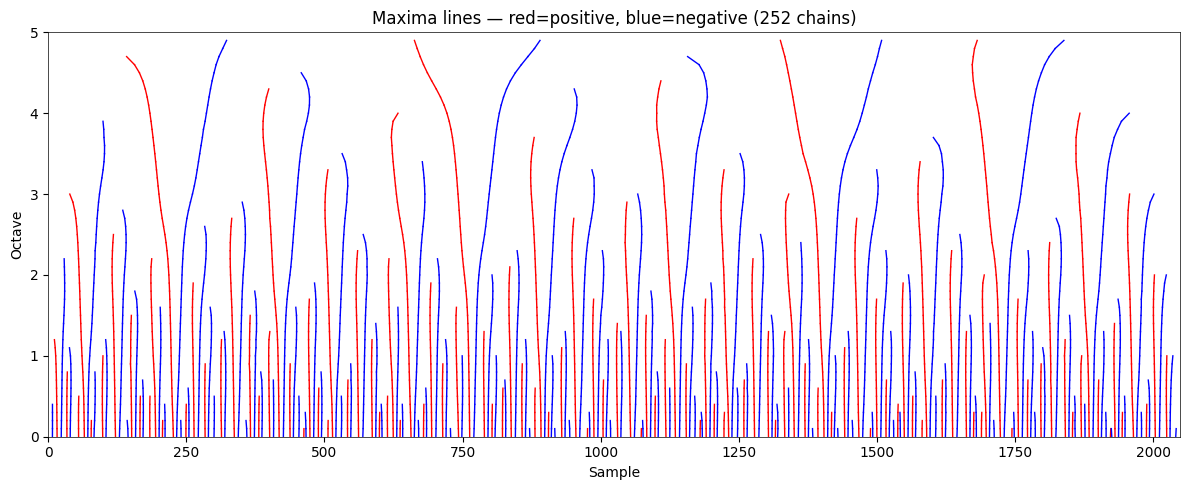

In [ ]:
# [CELL 8]
# Chains colored by sign: positive (red) / negative (blue)
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
for ch in chains:
    sign = np.sign(ch['val'])
    for j in range(len(ch['x']) - 1):
        c = 'red' if sign[j] > 0 else 'blue'
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=c, lw=1, alpha=1)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines — red=positive, blue=negative ({len(chains)} chains)')
plt.tight_layout(); plt.show()

PF computed: 50 scales done, pf_size=50, n_q=12
Spectra computed via LastWave LineFitSig over [1.0, 4.0]


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_43282/3078619312.py:106: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import brentq


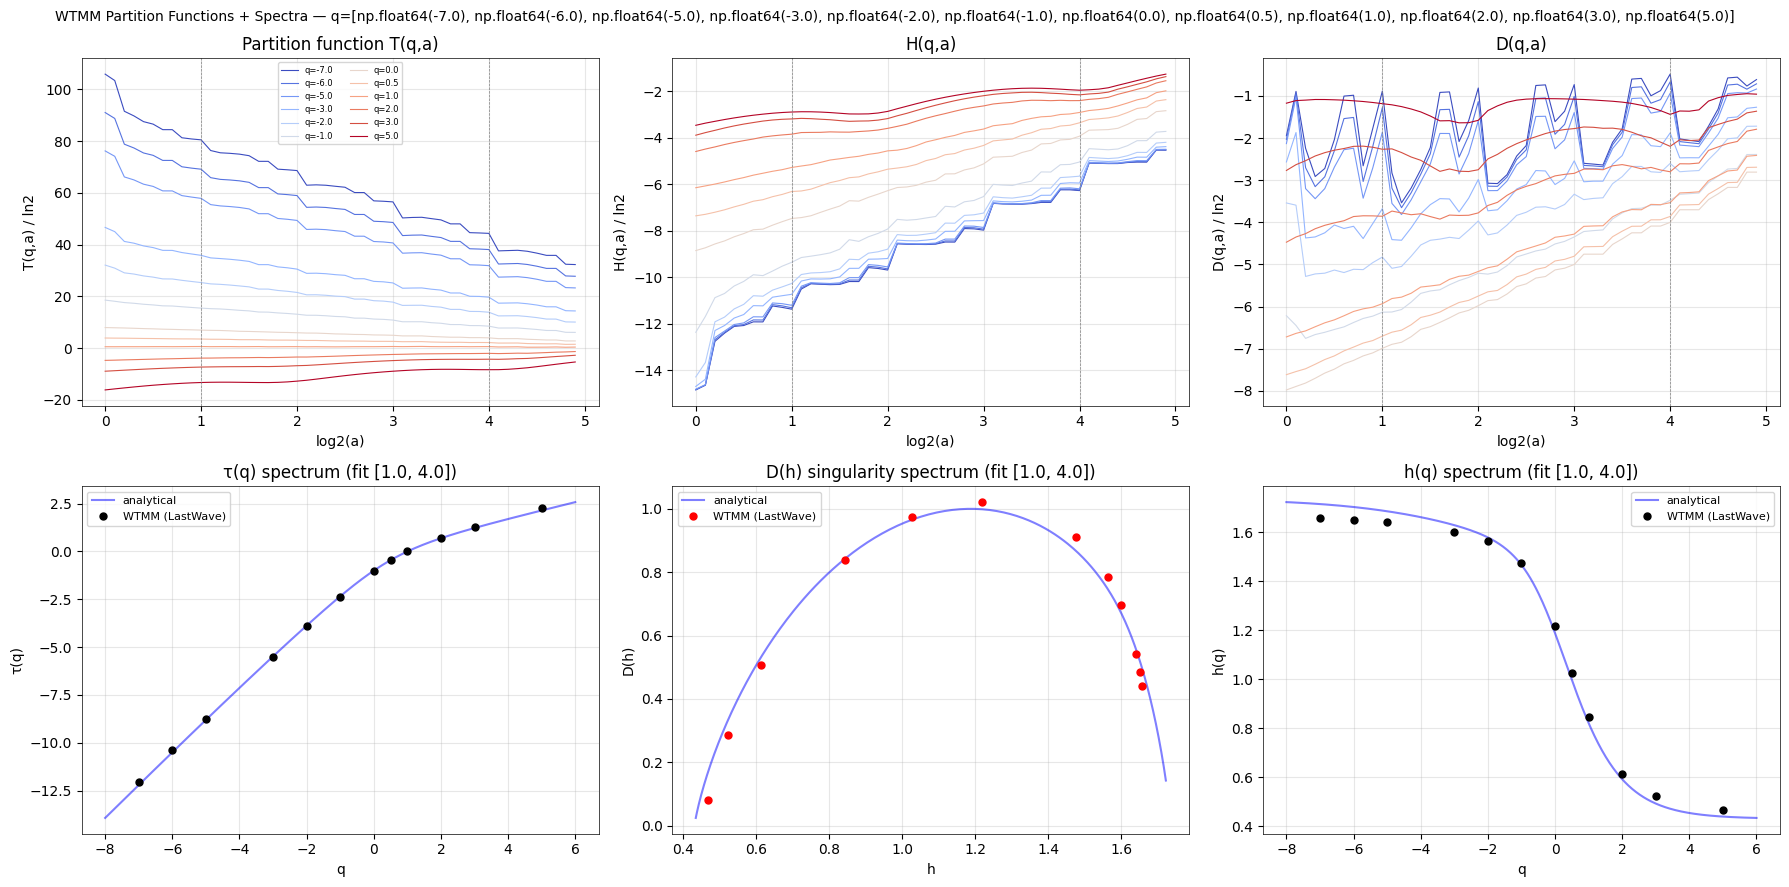


     q     tau(q)       ±σ       h(q)       ±σ       D(q)       ±σ
--------------------------------------------------------------------
  -7.0   -12.0466   0.2719     1.6581   0.0600     0.4395   0.1773
  -6.0   -10.3916   0.2159     1.6512   0.0574     0.4843   0.1563
  -5.0    -8.7454   0.1638     1.6405   0.0532     0.5431   0.1282
  -3.0    -5.4995   0.0786     1.6007   0.0388     0.6975   0.0576
  -2.0    -3.9151   0.0476     1.5648   0.0308     0.7856   0.0289
  -1.0    -2.3863   0.0235     1.4762   0.0239     0.9101   0.0128
   0.0    -1.0212   0.0094     1.2175   0.0127     1.0212   0.0094
   0.5    -0.4597   0.0071     1.0261   0.0095     0.9728   0.0094
   1.0     0.0066   0.0076     0.8444   0.0122     0.8377   0.0114
   2.0     0.7202   0.0239     0.6142   0.0280     0.5082   0.0344
   3.0     1.2812   0.0558     0.5220   0.0356     0.2849   0.0527
   5.0     2.2566   0.1230     0.4674   0.0310     0.0804   0.0360


# Faithful WTMM Implementation with GPU Acceleration

A Python reimplementation of LastWave's WTMM (Wavelet Transform Modulus Maxima) algorithm
for multifractal analysis. Faithfully matches LastWave's `CWtd()`, `extrema`, `chain`,
`chainmax`, and `pf wtmm` pipeline.

**GPU**: PyTorch MPS on Apple Silicon M2 Max

In [ ]:
# Cell 10: Imports and device setup
#
# Fix duplicate libomp crash (torch + numba both link OpenMP on macOS)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64


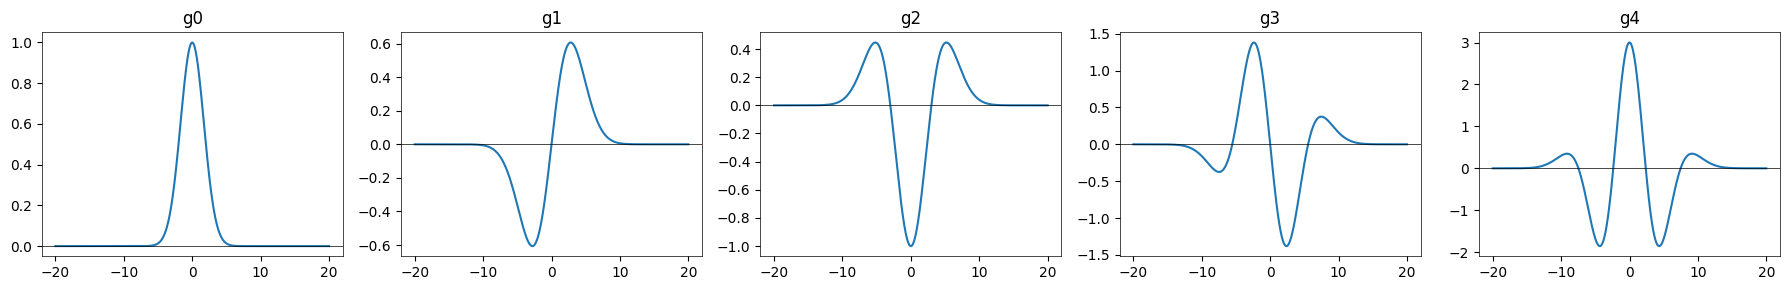

In [ ]:
# Cell 11: Gaussian derivative wavelets (faithful to LastWave wt1d_collection.c)
#
# Each wavelet has a stretch factor (gNfact) baked into the wavelet definition.
# No intrinsic normalization -- all normalization comes from expo parameter AFTER convolution.
# Support ranges determine filter truncation.

WAVELETS = {
    'g0': {
        'fact': 1.7,
        'func': lambda u: np.exp(-u**2 / 2),
        'x_min_factor': -np.sqrt(2 * np.log(10)) * 2.44949,  # -gfact*sqrt2log10*geps
        'x_max_factor':  np.sqrt(2 * np.log(10)) * 2.44949,
    },
    'g1': {
        'fact': 2.8,
        'func': lambda u: u * np.exp(-u**2 / 2),
        'x_min_factor': -6.0,
        'x_max_factor':  6.0,
    },
    'g2': {
        'fact': 3.0,
        'func': lambda u: (u**2 - 1) * np.exp(-u**2 / 2),
        'x_min_factor': -6.0,
        'x_max_factor':  6.0,
    },
    'g3': {
        'fact': 3.2,
        'func': lambda u: -u * (3 - u**2) * np.exp(-u**2 / 2),
        'x_min_factor': -6.3,
        'x_max_factor':  6.3,
    },
    'g4': {
        'fact': 3.2,
        'func': lambda u: (3 - 6*u**2 + u**4) * np.exp(-u**2 / 2),
        'x_min_factor': -6.4,
        'x_max_factor':  6.4,
    },
}

def wavelet_direct(x, a, wavelet_name='g2'):
    """Evaluate wavelet in direct space: psi(x / (a * gNfact))
    Matches LastWave's d_r_dN_gauss functions exactly.
    """
    w = WAVELETS[wavelet_name]
    u = x / (a * w['fact'])
    return w['func'](u)

def wavelet_support(a, wavelet_name='g2'):
    """Return (d_x_min, d_x_max) for the wavelet at scale a.
    These are the physical-space support bounds.
    """
    w = WAVELETS[wavelet_name]
    return a * w['x_min_factor'] * w['fact'], a * w['x_max_factor'] * w['fact']

# Quick test: plot g2 at scale a=1
x_test = np.linspace(-20, 20, 1000)
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
for i, name in enumerate(['g0', 'g1', 'g2', 'g3', 'g4']):
    axes[i].plot(x_test, wavelet_direct(x_test, 1.0, name))
    axes[i].set_title(name)
    axes[i].axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: CWT engine — FFTW overlap-save matching LastWave's cv_n_real_mp()
#
# Key algorithm from cv_n.c cv_n_real_mp:
#   1. part_size = next_power_of_2(2 * filter_size)
#   2. Periodic-extend filter to part_size, FFT once
#   3. For each overlapping part of signal:
#      a. Extract part_size chunk with mirror border handling
#      b. FFT, multiply, IFFT
#      c. Copy exact (non-contaminated) portion to result
#
# Mirror border (from cv_misc.c _get_part_r_mi_):
#   Left:  signal[-k] = signal[k]        (reflect around index 0, no edge repeat)
#   Right: reversed copy of entire signal (signal[N-1], ..., signal[0])
#          then normal copy, alternating
#
# Uses pyfftw.interfaces.numpy_fft for FFTW speed with correct normalization.

import pyfftw
pyfftw.interfaces.cache.enable()
pyfftw.interfaces.cache.set_keepalive_time(300)

FFTW_THREADS = max(1, os.cpu_count() // 2)

# Use pyfftw as drop-in replacement for numpy.fft (handles normalization correctly)
_rfft  = lambda x: pyfftw.interfaces.numpy_fft.rfft(x, threads=FFTW_THREADS)
_irfft = lambda x, n: pyfftw.interfaces.numpy_fft.irfft(x, n=n, threads=FFTW_THREADS)


def _next_power_of_2(n):
    """Smallest power of 2 >= n."""
    p = 1
    while p < n:
        p <<= 1
    return p


def _get_part_mirror(signal_data, signal_size, part_begin, part_size):
    """Extract a part of the signal with mirror border handling.
    
    Exact translation of LastWave's _get_part_r_mi_() from cv_misc.c.
    Left border:  signal[-j] for j < 0  (reflect, no edge repeat)
    Right border: reversed copy then normal copy, alternating
    """
    part = np.empty(part_size, dtype=np.float64)
    i = 0
    j = part_begin

    # Left border
    while j < 0:
        part[i] = signal_data[-j]
        i += 1
        j += 1

    # Middle
    tmp_n = min(part_size - i, signal_size - j)
    if tmp_n > 0:
        part[i:i + tmp_n] = signal_data[j:j + tmp_n]
        i += tmp_n
        j += tmp_n

    # Right border: alternating mirrored and normal copies
    while i < part_size:
        # Mirrored (reversed) copy
        tmp_n = min(part_size - i, signal_size)
        k = signal_size - 1
        for _ in range(tmp_n):
            if i >= part_size:
                break
            part[i] = signal_data[k]
            k -= 1
            i += 1

        # Normal copy
        if i < part_size:
            tmp_n = min(part_size - i, signal_size)
            part[i:i + tmp_n] = signal_data[:tmp_n]
            i += tmp_n

    return part


def _periodic_extend_filter(filter_data, filter_begin, filter_end, new_size):
    """Periodic-extend filter, matching cv_pure_periodic_extend_() from cv_misc.c.
    
    filter_data: array of length (filter_end - filter_begin + 1)
    filter_begin: negative (= -sizeD)
    filter_end: positive (= sizeG)
    
    source = filter_data offset so source[0..end] and source[begin..-1] are valid.
    Result[0..end]                    = source[0..end]         (positive part)
    Result[end+1..new_size+begin-1]   = 0                      (zero fill)
    Result[new_size+begin..new_size-1] = source[begin..-1]     (negative part wrapped)
    """
    result = np.zeros(new_size, dtype=np.float64)
    # source pointer: source = filter_data - filter_begin
    # source[i] = filter_data[i - filter_begin]

    # Positive part: result[0..filter_end]
    for i in range(filter_end + 1):
        result[i] = filter_data[i - filter_begin]

    # Negative part: result[new_size+filter_begin..new_size-1]
    for i in range(new_size + filter_begin, new_size):
        result[i] = filter_data[i - new_size - filter_begin]

    return result


def cwtd_fftw(signal, a_min, n_oct, n_voice, wavelet_name='g2', expo=-1.0):
    """CWT using FFTW overlap-save, matching LastWave's cv_n_real_mp() exactly.
    
    Returns
    -------
    coeffs : 2D numpy array (float64), shape (n_scales, signal_size)
    scales : 1D numpy array of scale values
    valid_ranges : list of (firstp, lastp) tuples per scale
    """
    size = len(signal)
    factor = 2.0 ** (1.0 / n_voice)
    n_scales = n_oct * n_voice

    w = WAVELETS[wavelet_name]
    d_x_min = w['x_min_factor'] * w['fact']  # negative
    d_x_max = w['x_max_factor'] * w['fact']  # positive

    coeffs = np.zeros((n_scales, size), dtype=np.float64)
    scales_arr = np.zeros(n_scales, dtype=np.float64)
    valid_ranges = []

    a = float(a_min)
    for idx in range(n_scales):
        scales_arr[idx] = a

        sizeD = int(a * d_x_max)
        sizeG = int(-a * d_x_min)
        sizeTot = sizeD + sizeG + 1

        if sizeTot > size:
            raise ValueError(f'Filter size {sizeTot} > signal size {size} at scale {a:.2f}')

        # Valid range (matching cwt1d.c firstp/lastp calculation)
        firstp = sizeG
        lastp = size - 1 - sizeD
        valid_ranges.append((firstp, lastp))

        # Build reversed filter (matching CWtd: filter[sizeTot-i-1] = wavelet(i-sizeG, a))
        filt = np.zeros(sizeTot, dtype=np.float64)
        for i in range(sizeTot):
            filt[sizeTot - i - 1] = wavelet_direct(float(i - sizeG), a, wavelet_name)

        # Filter index range: begin = -sizeD (negative), end = sizeG (positive)
        # Matching cv_flt_init_n(CV_RC_FORM, sizeTot, sizeD, ...)
        filter_begin = -sizeD
        filter_end = sizeG

        # Overlap-save parameters (matching cv_n_real_mp)
        part_size = _next_power_of_2(2 * sizeTot)
        size_of_exact_data = part_size - sizeTot + 1

        # Periodic-extend filter and FFT once
        filt_ext = _periodic_extend_filter(filt, filter_begin, filter_end, part_size)
        filt_ft = _rfft(filt_ext)

        # Process signal in overlapping parts
        nb_of_parts = int(np.ceil(size / size_of_exact_data))
        result = np.zeros(size, dtype=np.float64)

        for part_nb in range(nb_of_parts):
            part_begin = part_nb * size_of_exact_data - filter_end

            # Extract part with mirror border
            sig_part = _get_part_mirror(signal, size, part_begin, part_size)

            # FFT, multiply, IFFT (normalization handled by irfft)
            sig_ft = _rfft(sig_part)
            prod_ft = sig_ft * filt_ft
            conv_result = _irfft(prod_ft, part_size)

            # Copy exact (non-contaminated) portion to result
            copy_start = part_nb * size_of_exact_data
            if part_nb < nb_of_parts - 1:
                copy_len = size_of_exact_data
            else:
                copy_len = size - copy_start

            result[copy_start:copy_start + copy_len] = \
                conv_result[filter_end:filter_end + copy_len]

        # Apply a^expo normalization (matching CWtd)
        mult = a ** expo
        coeffs[idx] = result * mult

        a *= factor

    return coeffs, scales_arr, valid_ranges


# Keep the old direct-convolution cwtd for comparison
def cwtd(signal, a_min, n_oct, n_voice, wavelet_name='g2', expo=-1.0, border='mirror'):
    """Direct convolution CWT (original torch-based)."""
    size = len(signal)
    factor = 2.0 ** (1.0 / n_voice)
    n_scales = n_oct * n_voice

    w = WAVELETS[wavelet_name]
    d_x_min = w['x_min_factor'] * w['fact']
    d_x_max = w['x_max_factor'] * w['fact']

    scales = np.zeros(n_scales)
    filters = []
    filter_sizes = []

    a = float(a_min)
    for idx in range(n_scales):
        scales[idx] = a
        sizeD = int(a * d_x_max)
        sizeG = int(-a * d_x_min)
        sizeTot = sizeD + sizeG + 1
        if sizeTot > size:
            raise ValueError(f'Filter size {sizeTot} > signal size {size}')
        filt = np.zeros(sizeTot)
        for i in range(sizeTot):
            filt[sizeTot - i - 1] = wavelet_direct(float(i - sizeG), a, wavelet_name)
        filters.append(filt)
        filter_sizes.append((sizeTot, sizeD, sizeG))
        a *= factor

    coeffs = np.zeros((n_scales, size))
    valid_ranges = []
    sig_np = signal.copy()

    for idx in range(n_scales):
        sizeTot, sizeD, sizeG = filter_sizes[idx]
        filt = filters[idx]
        firstp = sizeG
        lastp = size - 1 - sizeD
        valid_ranges.append((firstp, lastp))
        sig_t = torch.tensor(sig_np, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
        sig_padded = torch.nn.functional.pad(sig_t, (sizeG, sizeD), mode='reflect')
        filt_t = torch.tensor(filt, dtype=torch.float64).unsqueeze(0).unsqueeze(0)
        result = torch.nn.functional.conv1d(sig_padded, filt_t)
        mult = scales[idx] ** expo
        coeffs[idx] = (result.squeeze() * mult).cpu().numpy()

    return coeffs, scales, valid_ranges


print(f'CWT engines defined. FFTW threads: {FFTW_THREADS}')
print(f'  cwtd_fftw() — overlap-save FFT via pyfftw (matches LastWave cv_n_real_mp)')
print(f'  cwtd()      — direct convolution via torch')


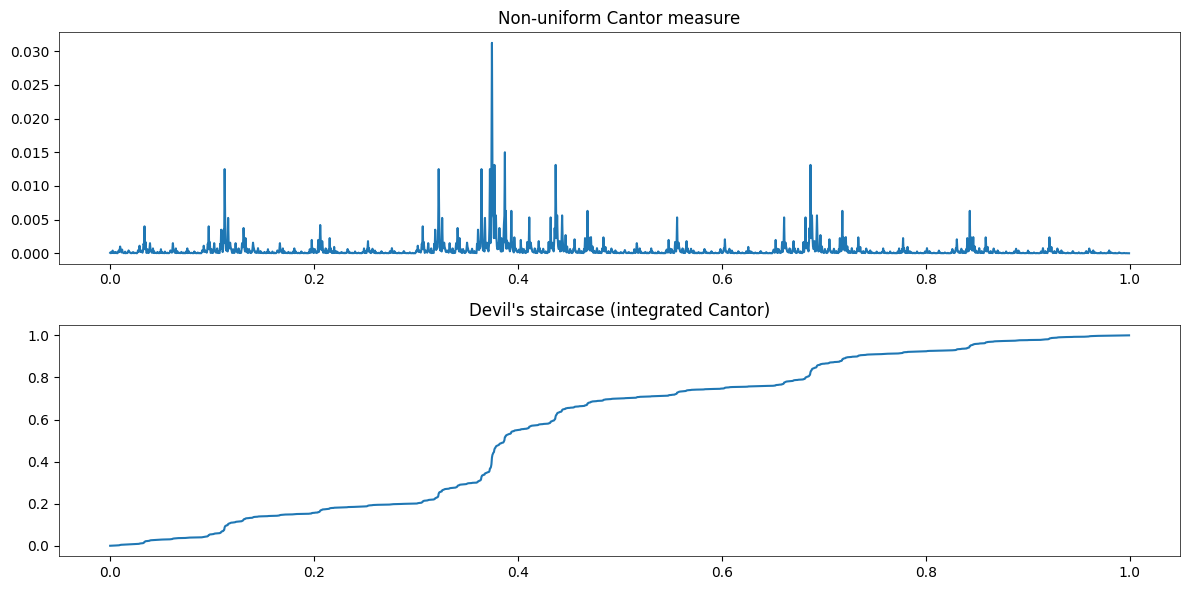

Signal size: 2048, dx: 0.00048828125
Staircase range: [0.0001, 1.0000]


In [ ]:
# Cell 15: Extrema detection with Numba (faithful to ext_compute.c)
#
# Flat-array representation for Numba compatibility:
#   extrep_abs[scale] = 1D array of abscissa values
#   extrep_ord[scale] = 1D array of ordinate values
#   extrep_idx[scale] = 1D array of integer indices

@njit(cache=True)
def _plateau(Y, size, ideb, eps):
    """Find end of plateau. Returns (ifin, min_val, max_val)."""
    min_val = Y[ideb]
    max_val = Y[ideb]
    for i in range(ideb, size):
        if Y[i] > max_val:
            if (Y[i] - min_val) > eps:
                return i, min_val, max_val
            else:
                max_val = Y[i]
        elif Y[i] < min_val:
            if (max_val - Y[i]) > eps:
                return i, min_val, max_val
            else:
                min_val = Y[i]
    return size, min_val, max_val


@njit(cache=True)
def _sign(x):
    if x > 0: return 1
    elif x < 0: return -1
    return 0


@njit(cache=True)
def _plateau_is_maxima(prev_val, value, next_val, min_val, max_val):
    """Test if plateau is a modulus maximum."""
    derI = _sign(value - prev_val)
    derNextI = _sign(next_val - value)
    if min_val * max_val <= 0:
        return False
    if derI != derNextI:
        if ((derI == 1 or derNextI == -1) and value > 0) or \
           ((derI == -1 or derNextI == 1) and value < 0):
            if derI != 0 and derNextI != 0:
                return True
    return False


@njit(cache=True)
def compute_extlis_numba(Y, dx, x0, epsilon, firstp, lastp):
    """Compute extrema of wavelet coefficients at one scale.
    Returns (abscissa_arr, ordinate_arr, index_arr) as flat numpy arrays.
    Matches LastWave's ComputeExtlis() with flagCausal=NO, flagInterpol=YES.
    
    firstp, lastp: valid range for L2 norm computation (from CWT border handling).
    """
    size = len(Y)
    
    # Compute threshold = epsilon * L2_norm over valid range [firstp, lastp]
    # (matching LastWave which uses wtrans->D[o][v]->firstp/lastp)
    NL2 = 0.0
    for k in range(firstp, lastp + 1):
        NL2 += Y[k] * Y[k]
    NL2 = np.sqrt(NL2)
    threshold = NL2 * epsilon
    
    # Pre-allocate output (max possible = size/2)
    max_ext = size // 2 + 1
    abs_out = np.empty(max_ext)
    ord_out = np.empty(max_ext)
    idx_out = np.empty(max_ext, dtype=np.int64)
    count = 0
    
    firstI = 1
    lastI = size - 1
    
    i = firstI
    while i < lastI - 2:
        ifin, min_val, max_val = _plateau(Y, size, i, threshold)
        iext = (i + ifin - 1) // 2
        
        prevValueI = Y[i - 1]
        valueI = max_val if max_val >= 0 else min_val
        
        if ifin >= size:
            i = ifin
            continue
        
        nextValueI = Y[ifin]
        
        if _plateau_is_maxima(prevValueI, valueI, nextValueI, min_val, max_val):
            # Parabolic interpolation
            a_coeff = (nextValueI + prevValueI) / 2.0 - valueI
            
            if a_coeff != 0:
                b_coeff = (nextValueI - prevValueI) / 2.0
                c_coeff = valueI
                abscissa = -b_coeff / (2 * a_coeff) + i
                ordinate = c_coeff - b_coeff * b_coeff / (4 * a_coeff)
                
                if abscissa <= i - 1 or abscissa >= ifin:
                    abscissa = float(iext)
                    ordinate = valueI
            else:
                abscissa = float(iext)
                ordinate = valueI
            
            abs_out[count] = abscissa * dx + x0
            ord_out[count] = ordinate
            idx_out[count] = iext
            count += 1
        
        i = ifin
    
    return abs_out[:count].copy(), ord_out[:count].copy(), idx_out[:count].copy()


def compute_extrep(coeffs, scales, n_oct, n_voice, a_min,
                   valid_ranges=None, dx=1.0, x0=0.0, epsilon=1e-6):
    """Compute extrema representation for all scales.
    Returns (extrep_abs, extrep_ord, extrep_idx) — lists of arrays per scale.
    
    valid_ranges: list of (firstp, lastp) from CWT, for L2 norm computation.
                  If None, uses full signal range (0, size-1).
    """
    n_scales = n_oct * n_voice
    size = coeffs.shape[1]
    extrep_abs = []
    extrep_ord = []
    extrep_idx = []
    total = 0
    
    for idx in range(n_scales):
        if valid_ranges is not None:
            firstp, lastp = valid_ranges[idx]
        else:
            firstp, lastp = 0, size - 1
        abs_arr, ord_arr, idx_arr = compute_extlis_numba(
            coeffs[idx], dx, x0, epsilon, firstp, lastp)
        extrep_abs.append(abs_arr)
        extrep_ord.append(ord_arr)
        extrep_idx.append(idx_arr)
        total += len(abs_arr)
    
    print(f'Total extrema: {total}')
    return extrep_abs, extrep_ord, extrep_idx


# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=5, n_voice=10, a_min=1.0,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, 10, 20, 30, 40, 49]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

Numba warmup: 0.228s
Total extrema: 3644
Extrema computed in 0.001s
  Scale 0 (a=1.00): 252 extrema
  Scale 10 (a=2.00): 127 extrema
  Scale 20 (a=4.00): 63 extrema
  Scale 30 (a=8.00): 32 extrema
  Scale 40 (a=16.00): 16 extrema
  Scale 49 (a=29.86): 7 extrema


In [ ]:
# Cell 16: Chaining with Numba (faithful to ext_chain.c)
#
# Chain links stored as integer index arrays:
#   coarser_links[scale][i] = index into extrep_*[scale+1], or -1
#   finer_links[scale][i]   = index into extrep_*[scale-1], or -1

@njit(cache=True)
def chain_extlis_numba(prev_abs, prev_n, coarser_out, finer_in,
                       cur_abs, cur_n, finer_out, is_finest):
    """Chain finer scale (prev) to coarser scale (cur).
    
    prev_abs: abscissa array for finer scale
    prev_n: number of extrema in finer scale
    coarser_out: output array for coarser links from finer scale (prev -> cur)
    finer_in: input array for finer links into prev (from even finer scale)
    cur_abs: abscissa array for coarser scale
    cur_n: number of extrema in coarser scale
    finer_out: output array for finer links from coarser scale (cur -> prev)
    is_finest: True if prev is the finest scale (scale 0)
    """
    if cur_n == 0:
        return
    
    nearest_start = 0
    
    for pi in range(prev_n):
        # Skip unchained extrema except at finest scale
        if not is_finest and finer_in[pi] == -1:
            continue
        
        old_dist = 9999999.0
        dist = old_dist
        dist_min = 9999999.0
        flag_nearest = False
        nearest_idx = nearest_start
        
        j = nearest_start
        while j < cur_n and old_dist >= dist:
            old_dist = dist
            dist = abs(cur_abs[j] - prev_abs[pi])
            if dist <= dist_min:
                flag_nearest = True
                dist_min = dist
                nearest_idx = j
            j += 1
        
        if flag_nearest:
            # Link stealing
            existing_finer = finer_out[nearest_idx]
            if existing_finer == -1 or \
               dist_min < abs(cur_abs[nearest_idx] - prev_abs[existing_finer]):
                if existing_finer != -1:
                    coarser_out[existing_finer] = -1  # unlink old
                coarser_out[pi] = nearest_idx
                finer_out[nearest_idx] = pi
            else:
                coarser_out[pi] = -1
        else:
            coarser_out[pi] = -1
        
        # Back up 2
        nearest_start = max(0, nearest_idx - 2)


def chain_all(extrep_abs, extrep_ord, n_oct, n_voice):
    """Chain all scales. Returns (coarser_links, finer_links) — lists of int arrays."""
    n_scales = n_oct * n_voice
    
    # Allocate link arrays (coarser[s][i] = index into scale s+1, finer[s][i] = index into scale s-1)
    coarser_links = []
    finer_links = []
    for s in range(n_scales):
        n = len(extrep_abs[s])
        coarser_links.append(np.full(n, -1, dtype=np.int64))
        finer_links.append(np.full(n, -1, dtype=np.int64))
    
    # Chain from finest to coarsest
    for s in range(1, n_scales):
        is_finest = (s == 1)
        prev_n = len(extrep_abs[s - 1])
        cur_n = len(extrep_abs[s])
        if prev_n == 0 or cur_n == 0:
            continue
        chain_extlis_numba(
            extrep_abs[s - 1], prev_n, coarser_links[s - 1], finer_links[s - 1],
            extrep_abs[s], cur_n, finer_links[s], is_finest)
    
    return coarser_links, finer_links


def save_chain_state(extrep_abs, extrep_ord, coarser_links):
    """Save a deep copy of chain state before deletion."""
    return ([a.copy() for a in extrep_abs],
            [o.copy() for o in extrep_ord],
            [c.copy() for c in coarser_links])


def chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                     coarser_links, finer_links, n_oct, n_voice):
    """Delete unchained and sign-changing extrema. Modifies arrays in place.
    Returns updated (extrep_abs, extrep_ord, extrep_idx, coarser_links, finer_links).
    
    Matches LastWave's ChainDelete(): for each scale > 0, remove extrema with
    no finer link OR sign change between consecutive linked extrema.
    RemoveDeleteChain walks coarser and removes the entire chain from that point.
    """
    n_scales = n_oct * n_voice
    nb_deleted = 0
    
    for s in range(1, n_scales):
        n = len(extrep_abs[s])
        keep = np.ones(n, dtype=np.bool_)
        
        for i in range(n):
            if not keep[i]:
                continue
            fi = finer_links[s][i]
            if fi == -1 or extrep_ord[s][i] * extrep_ord[s - 1][fi] < 0:
                # Disconnect finer link
                if fi != -1:
                    coarser_links[s - 1][fi] = -1
                    finer_links[s][i] = -1
                
                # Remove chain from this point coarseward
                # Walk coarser and mark for removal
                cs = s
                ci = i
                while cs < n_scales and ci != -1:
                    keep_arr = keep if cs == s else np.ones(len(extrep_abs[cs]), dtype=np.bool_)
                    if cs == s:
                        keep[ci] = False
                    else:
                        # Mark in coarser scale — need separate tracking
                        # For simplicity, just disconnect links
                        pass
                    
                    next_ci = coarser_links[cs][ci] if ci < len(coarser_links[cs]) else -1
                    # Disconnect
                    if ci < len(coarser_links[cs]) and coarser_links[cs][ci] != -1:
                        next_s = cs + 1
                        next_i = coarser_links[cs][ci]
                        if next_i < len(finer_links[next_s]):
                            finer_links[next_s][next_i] = -1
                        coarser_links[cs][ci] = -1
                    if ci < len(finer_links[cs]) and finer_links[cs][ci] != -1:
                        prev_s = cs - 1
                        prev_i = finer_links[cs][ci]
                        if prev_i < len(coarser_links[prev_s]):
                            coarser_links[prev_s][prev_i] = -1
                        finer_links[cs][ci] = -1
                    
                    ci = next_ci
                    cs += 1
                
                nb_deleted += 1
        
        # Actually remove marked extrema and rebuild indices
        if not np.all(keep):
            # Build index remapping
            new_indices = np.cumsum(keep) - 1
            n_new = int(np.sum(keep))
            
            # Update finer links in scale s+1 that point into scale s
            if s + 1 < n_scales:
                for j in range(len(finer_links[s + 1])):
                    old_fi = finer_links[s + 1][j]
                    if old_fi != -1:
                        if keep[old_fi]:
                            finer_links[s + 1][j] = new_indices[old_fi]
                        else:
                            finer_links[s + 1][j] = -1
            
            # Update coarser links in scale s-1 that point into scale s
            for j in range(len(coarser_links[s - 1])):
                old_ci = coarser_links[s - 1][j]
                if old_ci != -1:
                    if keep[old_ci]:
                        coarser_links[s - 1][j] = new_indices[old_ci]
                    else:
                        coarser_links[s - 1][j] = -1
            
            # Filter arrays
            extrep_abs[s] = extrep_abs[s][keep]
            extrep_ord[s] = extrep_ord[s][keep]
            extrep_idx[s] = extrep_idx[s][keep]
            coarser_links[s] = coarser_links[s][keep]
            finer_links[s] = finer_links[s][keep]
    
    return nb_deleted


@njit(cache=True)
def chain_max_numba(ord_arrays, coarser_arrays, n_scales, a_min, n_voice, expo):
    """Scale-adaptive amplitude along chains starting from finest scale.
    Modifies ord_arrays in place.
    """
    n_finest = len(ord_arrays[0])
    
    for fi in range(n_finest):
        max_value = -1.0
        max_valueN = -1.0
        
        cs = 0
        ci = fi
        while cs < n_scales and ci != -1:
            new_max_valueN = abs(ord_arrays[cs][ci]) * a_min * (2.0 ** (expo * cs / n_voice))
            if new_max_valueN < max_valueN:
                ord_arrays[cs][ci] = max_value
            else:
                max_value = ord_arrays[cs][ci]
                max_valueN = new_max_valueN
            
            ci = coarser_arrays[cs][ci]
            cs += 1


def chain_max_wrapper(extrep_ord, coarser_links, n_oct, n_voice, a_min, expo=1.0):
    """Wrapper to call chain_max_numba with typed lists."""
    n_scales = n_oct * n_voice
    ord_list = NumbaList()
    coarser_list = NumbaList()
    for s in range(n_scales):
        ord_list.append(extrep_ord[s])
        coarser_list.append(coarser_links[s])
    chain_max_numba(ord_list, coarser_list, n_scales, a_min, n_voice, expo)


def trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales):
    """Trace all chains from finest scale. Returns list of (positions, log2scales, sign)."""
    chains = []
    for fi in range(len(extrep_abs[0])):
        positions = []
        scale_vals = []
        cs = 0
        ci = fi
        while cs < n_scales and ci != -1:
            positions.append(extrep_abs[cs][ci])
            scale_vals.append(np.log2(scales[cs]))
            ci = coarser_links[cs][ci]
            cs += 1
        if len(positions) > 1:
            sign = 1 if extrep_ord[0][fi] > 0 else -1
            chains.append((positions, scale_vals, sign))
    return chains


# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=5, n_voice=10)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, 5 * 10)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=5, n_voice=10)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

Chaining: 0.002s
Delete: 0.003s, deleted 0 chains
ChainMax: 0.196s
Total chaining: 0.201s
Remaining extrema: 3644


In [ ]:
# Cell 16b: Zero-crossing detection + chaining
#
# Zero crossings of CWT coefficients carry phase information.
# Combined with modulus maxima, they form a complete representation
# for signal reconstruction (Mallat & Zhong 1992).
#
# Detection: find sign changes in coefficients at each scale,
# with linear interpolation for sub-sample precision.
# Chaining: same nearest-neighbor linking as extrema chains.

@njit(cache=True)
def compute_zero_crossings_numba(Y, dx, x0, firstp, lastp):
    """Find zero crossings of wavelet coefficients at one scale.
    
    Returns (abscissa_arr, ordinate_arr, index_arr):
      - abscissa: interpolated position of zero crossing
      - ordinate: slope at crossing (Y[i+1] - Y[i]), sign indicates direction
      - index: integer index of sample just before crossing
    """
    size = len(Y)
    max_zc = size // 2 + 1
    abs_out = np.empty(max_zc)
    ord_out = np.empty(max_zc)  # slope at crossing
    idx_out = np.empty(max_zc, dtype=np.int64)
    count = 0
    
    lo = max(1, firstp)
    hi = min(size - 1, lastp)
    
    for i in range(lo, hi):
        if Y[i] * Y[i + 1] < 0:
            # Sign change between i and i+1 — linear interpolation
            frac = Y[i] / (Y[i] - Y[i + 1])
            abscissa = (i + frac) * dx + x0
            slope = Y[i + 1] - Y[i]
            
            abs_out[count] = abscissa
            ord_out[count] = slope  # positive = rising, negative = falling
            idx_out[count] = i
            count += 1
        elif Y[i] == 0.0 and i > lo:
            # Exact zero — check if it's a true crossing (not a touch)
            if Y[i - 1] * Y[i + 1] < 0:
                abs_out[count] = i * dx + x0
                ord_out[count] = Y[i + 1] - Y[i - 1]
                idx_out[count] = i
                count += 1
    
    return abs_out[:count].copy(), ord_out[:count].copy(), idx_out[:count].copy()


def compute_zero_crossings(coeffs, scales, n_oct, n_voice, a_min,
                           valid_ranges=None, dx=1.0, x0=0.0):
    """Compute zero crossings for all scales.
    Returns (zc_abs, zc_ord, zc_idx) — lists of arrays per scale,
    same structure as extrep for compatibility with chaining.
    """
    n_scales = n_oct * n_voice
    size = coeffs.shape[1]
    zc_abs = []
    zc_ord = []
    zc_idx = []
    total = 0
    
    for idx in range(n_scales):
        if valid_ranges is not None:
            firstp, lastp = valid_ranges[idx]
        else:
            firstp, lastp = 0, size - 1
        abs_arr, ord_arr, idx_arr = compute_zero_crossings_numba(
            coeffs[idx], dx, x0, firstp, lastp)
        zc_abs.append(abs_arr)
        zc_ord.append(ord_arr)
        zc_idx.append(idx_arr)
        total += len(abs_arr)
    
    print(f'Total zero crossings: {total}')
    return zc_abs, zc_ord, zc_idx


def chain_zero_crossings(zc_abs, zc_ord, n_oct, n_voice):
    """Chain zero crossings across scales using the same algorithm as extrema.
    
    Unlike extrema chaining, we don't do chain_delete (no sign-change pruning
    needed since ZCs don't have sign in the same sense) or chainmax.
    We DO skip unchained ZCs at non-finest scales (same as extrema chaining).
    
    Returns (coarser_links, finer_links).
    """
    n_scales = n_oct * n_voice
    
    coarser_links = []
    finer_links = []
    for s in range(n_scales):
        n = len(zc_abs[s])
        coarser_links.append(np.full(n, -1, dtype=np.int64))
        finer_links.append(np.full(n, -1, dtype=np.int64))
    
    for s in range(1, n_scales):
        is_finest = (s == 1)
        prev_n = len(zc_abs[s - 1])
        cur_n = len(zc_abs[s])
        if prev_n == 0 or cur_n == 0:
            continue
        chain_extlis_numba(
            zc_abs[s - 1], prev_n, coarser_links[s - 1], finer_links[s - 1],
            zc_abs[s], cur_n, finer_links[s], is_finest)
    
    return coarser_links, finer_links


def trace_zc_chains(zc_abs, zc_ord, coarser_links, scales, n_scales):
    """Trace zero-crossing chains from finest scale."""
    chains = []
    for fi in range(len(zc_abs[0])):
        positions = []
        scale_vals = []
        cs = 0
        ci = fi
        while cs < n_scales and ci != -1:
            positions.append(zc_abs[cs][ci])
            scale_vals.append(np.log2(scales[cs]))
            ci = coarser_links[cs][ci]
            cs += 1
        if len(positions) > 1:
            sign = 1 if zc_ord[0][fi] > 0 else -1  # rising vs falling
            chains.append((positions, scale_vals, sign))
    return chains


print('Zero-crossing detection and chaining functions defined:')
print('  compute_zero_crossings() — detect ZCs at all scales')
print('  chain_zero_crossings()   — chain ZCs across scales')
print('  trace_zc_chains()        — trace ZC chains for visualization')

In [ ]:
# Cell 16c: Mallat & Zhong (1992) reconstruction from maxima + zero crossings
#
# The CWT with Gaussian derivative wavelets forms a tight frame.
# Modulus maxima + zero crossings form a complete representation.
#
# Algorithm (alternating projections):
#   1. Build mask M from maxima and ZC positions in the scalogram
#   2. Store known coefficients K at those positions
#   3. Initialize: set non-mask positions to zero
#   4. Iterate:
#      a. x_n = adjoint_CWT(W_n)          — reconstruct signal estimate
#      b. W_n+1 = forward_CWT(x_n)        — re-analyze
#      c. W_n+1[mask] = K[mask]            — enforce known coefficients
#      d. Check convergence

def _adjoint_cwt_raw(coeffs, a_min, n_oct, n_voice, wavelet_name='g2', expo=-1.0):
    """Raw (unnormalized) adjoint of the CWT.
    
    The forward operator at scale a is:  F_a(x) = a^expo * conv(x, rev_psi_a)
    Its adjoint is:                      F_a*(c) = a^expo * conv(c, psi_a)
    
    With geometric scale spacing, da/a = ln(2)/n_voice = const, absorbed into
    the overall frame constant.  So the raw adjoint is:
        sum_a  a^expo * conv(c_a, psi_a)
    """
    n_scales = n_oct * n_voice
    size = coeffs.shape[1]
    factor = 2.0 ** (1.0 / n_voice)
    
    w = WAVELETS[wavelet_name]
    d_x_min = w['x_min_factor'] * w['fact']
    d_x_max = w['x_max_factor'] * w['fact']
    
    result = np.zeros(size, dtype=np.float64)
    
    a = float(a_min)
    for idx in range(n_scales):
        sizeD = int(a * d_x_max)
        sizeG = int(-a * d_x_min)
        sizeTot = sizeD + sizeG + 1
        
        if sizeTot > size:
            a *= factor
            continue
        
        # Build NON-reversed filter (adjoint = correlation with original wavelet)
        filt = np.zeros(sizeTot, dtype=np.float64)
        for i in range(sizeTot):
            filt[i] = wavelet_direct(float(i - sizeG), a, wavelet_name)
        
        filter_begin = -sizeD
        filter_end = sizeG
        
        # Overlap-save convolution
        part_size = _next_power_of_2(2 * sizeTot)
        size_of_exact_data = part_size - sizeTot + 1
        
        filt_ext = _periodic_extend_filter(filt, filter_begin, filter_end, part_size)
        filt_ft = _rfft(filt_ext)
        
        # Apply a^expo: adjoint of forward's "multiply by a^expo" is same scalar
        scale_coeffs = coeffs[idx] * (a ** expo)
        
        nb_of_parts = int(np.ceil(size / size_of_exact_data))
        scale_result = np.zeros(size, dtype=np.float64)
        
        for part_nb in range(nb_of_parts):
            part_begin = part_nb * size_of_exact_data - filter_end
            sig_part = _get_part_mirror(scale_coeffs, size, part_begin, part_size)
            sig_ft = _rfft(sig_part)
            prod_ft = sig_ft * filt_ft
            conv_result = _irfft(prod_ft, part_size)
            
            copy_start = part_nb * size_of_exact_data
            if part_nb < nb_of_parts - 1:
                copy_len = size_of_exact_data
            else:
                copy_len = size - copy_start
            scale_result[copy_start:copy_start + copy_len] = \
                conv_result[filter_end:filter_end + copy_len]
        
        # Uniform weight: geometric spacing → da/a = const, absorbed into frame constant
        result += scale_result
        
        a *= factor
    
    return result


def _get_frame_transfer(size, a_min, n_oct, n_voice, wavelet_name, expo):
    """Compute the frame operator's transfer function H(f) (cached).
    
    The frame operator F*F is approximately translation-invariant (exactly so
    in the interior, away from borders).  Its impulse response h = F*F(delta)
    fully characterizes it.  In the frequency domain, dividing by H(f) = FFT(h)
    corrects for the frequency-dependent eigenvalues that a single scalar
    frame constant cannot.
    """
    cache_key = (size, a_min, n_oct, n_voice, wavelet_name, expo)
    if not hasattr(_get_frame_transfer, '_cache') or \
       _get_frame_transfer._cache_key != cache_key:
        delta = np.zeros(size, dtype=np.float64)
        delta[size // 2] = 1.0
        fwd, _, _ = cwtd_fftw(delta, a_min, n_oct, n_voice, wavelet_name, expo)
        h = _adjoint_cwt_raw(fwd, a_min, n_oct, n_voice, wavelet_name, expo)
        # Center the impulse response so FFT gives the transfer function
        h_centered = np.roll(h, -(size // 2))
        H = _rfft(h_centered)
        H_abs = np.abs(H)
        # Regularization: small fraction of peak to avoid division by near-zero
        reg = 1e-6 * H_abs.max()
        _get_frame_transfer._H = H
        _get_frame_transfer._reg = reg
        _get_frame_transfer._cache_key = cache_key
        print(f'Frame transfer function computed: |H| range [{H_abs.min():.2e}, {H_abs.max():.2e}], '
              f'condition = {H_abs.max() / (H_abs.min() + reg):.1f}, reg = {reg:.2e}')
    return _get_frame_transfer._H, _get_frame_transfer._reg


def adjoint_cwt_fftw(coeffs, a_min, n_oct, n_voice, wavelet_name='g2', expo=-1.0):
    """Normalized inverse adjoint of the CWT via frame deconvolution.
    
    Instead of dividing by a single scalar frame constant, we deconvolve by
    H(f) = FFT(F*F(delta)) — the frame operator's transfer function.  This
    corrects for frequency-dependent frame eigenvalues, giving near-exact
    reconstruction in the signal interior.
    """
    size = coeffs.shape[1]
    
    raw = _adjoint_cwt_raw(coeffs, a_min, n_oct, n_voice, wavelet_name, expo)
    
    H, reg = _get_frame_transfer(size, a_min, n_oct, n_voice, wavelet_name, expo)
    
    # Wiener-style regularized deconvolution: R * conj(H) / (|H|^2 + reg^2)
    R = _rfft(raw)
    H_abs2 = np.abs(H) ** 2
    result = _irfft(R * np.conj(H) / (H_abs2 + reg ** 2), size)
    
    return result


def inverse_cwt_fftw(coeffs, a_min, n_oct, n_voice, wavelet_name='g2', expo=-1.0,
                     scale_range=None):
    """Inverse CWT over a selected scale range.
    
    Parameters
    ----------
    coeffs : 2D array (n_scales, size) — CWT coefficients
    scale_range : tuple (s_lo, s_hi) — scale index range [s_lo, s_hi) to include.
                  None = all scales.
    
    Returns reconstructed signal contribution from the selected scales.
    """
    n_scales = n_oct * n_voice
    size = coeffs.shape[1]
    
    if scale_range is None:
        s_lo, s_hi = 0, n_scales
    else:
        s_lo, s_hi = scale_range
        s_lo = max(0, s_lo)
        s_hi = min(n_scales, s_hi)
    
    # Build partial coefficient array (zero outside range)
    partial = np.zeros_like(coeffs)
    partial[s_lo:s_hi] = coeffs[s_lo:s_hi]
    
    return adjoint_cwt_fftw(partial, a_min, n_oct, n_voice, wavelet_name, expo)


def build_maxima_zc_mask(coeffs, ea, eo, ei, zc_abs, zc_idx, n_scales):
    """Build a sparse mask + known values from modulus maxima and zero crossings."""
    size = coeffs.shape[1]
    mask = np.zeros((n_scales, size), dtype=np.bool_)
    known = np.zeros((n_scales, size), dtype=np.float64)
    
    n_maxima = 0
    n_zc = 0
    
    for s in range(n_scales):
        for k in range(len(ei[s])):
            idx = int(ei[s][k])
            if 0 <= idx < size:
                mask[s, idx] = True
                known[s, idx] = coeffs[s, idx]
                n_maxima += 1
        
        for k in range(len(zc_idx[s])):
            idx = int(zc_idx[s][k])
            if 0 <= idx < size:
                mask[s, idx] = True
                known[s, idx] = coeffs[s, idx]
                if idx + 1 < size:
                    mask[s, idx + 1] = True
                    known[s, idx + 1] = coeffs[s, idx + 1]
                n_zc += 1
    
    total = mask.sum()
    total_possible = n_scales * size
    print(f'Mask: {n_maxima} maxima + {n_zc} ZC points = {total} total '
          f'({100 * total / total_possible:.1f}% of scalogram)')
    
    return mask, known


def reconstruct_mallat_zhong(coeffs, mask, known, a_min, n_oct, n_voice,
                              wavelet_name='g2', expo=-1.0,
                              n_iter=50, tol=1e-6, verbose=True):
    """Reconstruct signal from modulus maxima + zero crossings using
    Mallat & Zhong (1992) alternating projections."""
    n_scales = n_oct * n_voice
    size = coeffs.shape[1]
    
    W = known.copy()
    errors = []
    x_prev = None
    
    for it in range(n_iter):
        x_est = adjoint_cwt_fftw(W, a_min, n_oct, n_voice, wavelet_name, expo)
        
        if x_prev is not None:
            rel_change = np.linalg.norm(x_est - x_prev) / (np.linalg.norm(x_est) + 1e-30)
            errors.append(rel_change)
            if verbose and (it < 5 or it % 10 == 0 or rel_change < tol):
                print(f'  Iter {it:3d}: rel_change = {rel_change:.2e}')
            if rel_change < tol:
                if verbose:
                    print(f'  Converged at iteration {it}')
                break
        
        x_prev = x_est.copy()
        W_new, _, _ = cwtd_fftw(x_est, a_min, n_oct, n_voice, wavelet_name, expo)
        W = W_new.copy()
        W[mask] = known[mask]
    
    return x_est, errors


print('Mallat & Zhong reconstruction functions defined:')
print('  _adjoint_cwt_raw()         — raw adjoint CWT (unnormalized)')
print('  adjoint_cwt_fftw()         — adjoint CWT (frame-normalized)')
print('  inverse_cwt_fftw()         — inverse CWT over selected scale range')
print('  build_maxima_zc_mask()     — build sparse mask from maxima + ZCs')
print('  reconstruct_mallat_zhong() — alternating projection reconstruction')

Pre-deletion chains: 237
Surviving chains: 237
Deleted chains: 0


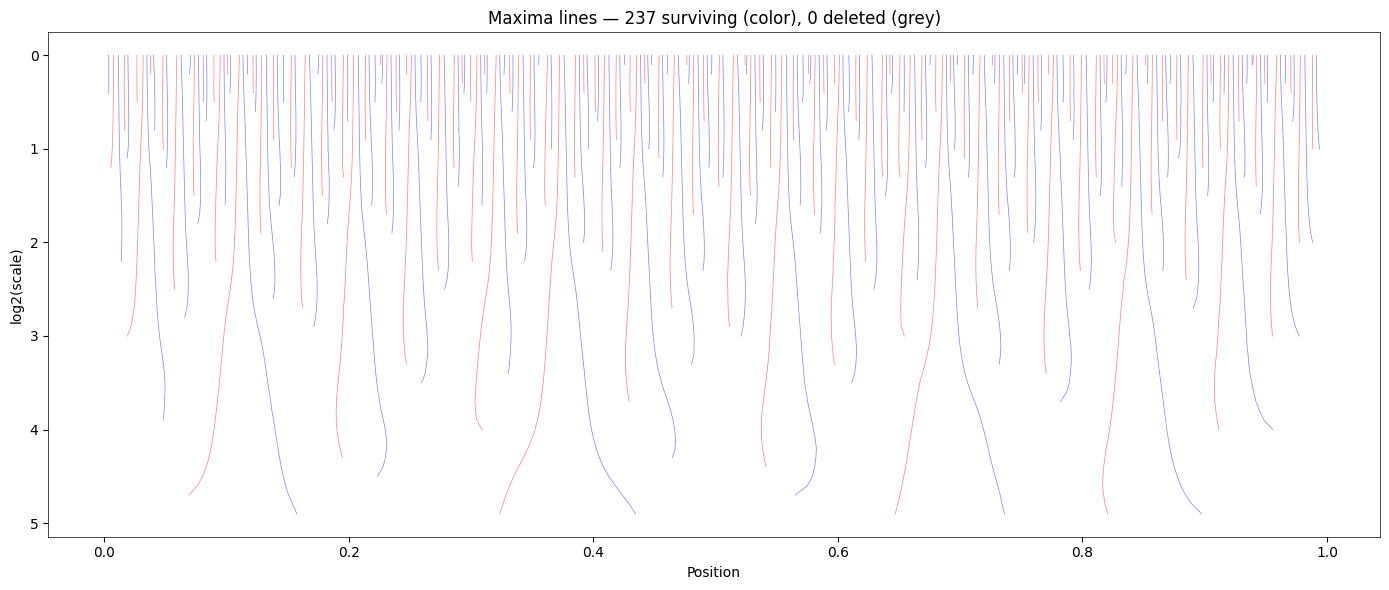

In [ ]:
# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, 5 * 10)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Draw deleted chains first (background, grey)
for pos, sv, sign in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Draw surviving chains on top
for pos, sv, sign in post_del_chains:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — {len(post_del_chains)} surviving (color), {len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Partition function computed in 0.004s, up to scale index 49
Extrema per scale (sample): [252 237 225 208 191]...[10  9  9  7  7]


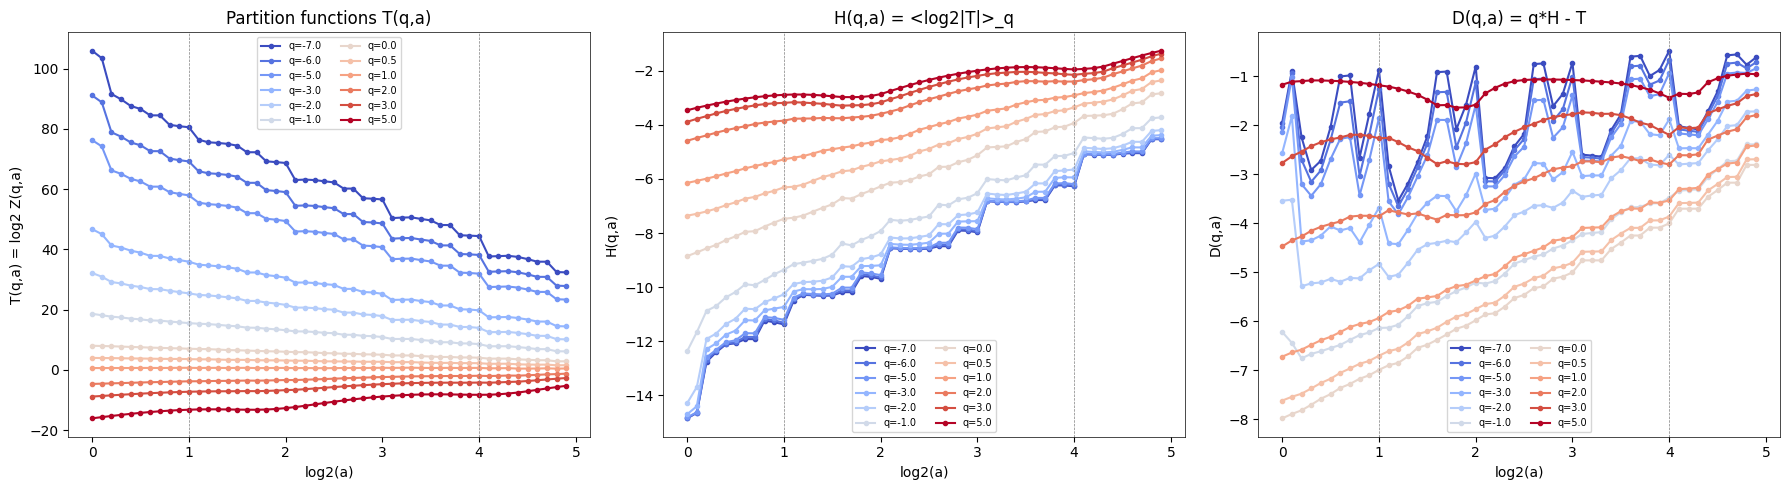

Gray dashed lines show regression range [log2(a)=1 to 4]


In [ ]:
# Cell 18: Partition function (faithful to pf_lib.c PFComputeOneScaleFLOAT)
#
# LastWave stores 7 per-scale arrays per q value:
#   sTq              = sum |T_i|^q                       (the partition function Z(q,a))
#   sTqLogT          = sum |T_i|^q * ln|T_i|             (for h(q) derivative)
#   logSTq           = ln(sTq / N_nonzero)               (intensive-mode log partition function)
#   sTqLogT_sTq      = sTqLogT / sTq                     (= <ln|T|>_q, used for h(q,a))
#   log2STq          = logSTq^2                           (for variance of tau across realizations)
#   sTqLogT_sTq2     = (sTqLogT/sTq)^2                   (for variance of h across realizations)
#   logSTqSTqLogT_sTq = logSTq * sTqLogT_sTq             (cross-term for variance of D)
#
# Access functions (extensive mode, single signal):
#   T(q,a) = log2(sTq)                      -- slope vs log2(a) gives tau(q)
#   H(q,a) = (sTqLogT/sTq) / ln(2)          -- slope vs log2(a) gives h(q)
#   D(q,a) = q * H(q,a) - T(q,a)            -- slope vs log2(a) gives D(q)
# All user-facing values are in log base 2 (divided by ln(2)).

@njit(cache=True)
def pf_compute_one_scale(absT_sorted, tSize, imin, q, scale_idx,
                          sTq_out, sTqLogT_out, logSTq_out, sTqLogT_sTq_out,
                          log2STq_out, sTqLogT_sTq2_out, logSTqSTqLogT_sTq_out):
    """Compute all 7 partition function arrays for one scale and one q value.
    Matches LastWave's PFComputeOneScaleFLOAT exactly.
    """
    if q >= 0:
        tm = absT_sorted[imin]
    else:
        tm = absT_sorted[tSize - 1]
    
    sTq_val = 0.0
    sTqLogT_val = 0.0
    
    if q >= 0:
        # Sum smallest to largest for numerical stability
        for i in range(imin, tSize):
            tq = absT_sorted[i] ** q
            logt = np.log(absT_sorted[i] / tm)
            sTq_val += tq
            sTqLogT_val += tq * logt
    else:
        # Sum largest to smallest for numerical stability
        for i in range(tSize - 1, imin - 1, -1):
            tq = absT_sorted[i] ** q
            logt = np.log(absT_sorted[i] / tm)
            sTq_val += tq
            sTqLogT_val += tq * logt
    
    # Correct for tm normalization: restore true sum(|T|^q * ln|T|)
    sTqLogT_val = sTqLogT_val + np.log(tm) * sTq_val
    
    # Store raw sums
    sTq_out[scale_idx] = sTq_val
    sTqLogT_out[scale_idx] = sTqLogT_val
    
    # Derived quantities (all in natural log)
    if sTq_val != 0:
        N_nonzero = tSize - imin
        logSTq_val = np.log(sTq_val / N_nonzero)   # intensive: log(<|T|^q>)
        sTqLogT_sTq_val = sTqLogT_val / sTq_val    # = <ln|T|>_q
        
        logSTq_out[scale_idx] = logSTq_val
        sTqLogT_sTq_out[scale_idx] = sTqLogT_sTq_val
        log2STq_out[scale_idx] = logSTq_val * logSTq_val
        sTqLogT_sTq2_out[scale_idx] = sTqLogT_sTq_val * sTqLogT_sTq_val
        logSTqSTqLogT_sTq_out[scale_idx] = logSTq_val * sTqLogT_sTq_val


def compute_partition_function(extrep_ord, n_oct, n_voice, a_min, q_list):
    """Compute partition functions matching LastWave's PFComputeOneScaleFLOAT.
    
    Returns dict with all 7 per-scale arrays plus metadata.
    """
    n_scales = n_oct * n_voice
    q_array = np.sort(np.array(q_list, dtype=np.float64))
    n_q = len(q_array)
    
    # All 7 arrays per q value
    sTq = np.zeros((n_q, n_scales))
    sTqLogT = np.zeros((n_q, n_scales))
    logSTq = np.zeros((n_q, n_scales))
    sTqLogT_sTq = np.zeros((n_q, n_scales))
    log2STq = np.zeros((n_q, n_scales))
    sTqLogT_sTq2 = np.zeros((n_q, n_scales))
    logSTqSTqLogT_sTq = np.zeros((n_q, n_scales))
    
    n_ext = np.zeros(n_scales, dtype=np.int64)
    index_max = -1
    
    for scale_idx in range(n_scales):
        tSize = len(extrep_ord[scale_idx])
        n_ext[scale_idx] = tSize
        
        if tSize == 0:
            break
        
        absT = np.abs(extrep_ord[scale_idx]).copy()
        absT.sort()
        
        imin = 0
        while imin < tSize and absT[imin] == 0:
            imin += 1
        
        if imin < tSize:
            for nq in range(n_q):
                pf_compute_one_scale(absT, tSize, imin, q_array[nq], scale_idx,
                                     sTq[nq], sTqLogT[nq], logSTq[nq], sTqLogT_sTq[nq],
                                     log2STq[nq], sTqLogT_sTq2[nq], logSTqSTqLogT_sTq[nq])
        
        index_max = scale_idx
    
    factor = 2.0 ** (1.0 / n_voice)
    scale_values = np.array([a_min * factor**i for i in range(n_scales)])
    # Use exact arithmetic for log2_a (matching LastWave's x0 + dx*i)
    # to avoid floating-point boundary errors in regression range selection
    log2_a = np.log2(a_min) + np.arange(n_scales) / n_voice
    
    return {
        # Raw arrays (natural log)
        'sTq': sTq,
        'sTqLogT': sTqLogT,
        'logSTq': logSTq,
        'sTqLogT_sTq': sTqLogT_sTq,
        'log2STq': log2STq,
        'sTqLogT_sTq2': sTqLogT_sTq2,
        'logSTqSTqLogT_sTq': logSTqSTqLogT_sTq,
        # Metadata
        'q_list': q_array, 'scales': scale_values, 'log2_a': log2_a,
        'n_ext': n_ext, 'index_max': index_max,
        'n_voice': n_voice, 'n_oct': n_oct, 'a_min': a_min,
        'signal_number': 1,
    }


def pf_get_T(pf, q_idx, mode='extensive'):
    """Access T(q,a) = log partition function.
    Extensive: log2(sTq);  Intensive: logSTq / ln(2) / signalNumber.
    Returns array over scales in log base 2."""
    LN2 = np.log(2.0)
    if mode == 'extensive':
        vals = pf['sTq'][q_idx]
        result = np.full_like(vals, np.nan)
        mask = vals > 0
        result[mask] = np.log(vals[mask]) / LN2
        return result
    else:
        return pf['logSTq'][q_idx] / LN2 / pf['signal_number']


def pf_get_H(pf, q_idx, mode='extensive'):
    """Access H(q,a) = weighted average of log|T|.
    Extensive: sTqLogT_sTq / ln(2);  Intensive: same / signalNumber.
    Returns array over scales in log base 2."""
    LN2 = np.log(2.0)
    if mode == 'extensive':
        return pf['sTqLogT_sTq'][q_idx] / LN2
    else:
        return pf['sTqLogT_sTq'][q_idx] / LN2 / pf['signal_number']


def pf_get_D(pf, q_idx, q_val, mode='extensive'):
    """Access D(q,a) = q * H(q,a) - T(q,a).
    Returns array over scales in log base 2."""
    return q_val * pf_get_H(pf, q_idx, mode) - pf_get_T(pf, q_idx, mode)


# Compute partition function
q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=5, n_voice=10, a_min=1.0, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a) — this is what LastWave's "pf get t" returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')


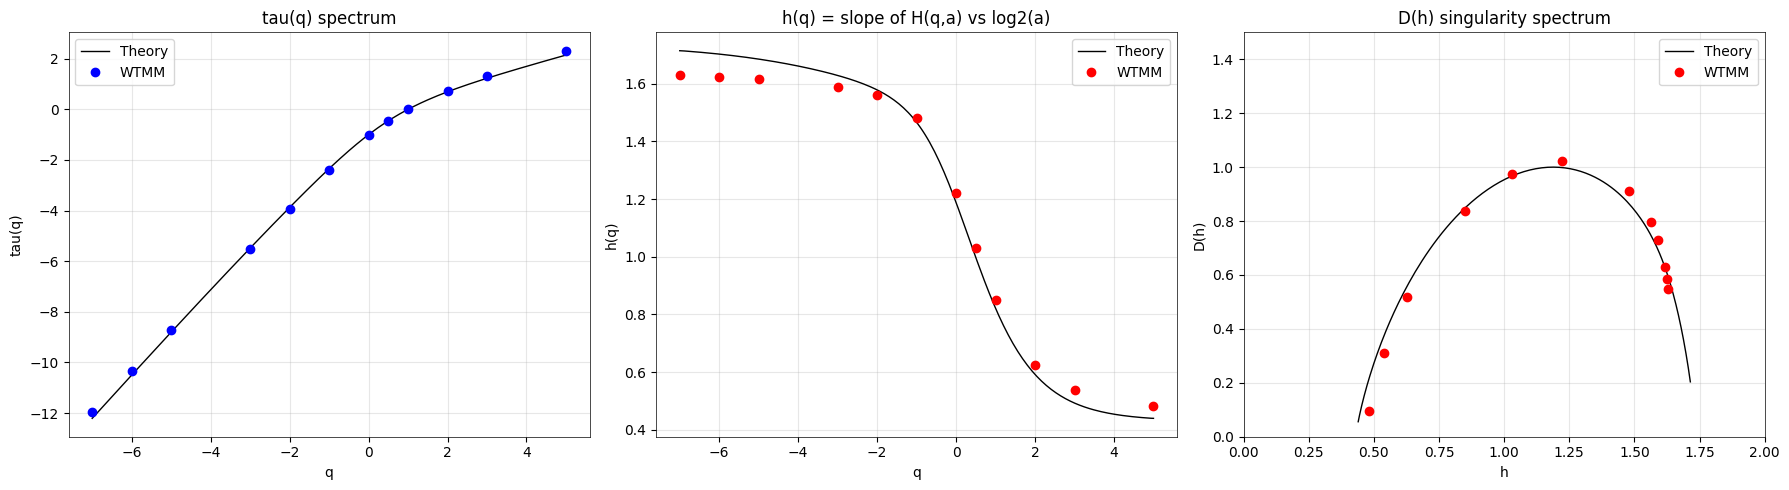


Theoretical: expo=-1.0, so tau_WTMM = tau_measure (integration + 1/a cancel)
h range: [0.458, 1.709]

q	 tau_WTMM	 tau_theory	 diff		 h_WTMM		 h_theory
 -7.0	 -11.9521	 -12.2063	 +0.2541	   1.6291	   1.7094
 -6.0	 -10.3257	 -10.4969	 +0.1712	   1.6235	   1.7021
 -5.0	  -8.7059	  -8.8021	 +0.0962	   1.6156	   1.6832
 -3.0	  -5.4983	  -5.4818	 -0.0165	   1.5890	   1.6242
 -2.0	  -3.9210	  -3.8756	 -0.0453	   1.5622	   1.5690
 -1.0	  -2.3912	  -2.3439	 -0.0473	   1.4797	   1.4378
  0.0	  -1.0216	  -1.0000	 -0.0216	   1.2225	   1.1768
  0.5	  -0.4576	  -0.4534	 -0.0042	   1.0311	   1.0000
  1.0	   0.0111	  -0.0000	 +0.0111	   0.8492	   0.8354
  2.0	   0.7321	   0.6928	 +0.0393	   0.6255	   0.6139
  3.0	   1.3078	   1.2277	 +0.0801	   0.5389	   0.5093
  5.0	   2.3158	   2.1440	 +0.1718	   0.4820	   0.4581


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum
#
# Linear regression of T(q,a), H(q,a), D(q,a) vs log2(a) over selected scale range.
# ALL spectra are obtained from the SLOPE of the regression.
# Matches LastWave's tauqSpectrum and singSpectrum scripts:
#   tauqSpectrum: tau(q) = slope of T(q,a) vs log2(a)
#   singSpectrum: h(q) = slope of H(q,a) vs log2(a)
#                 D(q) = slope of D(q,a) vs log2(a)
# In LastWave, [stats fit signal -x xMin xMax] returns [slope, ..., intercept],
# and both scripts extract [0] = slope.

def compute_spectra(pf, log2_a_min, log2_a_max, mode='extensive'):
    """Compute tau(q), h(q), D(h) spectra via linear regression of slopes.
    
    Parameters
    ----------
    pf : dict from compute_partition_function
    log2_a_min, log2_a_max : float, scale range for regression (in log2)
    mode : str, 'extensive' (single signal) or 'intensive' (ensemble)
    
    Returns
    -------
    spectra : dict with 'tau_q', 'h_q', 'D_q', 'q_list'
    """
    log2_a = pf['log2_a']
    valid_mask = (log2_a >= log2_a_min) & (log2_a <= log2_a_max)
    valid_idx = np.where(valid_mask)[0]
    
    if len(valid_idx) < 2:
        raise ValueError('Not enough scales in range for regression')
    
    # Clip to index_max
    valid_idx = valid_idx[valid_idx <= pf['index_max']]
    
    x = log2_a[valid_idx]  # log2(a)
    q_array = pf['q_list']
    n_q = len(q_array)
    
    tau_q = np.full(n_q, np.nan)
    h_q = np.full(n_q, np.nan)
    d_q = np.full(n_q, np.nan)
    
    for i in range(n_q):
        q = q_array[i]
        
        # T(q,a): log2(Z(q,a)) -- slope gives tau(q)
        y_T = pf_get_T(pf, i, mode)[valid_idx]
        if np.all(np.isfinite(y_T)):
            slope_T, _ = np.polyfit(x, y_T, 1)
            tau_q[i] = slope_T
        
        # H(q,a): <log2|T|>_q -- slope gives h(q)
        y_H = pf_get_H(pf, i, mode)[valid_idx]
        if np.all(np.isfinite(y_H)):
            slope_H, _ = np.polyfit(x, y_H, 1)
            h_q[i] = slope_H
        
        # D(q,a): q*H - T -- slope gives D(q)
        y_D = pf_get_D(pf, i, q, mode)[valid_idx]
        if np.all(np.isfinite(y_D)):
            slope_D, _ = np.polyfit(x, y_D, 1)
            d_q[i] = slope_D
    
    return {
        'tau_q': tau_q,
        'h_q': h_q,
        'D_q': d_q,
        'q_list': q_array,
    }


def theoretical_devil_staircase(q_array, r, p, expo=-1.0):
    """Theoretical tau(q) and D(h) for WTMM on the devil's staircase.
    
    For a self-similar measure mu with weights p_i and contraction ratios r_i:
      tau_measure(q) solves: sum_i p_i^q * r_i^(-tau(q)) = 1
    
    The devil's staircase F = prim(mu) has h_F = h_mu + 1.
    The CWT with expo normalization gives: |coeff| = a^expo * |W[F]| ~ a^(expo + h_F)
    So the effective scaling exponent is: h_eff = h_mu + 1 + expo
    
    With expo=-1 (LastWave default):
      h_eff = h_mu + 1 + (-1) = h_mu
      tau_WTMM(q) = tau_measure(q)  (the integration and 1/a cancel out)
    
    With expo=0:
      h_eff = h_mu + 1
      tau_WTMM(q) = tau_measure(q) + q
    """
    r = np.array(r)
    p = np.array(p)
    
    from scipy.optimize import brentq
    
    tau_measure = np.zeros_like(q_array, dtype=float)
    for j, q in enumerate(q_array):
        def f(tau):
            return np.sum(p**q * r**(-tau)) - 1.0
        tau_measure[j] = brentq(f, -20, 20)
    
    # Account for integration (+1) and expo normalization
    # h_eff = h_measure + 1 + expo, so tau_eff = tau_measure + (1 + expo) * q
    tau_wtmm = tau_measure + (1.0 + expo) * q_array
    
    # D(h) via Legendre transform
    h_theory = np.gradient(tau_wtmm, q_array)
    D_theory = q_array * h_theory - tau_wtmm
    
    return tau_wtmm, h_theory, D_theory


# Compute spectra
# DemoWTMM1DDevilStair: tauqSpectrum pf 1 4 and singSpectrum pf 1 4
spectra = compute_spectra(pf, log2_a_min=1.0, log2_a_max=4.0)

# Theoretical values — use expo=-1 to match our CWT normalization
q_fine = np.linspace(-7, 5, 200)
tau_theory, h_theory, D_theory = theoretical_devil_staircase(
    q_fine, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

tau_theory_q, h_theory_q, D_theory_q = theoretical_devil_staircase(
    spectra['q_list'], r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# 1. tau(q)
ax = axes[0]
ax.plot(q_fine, tau_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q) comparison
ax = axes[1]
ax.plot(q_fine, h_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a) vs log2(a)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. D(h) singularity spectrum
ax = axes[2]
ax.plot(h_theory, D_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# Print comparison
print(f'\nTheoretical: expo={-1.0}, so tau_WTMM = tau_measure (integration + 1/a cancel)')
print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
print('\nq\t tau_WTMM\t tau_theory\t diff\t\t h_WTMM\t\t h_theory')
for i, q in enumerate(spectra['q_list']):
    print(f'{q:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
          f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')

Total extrema: LW=3645, Python=3644
Count mismatches at scales: [1]
  Scale 1: LW=238, Py=237

    q      max|dT|      max|dH|      max|dD|   worst scale
------------------------------------------------------------
 -7.0     0.009547     0.001126     0.017431     10 (log2a=1.0)
 -6.0     0.010416     0.000626     0.013611     10 (log2a=1.0)
 -5.0     0.010429     0.001220     0.007424     10 (log2a=1.0)
 -3.0     0.011941     0.014004     0.053952      1 (log2a=0.1)
 -2.0     0.031736     0.021468     0.074673      1 (log2a=0.1)
 -1.0     0.033902     0.024209     0.009693      1 (log2a=0.1)
  0.0     0.006075     0.016772     0.006075      1 (log2a=0.1)
  0.5     0.001185     0.004455     0.003413      1 (log2a=0.1)
  1.0     0.000145     0.000670     0.000814      1 (log2a=0.1)
  2.0     0.000008     0.000014     0.000036     40 (log2a=4.0)
  3.0     0.000001     0.000002     0.000007     40 (log2a=4.0)
  5.0     0.000001     0.000000     0.000000     44 (log2a=4.4)


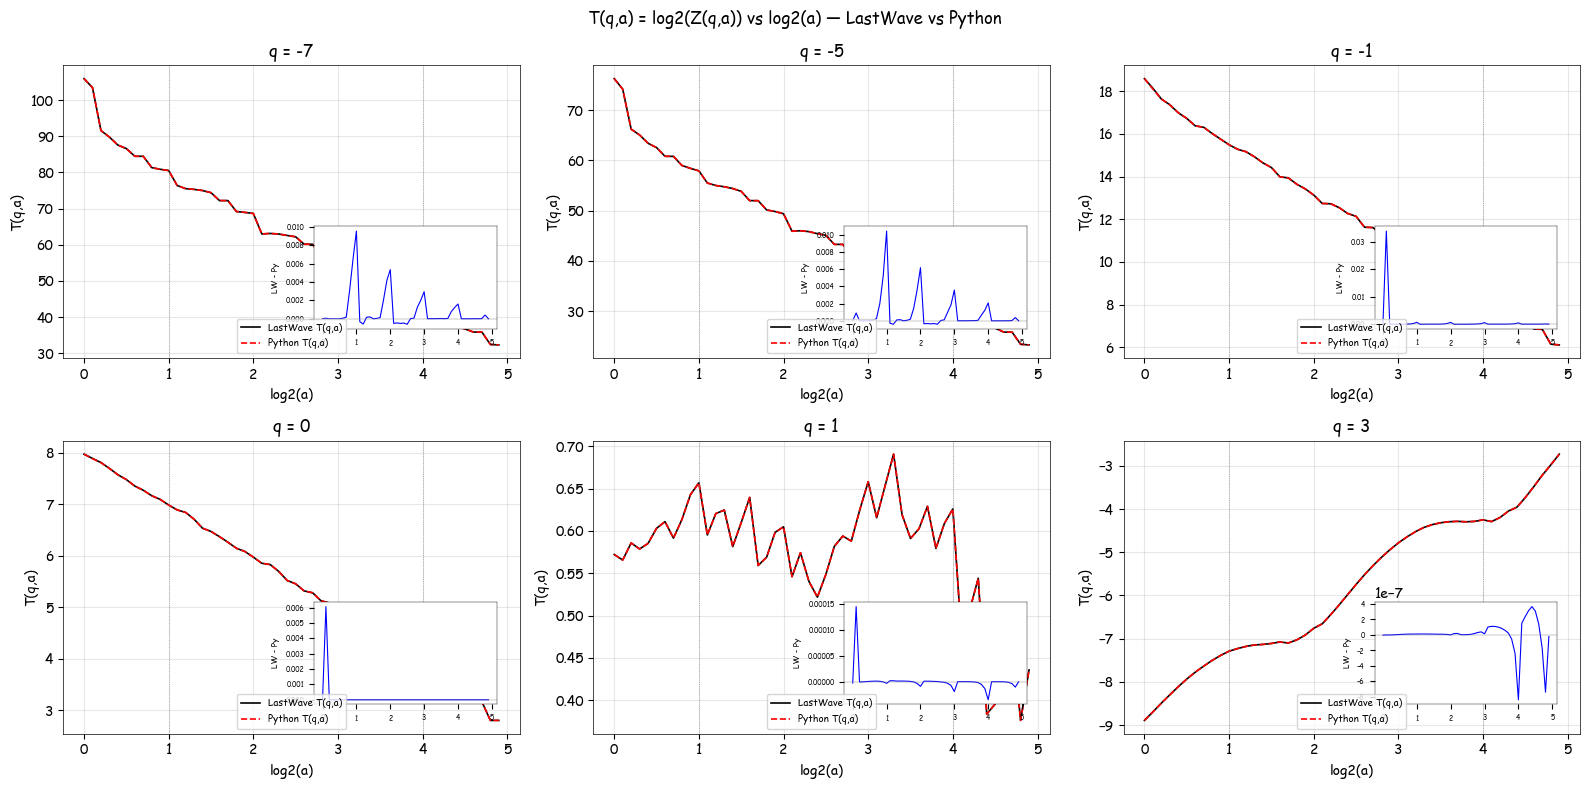

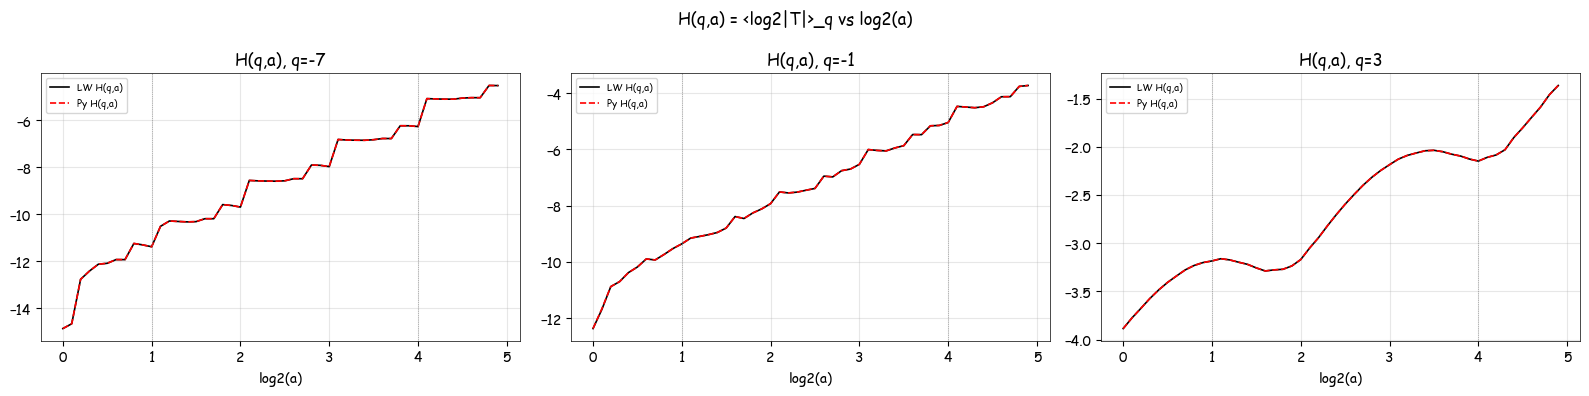

Loaded 639564 samples from cfwb (raw)
Time range: 1993.9358 to 2007.8540 (decimal year)
dt = 0.000019 year (10.0 min)
Value range: -32768.000 to 32714.000 counts
Start filter: 2003.081 -> 2003.2218 decimal year
After date filter: 224406 samples
Using segment of 5760 samples starting at index 33120
Segment time: 2004.0479 to 2004.1574
Segment value range: 2553.000 to 2916.000 counts


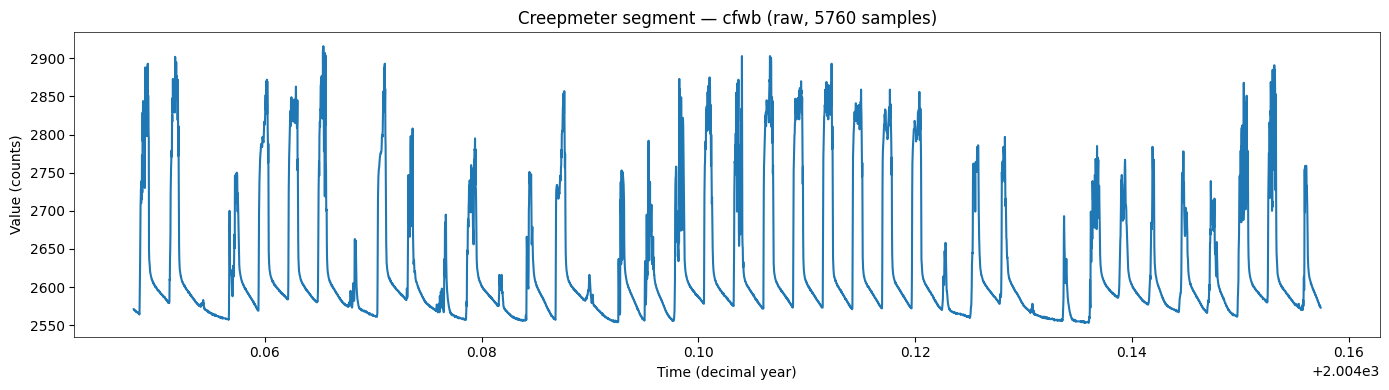

In [ ]:
# CELL 22
# Load creepmeter data — configurable station and source
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.

import os
import gzip

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
# Option A: cleaned data (displacement in mm, gap-filled)
#   station = 'xmr1'
#   source = 'cleaned'
#
# Option B: raw data (counts, may need calibration)
#   station = 'cfwd'
#   source = 'raw'
#
station = 'cfwb'
source = 'raw'       # 'cleaned' or 'raw'
raw_era = 'new'      # 'new' or 'old' (only used when source='raw')
seg_len = 1440*4      # segment length (power of 2 recommended)
start_date = 2003.081    # e.g. 1997.200 = year 1997, day 200. None = auto
end_date = None      # e.g. 2005.365. None = auto
# ══════════════════════════════════════════════════════════════

base_dir = '/Users/amasaryk/projects/Creep'

if source == 'cleaned':
    # Try gz first, then plain
    candidates = [
        f'{base_dir}/Cleaned_data_creep/gz/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        raise FileNotFoundError(f'No cleaned file found for station {station}. '
                                f'Tried: {candidates}')
    opener = gzip.open if fpath.endswith('.gz') else open
    with opener(fpath, 'rt') as f:
        lines = f.readlines()
    unit = 'mm'
    bad_val = -9999

elif source == 'raw':
    # raw/new and raw/old
    candidates = [
        f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/{station}',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        # List available raw files to help the user
        raw_dir = f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/'
        if os.path.isdir(raw_dir):
            avail = sorted(os.listdir(raw_dir))
            print(f'Available raw files: {avail}')
        raise FileNotFoundError(f'No raw file found for station {station}. '
                                f'Tried: {candidates}')
    with open(fpath, 'r') as f:
        lines = f.readlines()
    unit = 'counts'
    bad_val = -9999
else:
    raise ValueError(f"source must be 'cleaned' or 'raw', got '{source}'")

# Parse: year  day_of_year  value
data = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 3:
        try:
            year = float(parts[0])
            doy = float(parts[1])
            val = float(parts[2])
            if val != bad_val:
                t_val = year + doy / 365.25
                data.append((t_val, val))
        except ValueError:
            continue

data = np.array(data)
t_creep = data[:, 0]
x_creep = data[:, 1]
dt_creep = np.median(np.diff(t_creep))

print(f'Loaded {len(x_creep)} samples from {os.path.basename(fpath)} ({source})')
print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
print(f'Value range: {x_creep.min():.3f} to {x_creep.max():.3f} {unit}')

# Apply date range filter if specified
if start_date is not None or end_date is not None:
    # Convert year.doy to decimal year
    def doy_to_decimal(ydoy):
        yr = int(ydoy)
        doy = (ydoy - yr) * 1000  # e.g. 1997.200 -> year=1997, doy=200
        return yr + doy / 365.25
    
    mask = np.ones(len(t_creep), dtype=bool)
    if start_date is not None:
        t_start = doy_to_decimal(start_date)
        mask &= t_creep >= t_start
        print(f'Start filter: {start_date} -> {t_start:.4f} decimal year')
    if end_date is not None:
        t_end = doy_to_decimal(end_date)
        mask &= t_creep <= t_end
        print(f'End filter: {end_date} -> {t_end:.4f} decimal year')
    
    t_creep = t_creep[mask]
    x_creep = x_creep[mask]
    print(f'After date filter: {len(x_creep)} samples')

# Find a clean segment (no gaps)
seg_len = min(seg_len, len(x_creep))
found_clean = False
for start in range(0, len(x_creep) - seg_len, seg_len // 4):
    segment_c = x_creep[start:start + seg_len]
    t_seg_c = t_creep[start:start + seg_len]
    gaps = np.diff(t_seg_c)
    if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
        found_clean = True
        break

if not found_clean:
    # Fall back to first seg_len contiguous samples
    start = 0
    segment_c = x_creep[:seg_len]
    t_seg_c = t_creep[:seg_len]
    print(f'WARNING: no perfectly clean segment found, using first {seg_len} samples')

segment_c = segment_c.copy()
print(f'Using segment of {len(segment_c)} samples starting at index {start}')
print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} {unit}')

fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
ax.plot(t_seg_c, segment_c)
ax.set_xlabel('Time (decimal year)')
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Creepmeter segment — {station} ({source}, {len(segment_c)} samples)')
plt.tight_layout()
plt.show()

First-difference stats: median=0.0000, MAD=1.0000, threshold=100.0000
Detected 28 spikes


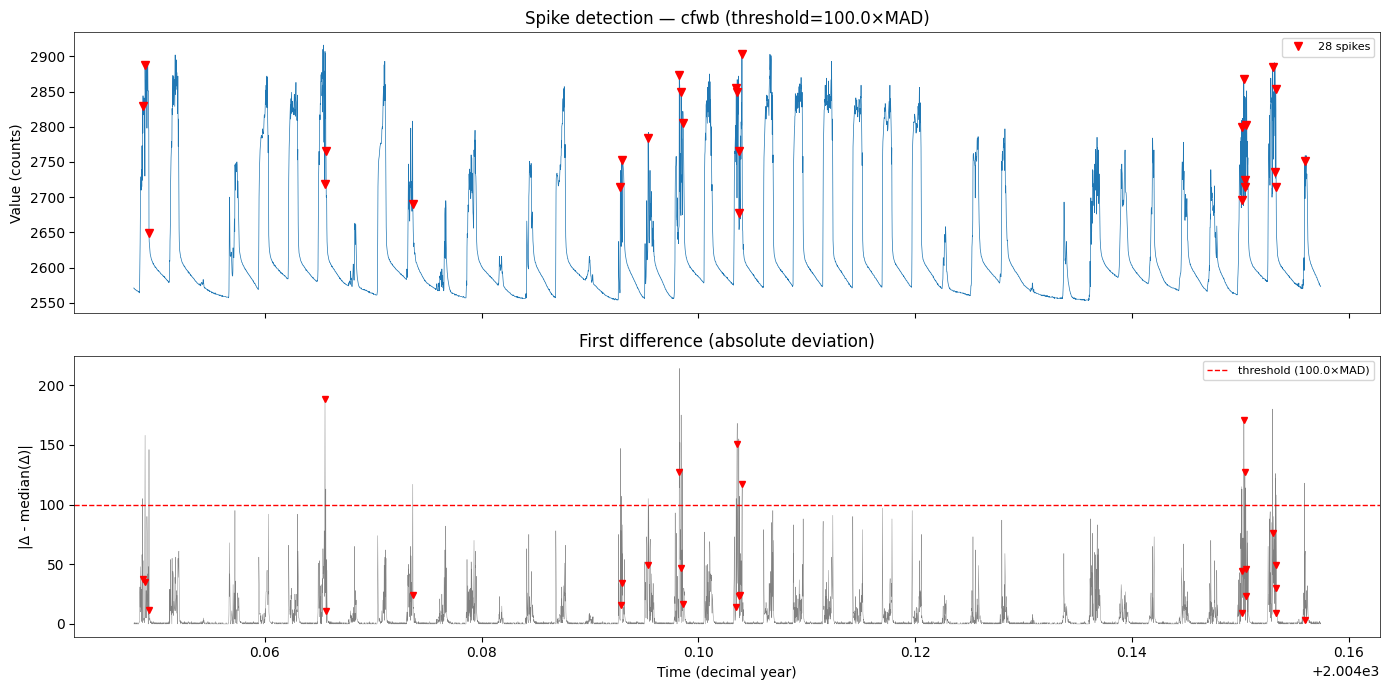

Removed 28 spikes — segment_c updated


In [ ]:
# Cell 22b: Spike detector — find and optionally remove telemetry glitches
#
# Detects spikes using a median-absolute-deviation (MAD) filter on
# the first difference of the signal. Telemetry glitches typically
# appear as single-sample jumps that immediately reverse.
#
# Set remove_spikes = True to replace detected spikes with interpolated values.
# The cleaned signal overwrites segment_c so downstream cells use it automatically.

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
mad_threshold = 100.0   # MAD multiplier — higher = fewer detections
min_spike_gap = 1      # minimum samples between independent spikes
remove_spikes = True   # True = replace spikes with linear interpolation
# ══════════════════════════════════════════════════════════════

diff = np.diff(segment_c)

# MAD of first difference (robust scale estimate)
med_diff = np.median(diff)
mad = np.median(np.abs(diff - med_diff))
if mad == 0:
    # Fallback for quantized data: use IQR-based scale
    q75, q25 = np.percentile(np.abs(diff - med_diff), [75, 25])
    mad = (q75 - q25) / 1.349  # IQR to std conversion
    if mad == 0:
        mad = np.std(diff)
    print(f'MAD was 0 (quantized data), using fallback scale: {mad:.4f}')

threshold = mad_threshold * mad
print(f'First-difference stats: median={med_diff:.4f}, MAD={mad:.4f}, '
      f'threshold={threshold:.4f}')

# Detect spikes: large jump followed by reversal within a few samples
spike_indices = []
abs_diff = np.abs(diff - med_diff)
candidates = np.where(abs_diff > threshold)[0]

i = 0
while i < len(candidates):
    idx = candidates[i]
    # Check for reversal: a spike at idx means diff[idx] is large,
    # and diff[idx+1] (or nearby) should be large in opposite direction
    is_spike = False
    for offset in range(1, min_spike_gap + 1):
        if idx + offset < len(diff):
            if abs_diff[idx + offset] > threshold:
                # Opposite sign = reversal
                if diff[idx] * diff[idx + offset] < 0:
                    is_spike = True
                    break
    if is_spike:
        # The spike is at sample idx+1 (the point between the two jumps)
        spike_indices.append(idx + 1)
    else:
        # Single large jump without reversal — could be a step/event, flag but don't remove
        spike_indices.append(idx + 1)  # still flag it
    # Skip ahead past this spike cluster
    i += 1
    while i < len(candidates) and candidates[i] - candidates[i-1] <= min_spike_gap:
        i += 1

spike_indices = np.array(spike_indices)
print(f'Detected {len(spike_indices)} spikes')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax in axes:
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(t_seg_c, segment_c, linewidth=0.5)
if len(spike_indices) > 0:
    ax.plot(t_seg_c[spike_indices], segment_c[spike_indices], 'rv', markersize=6,
            label=f'{len(spike_indices)} spikes')
    ax.legend(fontsize=8)
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Spike detection — {station} (threshold={mad_threshold}×MAD)')

ax = axes[1]
ax.plot(t_seg_c[1:], abs_diff, linewidth=0.3, color='grey')
ax.axhline(threshold, color='red', ls='--', lw=1, label=f'threshold ({mad_threshold}×MAD)')
if len(spike_indices) > 0:
    valid_di = spike_indices[spike_indices < len(abs_diff)]
    ax.plot(t_seg_c[1:][valid_di], abs_diff[valid_di], 'rv', markersize=4)
ax.set_ylabel('|Δ - median(Δ)|')
ax.set_xlabel('Time (decimal year)')
ax.legend(fontsize=8)
ax.set_title('First difference (absolute deviation)')

plt.tight_layout()
plt.show()

# Remove spikes by linear interpolation
if remove_spikes and len(spike_indices) > 0:
    segment_cleaned = segment_c.copy()
    for si in spike_indices:
        # Find nearest clean neighbors
        lo = si - 1
        while lo >= 0 and lo in spike_indices:
            lo -= 1
        hi = si + 1
        while hi < len(segment_cleaned) and hi in spike_indices:
            hi += 1
        if lo >= 0 and hi < len(segment_cleaned):
            # Linear interpolation
            frac = (si - lo) / (hi - lo)
            segment_cleaned[si] = segment_cleaned[lo] + frac * (segment_cleaned[hi] - segment_cleaned[lo])
        elif lo >= 0:
            segment_cleaned[si] = segment_cleaned[lo]
        elif hi < len(segment_cleaned):
            segment_cleaned[si] = segment_cleaned[hi]
    
    segment_c = segment_cleaned
    print(f'Removed {len(spike_indices)} spikes — segment_c updated')
else:
    if len(spike_indices) == 0:
        print('No spikes detected — segment_c unchanged')
    else:
        print(f'{len(spike_indices)} spikes detected but remove_spikes=False — segment_c unchanged')

CWT computed in 0.239s
Coefficients shape: (50, 5760), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (20, 5739), coarsest: (601, 5158)


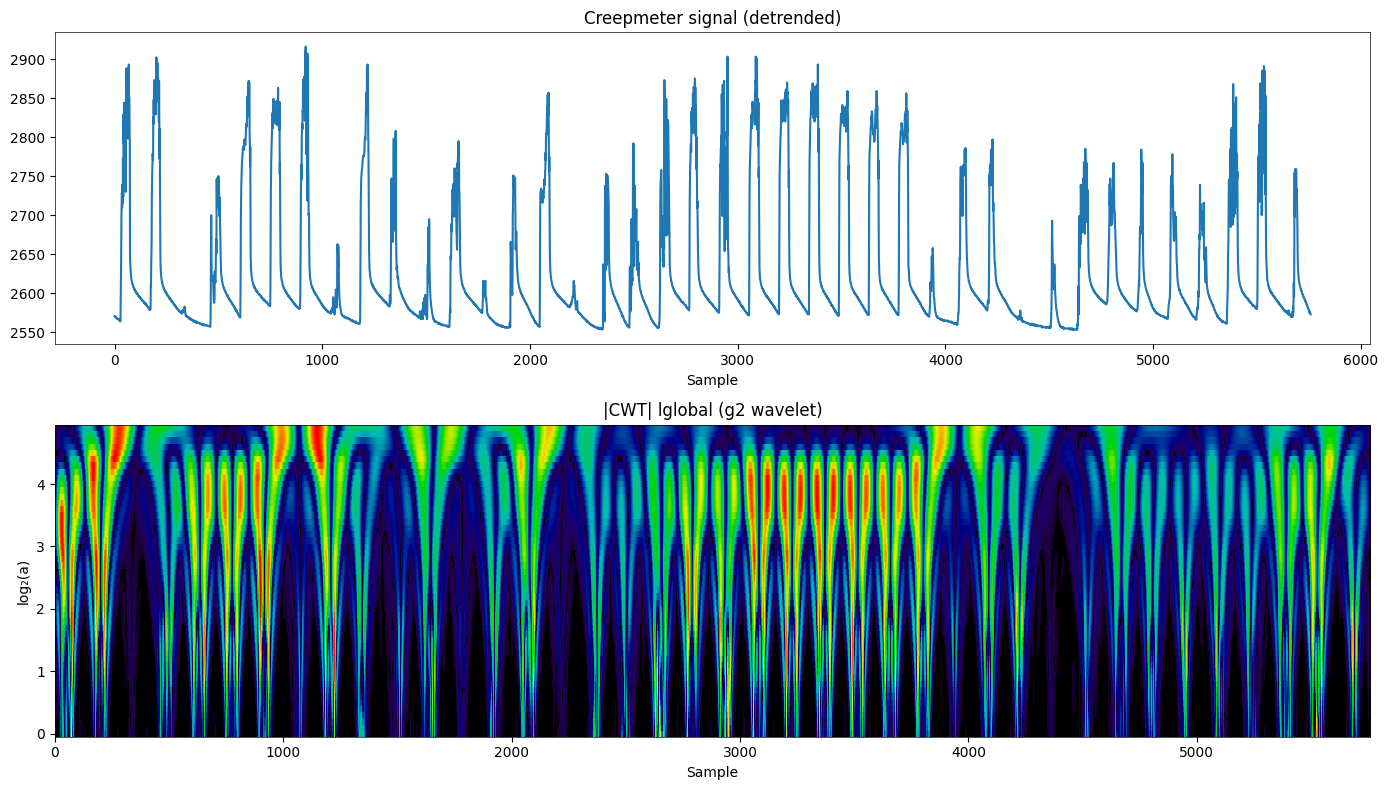

ov_to_log2a() defined — n_voice_c = 10
  Example: 1.1 → log2a=0.00, 2.1 → log2a=1.00, 5.10 → log2a=4.90


In [ ]:
# Cell 23: CWT on creepmeter data + scalogram

n_oct_c, n_voice_c = 5, 10

t0 = time.time()
coeffs_c, scales_c, valid_ranges_c = cwtd_fftw(segment_c, a_min=1.0, n_oct=n_oct_c,
                                                    n_voice=n_voice_c, wavelet_name='g3', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs_c.shape}, Scales: {len(scales_c)} ({scales_c[0]:.2f} to {scales_c[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges_c[0]}, coarsest: {valid_ranges_c[-1]}')

# Scalogram — log2 of modulus
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(segment_c)
ax.set_xlim(0, len(segment_c) - 1)
ax.set_title('Creepmeter signal (detrended)')
ax.set_xlabel('Sample')

ax = axes[1]
im = scalogram_lastwave(coeffs_c, scales=scales_c, ax=ax,
                        norm_mode='lglobal')
ax.set_xlabel('Sample')
ax.set_title('|CWT| lglobal (g2 wavelet)')
#plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')

plt.tight_layout()
plt.show()

# ── octave.voice notation helper ──
# Format: octave.voice where octave starts at 1, voice starts at 1
# Example with n_voice=10: 1.1 = finest scale (log2a=0), 2.1 = log2a=1.0, 3.6 = log2a=2.5
# Conversion: log2_a = (octave - 1) + (voice - 1) / n_voice_c

def ov_to_log2a(ov, n_voice=None):
    """Convert octave.voice notation to log2(a).
    E.g. 2.1 with n_voice=10 → log2a = 1.0, 3.6 → log2a = 2.5"""
    if n_voice is None:
        n_voice = n_voice_c
    octave = int(ov)
    voice = round((ov - octave) * 10)
    if voice < 1 or voice > n_voice:
        print(f'WARNING: voice {voice} out of range [1, {n_voice}]')
    return (octave - 1) + (voice - 1) / n_voice

def log2a_to_ov(log2a, n_voice=None):
    """Convert log2(a) back to octave.voice notation for display."""
    if n_voice is None:
        n_voice = n_voice_c
    octave = int(log2a) + 1
    voice = round((log2a - int(log2a)) * n_voice) + 1
    if voice > n_voice:
        octave += 1
        voice = 1
    return octave + voice / 10

print(f'ov_to_log2a() defined — n_voice_c = {n_voice_c}')
print(f'  Example: 1.1 → log2a={ov_to_log2a(1.1):.2f}, '
      f'2.1 → log2a={ov_to_log2a(2.1):.2f}, '
      f'{n_oct_c}.{n_voice_c} → log2a={ov_to_log2a(n_oct_c + n_voice_c/10):.2f}')


Hurst exponent of raw signal (R/S): H = 0.8686 ± 0.0274
H per voice: min=0.798, max=0.933, mean=0.844


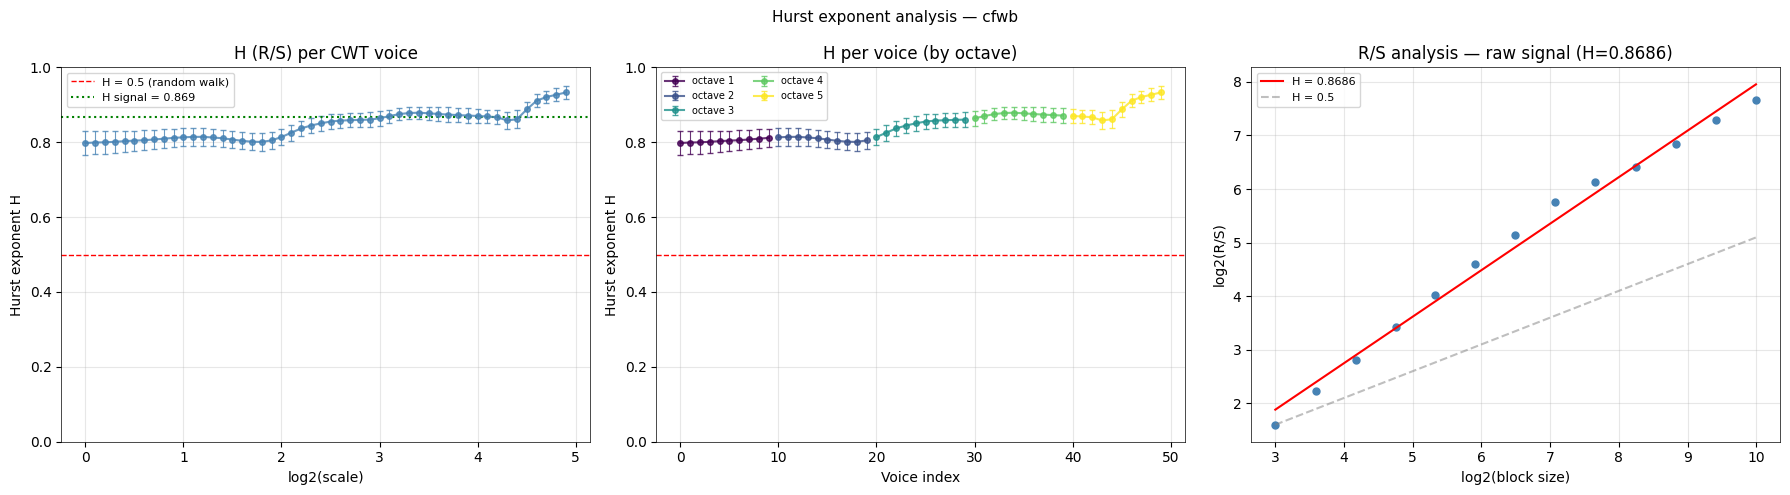

In [ ]:
# Cell 23b: Hurst exponent via rescaled range (R/S) analysis
#
# Estimates H for each CWT voice (scale) and for the raw signal.
# The R/S method: for a time series of length N, divide into blocks
# of size n, compute R/S for each block, average, then regress
# log(R/S) vs log(n) — slope = H.
#
# H > 0.5: persistent (trending), H = 0.5: random walk, H < 0.5: anti-persistent

def rescaled_range(x):
    """Compute R/S for a single series."""
    n = len(x)
    mean = np.mean(x)
    y = np.cumsum(x - mean)
    r = np.max(y) - np.min(y)
    s = np.std(x, ddof=1)
    if s == 0:
        return np.nan
    return r / s

def hurst_rs(x, min_block=8, max_blocks=40):
    """Estimate Hurst exponent via R/S analysis.
    Returns (H, log_n, log_rs) for plotting."""
    n = len(x)
    log_n = []
    log_rs = []
    
    # Use block sizes that are powers of 2 and divisors-ish
    block_sizes = []
    bs = min_block
    while bs <= n // 4:
        block_sizes.append(bs)
        bs = int(bs * 1.5)
        if len(block_sizes) >= max_blocks:
            break
    
    for bs in block_sizes:
        n_blocks = n // bs
        if n_blocks < 2:
            continue
        rs_vals = []
        for b in range(n_blocks):
            block = x[b * bs:(b + 1) * bs]
            rs = rescaled_range(block)
            if not np.isnan(rs) and rs > 0:
                rs_vals.append(rs)
        if len(rs_vals) > 0:
            log_n.append(np.log2(bs))
            log_rs.append(np.log2(np.mean(rs_vals)))
    
    log_n = np.array(log_n)
    log_rs = np.array(log_rs)
    
    if len(log_n) >= 3:
        H, intercept = np.polyfit(log_n, log_rs, 1)
        # Standard error of slope
        residuals = log_rs - (H * log_n + intercept)
        se = np.sqrt(np.sum(residuals**2) / (len(log_n) - 2) / np.sum((log_n - log_n.mean())**2))
    else:
        H = np.nan
        se = np.nan
    
    return H, se, log_n, log_rs

# ── Hurst exponent for each CWT voice ──
H_per_voice = []
H_err = []
for s in range(len(scales_c)):
    voice_signal = np.abs(coeffs_c[s, :])
    H_v, se_v, _, _ = hurst_rs(voice_signal)
    H_per_voice.append(H_v)
    H_err.append(se_v)

H_per_voice = np.array(H_per_voice)
H_err = np.array(H_err)
log2_scales = np.log2(scales_c)

# ── Hurst exponent for the raw signal ──
H_signal, H_signal_se, log_n_sig, log_rs_sig = hurst_rs(segment_c)
print(f'Hurst exponent of raw signal (R/S): H = {H_signal:.4f} ± {H_signal_se:.4f}')
print(f'H per voice: min={np.nanmin(H_per_voice):.3f}, max={np.nanmax(H_per_voice):.3f}, '
      f'mean={np.nanmean(H_per_voice):.3f}')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# (0) H vs voice/scale
ax = axes[0]
ax.errorbar(log2_scales, H_per_voice, yerr=H_err, fmt='o-', markersize=4,
            color='steelblue', ecolor='steelblue', elinewidth=0.8, capsize=2, alpha=0.8)
ax.axhline(0.5, color='red', ls='--', lw=1, label='H = 0.5 (random walk)')
ax.axhline(H_signal, color='green', ls=':', lw=1.5, label=f'H signal = {H_signal:.3f}')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('Hurst exponent H')
ax.set_ylim(0, 1)
ax.set_title('H (R/S) per CWT voice')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (1) H vs voice index (colored by octave)
ax = axes[1]
voice_indices = np.arange(len(scales_c))
colors_oct = plt.cm.viridis(np.linspace(0, 1, n_oct_c))
for o in range(n_oct_c):
    sl = slice(o * n_voice_c, (o + 1) * n_voice_c)
    ax.errorbar(voice_indices[sl], H_per_voice[sl], yerr=H_err[sl],
                fmt='o-', markersize=4, color=colors_oct[o], elinewidth=0.8,
                capsize=2, alpha=0.8, label=f'octave {o+1}')
ax.axhline(0.5, color='red', ls='--', lw=1)
ax.set_xlabel('Voice index')
ax.set_ylabel('Hurst exponent H')
ax.set_ylim(0, 1)
ax.set_title('H per voice (by octave)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# (2) R/S regression for raw signal
ax = axes[2]
if len(log_n_sig) >= 3:
    ax.plot(log_n_sig, log_rs_sig, 'o', markersize=5, color='steelblue')
    fit_line = H_signal * log_n_sig + (log_rs_sig[0] - H_signal * log_n_sig[0])
    p = np.polyfit(log_n_sig, log_rs_sig, 1)
    fit_line = np.polyval(p, log_n_sig)
    ax.plot(log_n_sig, fit_line, '-', color='red', lw=1.5,
            label=f'H = {H_signal:.4f}')
    # Reference slopes
    ax.plot(log_n_sig, 0.5 * log_n_sig + (log_rs_sig[0] - 0.5 * log_n_sig[0]),
            '--', color='grey', alpha=0.5, label='H = 0.5')
    ax.legend(fontsize=8)
ax.set_xlabel('log2(block size)')
ax.set_ylabel('log2(R/S)')
ax.set_title(f'R/S analysis — raw signal (H={H_signal:.4f})')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Hurst exponent analysis — {station}', fontsize=11)
plt.tight_layout()
plt.show()

Total extrema: 12566
Extrema computed in 0.002s
  Scale 0 (a=1.00): 946 extrema
  Scale 10 (a=2.00): 382 extrema
  Scale 20 (a=4.00): 185 extrema
  Scale 30 (a=8.00): 127 extrema
  Scale 40 (a=16.00): 80 extrema
  Scale 49 (a=29.86): 34 extrema


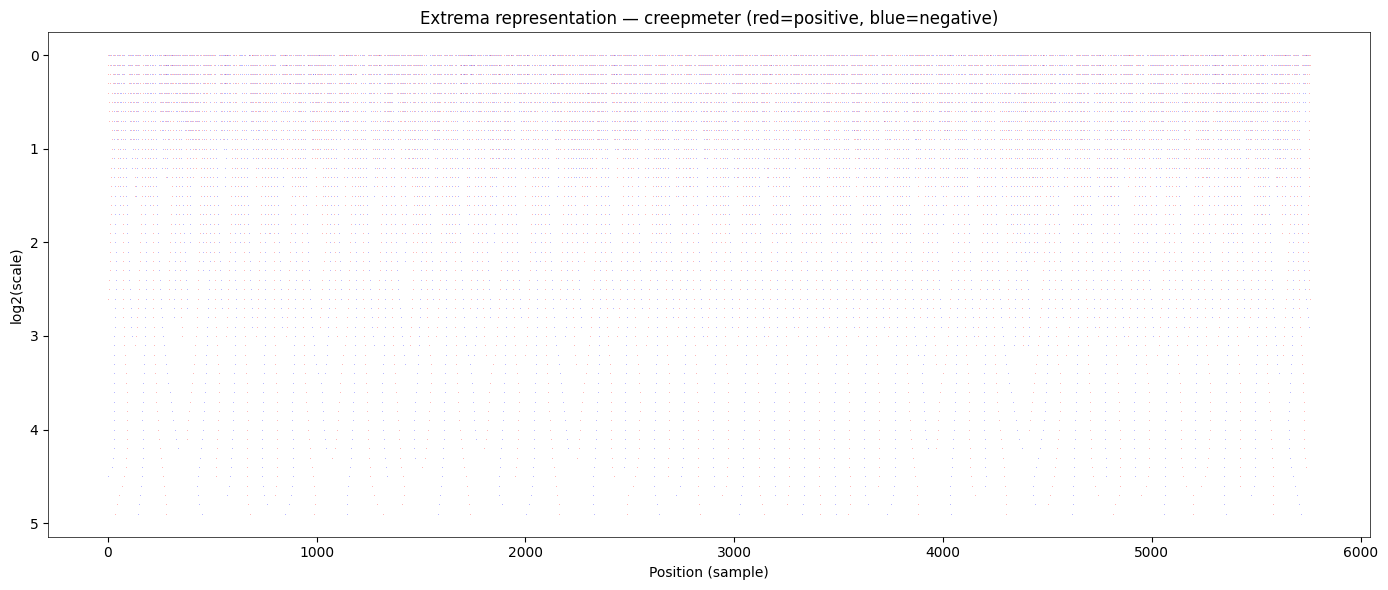

In [ ]:
# Cell 24: Extrema detection on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
ea_c, eo_c, ei_c = compute_extrep(coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                   a_min=1.0, valid_ranges=valid_ranges_c,
                                   dx=1.0, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t0:.3f}s')
# Use actual scale count instead of hardcoded indices
sample_indices = [0, n_scales_c // 5, 2 * n_scales_c // 5, 3 * n_scales_c // 5, 4 * n_scales_c // 5, n_scales_c - 1]
for sidx in sample_indices:
    print(f'  Scale {sidx} (a={scales_c[sidx]:.2f}): {len(ea_c[sidx])} extrema')

# Extrema representation plot — vectorized scatter for speed
all_pos = []
all_log2s = []
all_signs = []
for sidx in range(len(ea_c)):
    n = len(ea_c[sidx])
    if n == 0:
        continue
    all_pos.append(ea_c[sidx])
    all_log2s.append(np.full(n, np.log2(scales_c[sidx])))
    all_signs.append(eo_c[sidx] > 0)

all_pos = np.concatenate(all_pos)
all_log2s = np.concatenate(all_log2s)
all_signs = np.concatenate(all_signs)

fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
pos_mask = all_signs
ax.scatter(all_pos[pos_mask], all_log2s[pos_mask], c='red', s=0.1, linewidths=0)
ax.scatter(all_pos[~pos_mask], all_log2s[~pos_mask], c='blue', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title('Extrema representation — creepmeter (red=positive, blue=negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Chaining: 0.001s
Delete: 0.013s, deleted 1 chains
ChainMax: 0.012s
Remaining extrema: 12565
Pre-deletion chains: 877
Surviving chains: 877
Deleted chains: 0


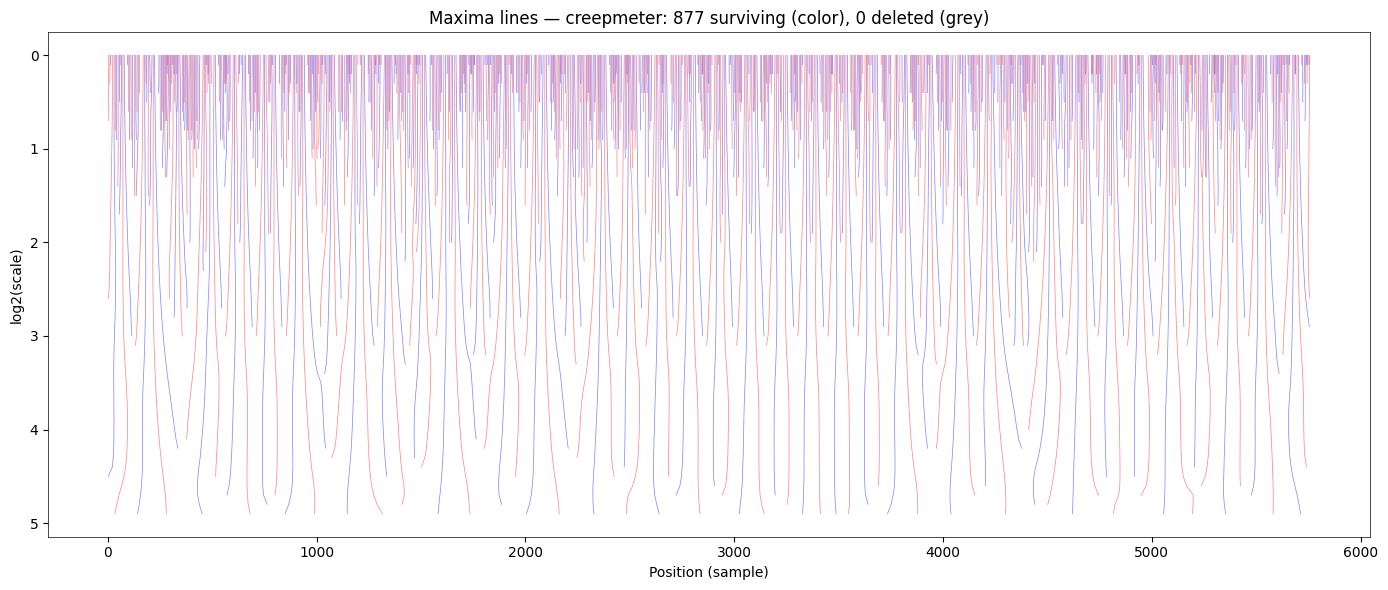

In [ ]:
# Cell 25: Chaining + ChainMax on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
cl_c, fl_c = chain_all(ea_c, eo_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs_c, pre_del_ord_c, pre_del_cl_c = save_chain_state(ea_c, eo_c, cl_c)
pre_del_chains_c = trace_chains(pre_del_abs_c, pre_del_ord_c, pre_del_cl_c, scales_c, n_scales_c)

nb_del = chain_delete_all(ea_c, eo_c, ei_c, cl_c, fl_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

chain_max_wrapper(eo_c, cl_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')

remaining = sum(len(a) for a in ea_c)
print(f'Remaining extrema: {remaining}')

# Surviving vs deleted chains
post_del_chains_c = trace_chains(ea_c, eo_c, cl_c, scales_c, n_scales_c)

surviving_starts_c = set()
for pos, sv, sign in post_del_chains_c:
    surviving_starts_c.add((pos[0], sign))

deleted_chains_c = []
for pos, sv, sign in pre_del_chains_c:
    if (pos[0], sign) not in surviving_starts_c:
        deleted_chains_c.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains_c)}')
print(f'Surviving chains: {len(post_del_chains_c)}')
print(f'Deleted chains: {len(deleted_chains_c)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

for pos, sv, sign in deleted_chains_c:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

for pos, sv, sign in post_del_chains_c:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — creepmeter: {len(post_del_chains_c)} surviving (color), {len(deleted_chains_c)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Total zero crossings: 8073
Zero crossings detected in 0.002s
Zero crossings chained in 0.001s
Zero-crossing chains: 761

Per-scale comparison:
 Scale  log2(a)  Extrema  ZeroCross   Ratio
     0     0.00      946        841    0.89
    12     1.71      219        206    0.94
    24     3.43       81         74    0.91
    36     5.14       30         23    0.77
    48     6.86        9          2    0.22


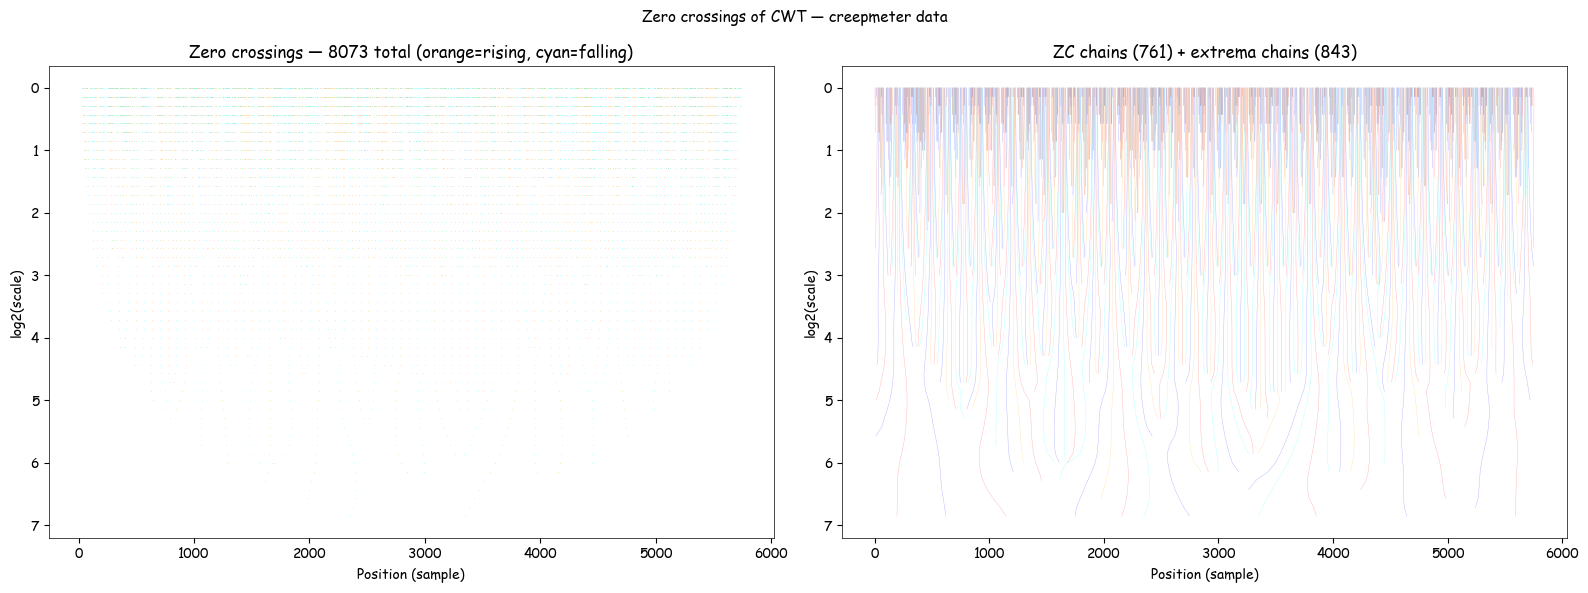

In [ ]:
# Cell 24b: Zero-crossing detection + chaining on creepmeter data
#
# Detect and chain zero crossings of the CWT. Together with modulus maxima,
# these form the complete wavelet representation for reconstruction.

import time as time

t0 = time.time()

# Detect zero crossings
zc_abs_c, zc_ord_c, zc_idx_c = compute_zero_crossings(
    coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0,
    valid_ranges=valid_ranges_c, dx=1.0, x0=0.0)

t1 = time.time()
print(f'Zero crossings detected in {t1-t0:.3f}s')

# Chain zero crossings
zc_cl_c, zc_fl_c = chain_zero_crossings(zc_abs_c, zc_ord_c, n_oct=n_oct_c, n_voice=n_voice_c)
t2 = time.time()
print(f'Zero crossings chained in {t2-t1:.3f}s')

# Trace chains
zc_chains_c = trace_zc_chains(zc_abs_c, zc_ord_c, zc_cl_c, scales_c, n_scales_c)
print(f'Zero-crossing chains: {len(zc_chains_c)}')

# Compare counts with extrema
n_ext_total = sum(len(a) for a in ea_c)
n_zc_total = sum(len(a) for a in zc_abs_c)
print(f'\nPer-scale comparison:')
print(f'{"Scale":>6} {"log2(a)":>8} {"Extrema":>8} {"ZeroCross":>10} {"Ratio":>7}')
sample_indices = [0, n_scales_c//4, n_scales_c//2, 3*n_scales_c//4, n_scales_c-1]
for s in sample_indices:
    ne = len(ea_c[s])
    nz = len(zc_abs_c[s])
    ratio = nz / ne if ne > 0 else float('inf')
    print(f'{s:>6} {np.log2(scales_c[s]):>8.2f} {ne:>8} {nz:>10} {ratio:>7.2f}')

# Plot: extrema + zero crossings overlay
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# (0) Zero-crossing representation (like extrema rep)
ax = axes[0]
for s in range(n_scales_c):
    n = len(zc_abs_c[s])
    if n == 0:
        continue
    log2s = np.full(n, np.log2(scales_c[s]))
    rising = zc_ord_c[s] > 0
    ax.scatter(zc_abs_c[s][rising], log2s[rising], c='orange', s=0.1, linewidths=0)
    ax.scatter(zc_abs_c[s][~rising], log2s[~rising], c='cyan', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Zero crossings — {n_zc_total} total (orange=rising, cyan=falling)')
ax.invert_yaxis()

# (1) Zero-crossing chains
ax = axes[1]
for pos, sv, sign in zc_chains_c:
    color = 'orange' if sign > 0 else 'cyan'
    ax.plot(pos, sv, '-', color=color, alpha=0.3, linewidth=0.3)
# Overlay extrema chains for reference
for pos, sv, sign in post_del_chains_c:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.3, linewidth=0.3)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'ZC chains ({len(zc_chains_c)}) + extrema chains ({len(post_del_chains_c)})')
ax.invert_yaxis()

plt.suptitle('Zero crossings of CWT — creepmeter data', fontsize=11)
plt.tight_layout()
plt.show()

Extrema chains: 946
  min=1, max=49, mean=9.7, median=6
ZC chains: 841
  min=1, max=49, mean=9.6, median=6


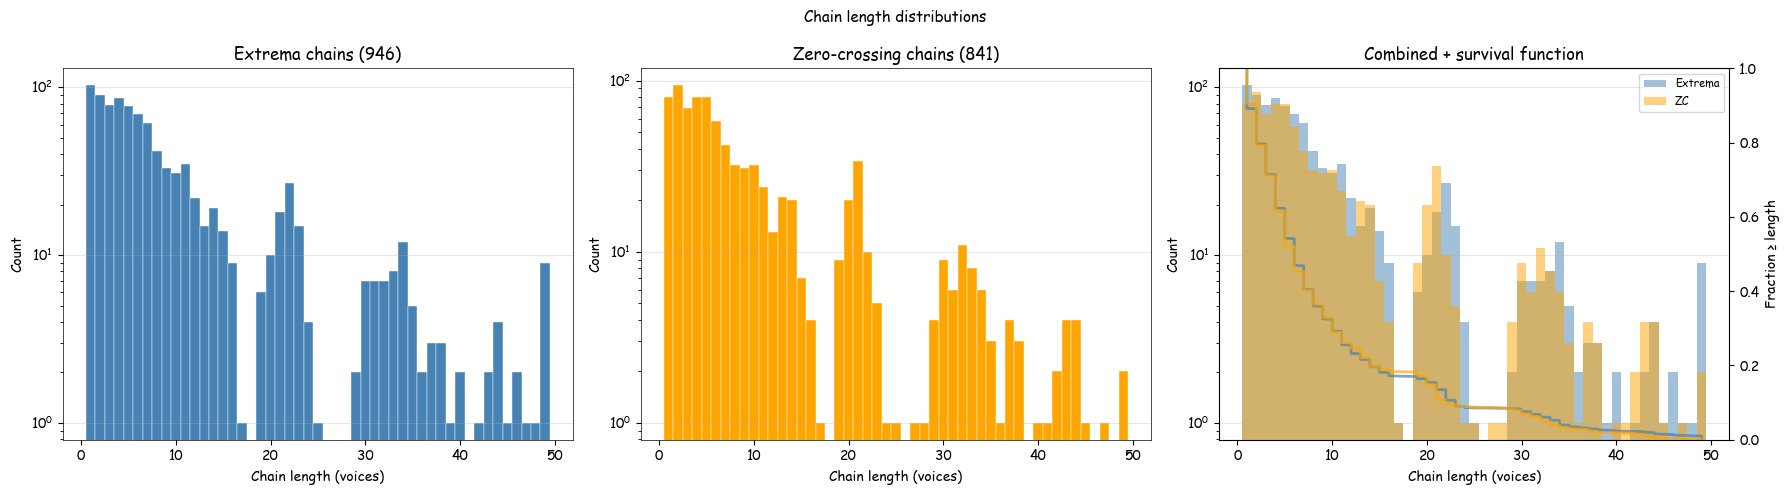


  Cutoff   Ext chains   Ext %    ZC chains    ZC %
       1          946  100.0%          841  100.0%
       2          843   89.1%          761   90.5%
       3          753   79.6%          667   79.3%
       5          589   62.3%          518   61.6%
      10          307   32.5%          275   32.7%
      15          185   19.6%          165   19.6%
      20          155   16.4%          144   17.1%
      25           81    8.6%           74    8.8%
      30           78    8.2%           67    8.0%
      40           23    2.4%           16    1.9%
      49            9    1.0%            2    0.2%


In [ ]:
# Cell 24b2: Chain length distributions — extrema and zero crossings
#
# Histogram of chain lengths (in voices) to choose a cutoff
# for the reconstruction. Longer chains = more persistent features.

# Trace extrema chains (post chain-delete, pre-chainmax ordinates don't matter here)
ext_chain_lengths = []
for fi in range(len(ea_c[0])):
    cs = 0
    ci = fi
    length = 0
    while cs < n_scales_c and ci != -1:
        length += 1
        ci = cl_c[cs][ci]
        cs += 1
    if length > 0:
        ext_chain_lengths.append(length)

# Trace ZC chains
zc_chain_lengths = []
for fi in range(len(zc_abs_c[0])):
    cs = 0
    ci = fi
    length = 0
    while cs < n_scales_c and ci != -1:
        length += 1
        ci = zc_cl_c[cs][ci]
        cs += 1
    if length > 0:
        zc_chain_lengths.append(length)

ext_chain_lengths = np.array(ext_chain_lengths)
zc_chain_lengths = np.array(zc_chain_lengths)

print(f'Extrema chains: {len(ext_chain_lengths)}')
print(f'  min={ext_chain_lengths.min()}, max={ext_chain_lengths.max()}, '
      f'mean={ext_chain_lengths.mean():.1f}, median={np.median(ext_chain_lengths):.0f}')
print(f'ZC chains: {len(zc_chain_lengths)}')
print(f'  min={zc_chain_lengths.min()}, max={zc_chain_lengths.max()}, '
      f'mean={zc_chain_lengths.mean():.1f}, median={np.median(zc_chain_lengths):.0f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

max_len = max(ext_chain_lengths.max(), zc_chain_lengths.max())
bins = np.arange(0.5, max_len + 1.5, 1)

# (0) Extrema chain lengths
ax = axes[0]
ax.hist(ext_chain_lengths, bins=bins, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Chain length (voices)')
ax.set_ylabel('Count')
ax.set_title(f'Extrema chains ({len(ext_chain_lengths)})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# (1) ZC chain lengths
ax = axes[1]
ax.hist(zc_chain_lengths, bins=bins, color='orange', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Chain length (voices)')
ax.set_ylabel('Count')
ax.set_title(f'Zero-crossing chains ({len(zc_chain_lengths)})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# (2) Both overlaid + cumulative
ax = axes[2]
ax2 = ax.twinx()
ax.hist(ext_chain_lengths, bins=bins, alpha=0.5, color='steelblue', label='Extrema')
ax.hist(zc_chain_lengths, bins=bins, alpha=0.5, color='orange', label='ZC')
ax.set_xlabel('Chain length (voices)')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(fontsize=8, loc='upper right')

# Cumulative: fraction of chains >= length
for lengths, color, label in [(ext_chain_lengths, 'steelblue', 'Ext'),
                                (zc_chain_lengths, 'orange', 'ZC')]:
    sorted_l = np.sort(lengths)
    cdf = 1 - np.arange(len(sorted_l)) / len(sorted_l)
    ax2.plot(sorted_l, cdf, '-', color=color, linewidth=2, alpha=0.7)
ax2.set_ylabel('Fraction ≥ length')
ax2.set_ylim(0, 1)

ax.set_title('Combined + survival function')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Chain length distributions', fontsize=11)
plt.tight_layout()
plt.show()

# Summary table: how many chains survive each cutoff
print(f'\n{"Cutoff":>8} {"Ext chains":>12} {"Ext %":>7} {"ZC chains":>12} {"ZC %":>7}')
for cutoff in [1, 2, 3, 5, 10, 15, 20, 25, 30, 40, n_scales_c]:
    ne = np.sum(ext_chain_lengths >= cutoff)
    nz = np.sum(zc_chain_lengths >= cutoff)
    print(f'{cutoff:>8} {ne:>12} {100*ne/len(ext_chain_lengths):>6.1f}% '
          f'{nz:>12} {100*nz/len(zc_chain_lengths):>6.1f}%')

Reconstructing from ALL 49 scales
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Inverse CWT computed in 0.524s

Valid range (coarsest scale): [2337, 3422] of 5760 samples (1086 interior points, trimming 2337 left + 2337 right)

Original  (interior): min=2554.0000, max=2903.0000, std=95.6567
Reconstructed (interior): min=4869.5285, max=5265.5851, std=99.5272
Residual std: 2.0044e+01
SNR (interior): 1.0 dB


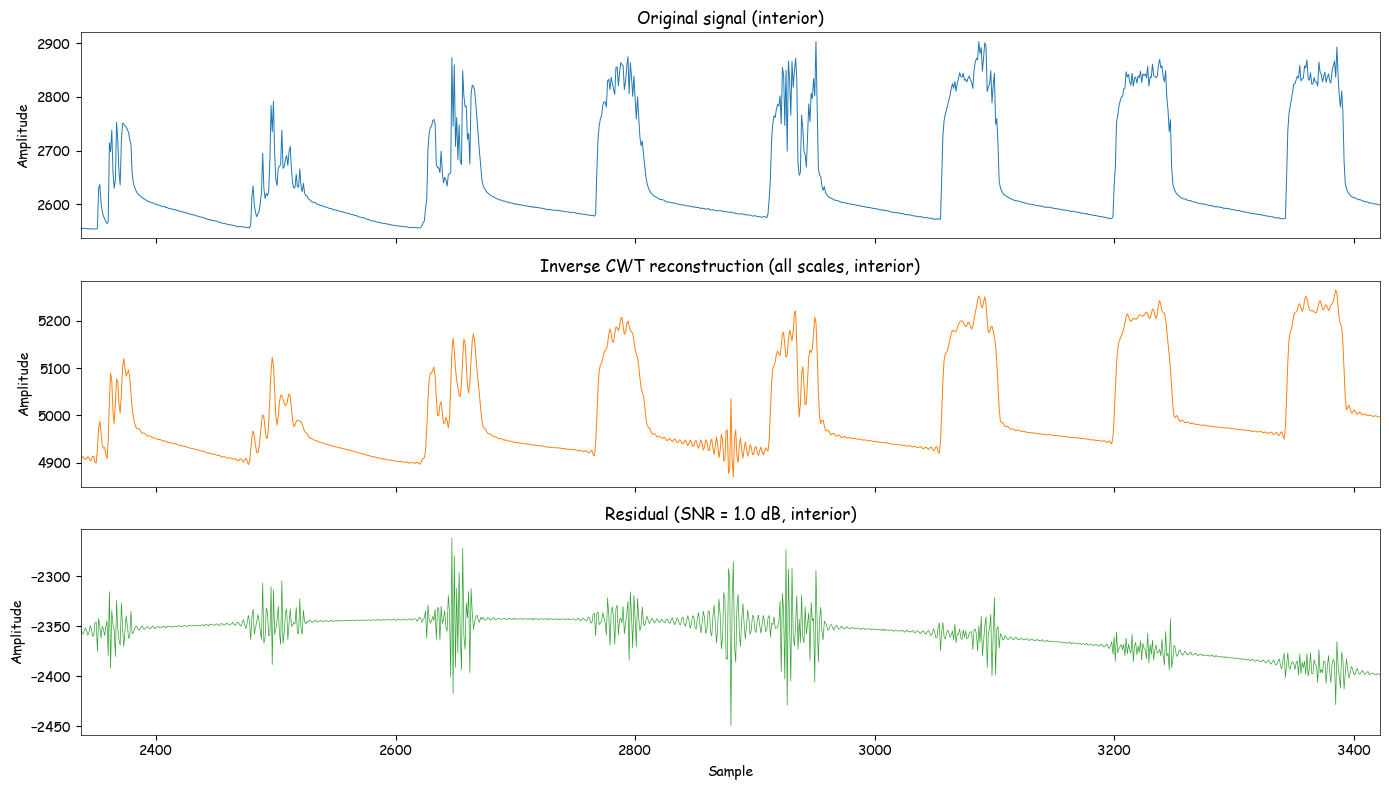

In [ ]:
# Cell 23b: Inverse CWT — reconstruct signal from selected scale range
#
# Sanity check: if adjoint is correct, reconstructing from ALL scales
# should recover the original signal (up to frame constant normalization).
# Partial scale ranges show band-passed contributions.

# ── Configure scale range (None = all scales) ──
# Use scale indices: 0 = finest, n_scales-1 = coarsest
# Or set to None for full reconstruction
scale_lo = None   # e.g. 0
scale_hi = None   # e.g. 20
scale_range = (scale_lo, scale_hi) if scale_lo is not None else None

n_scales_c = n_oct_c * n_voice_c
scales_all = [1.0 * 2.0 ** (j / n_voice_c) for j in range(n_scales_c)]

if scale_range is not None:
    print(f'Reconstructing from scales {scale_range[0]}..{scale_range[1]-1} '
          f'(a = {scales_all[scale_range[0]]:.2f} to {scales_all[scale_range[1]-1]:.2f})')
else:
    print(f'Reconstructing from ALL {n_scales_c} scales')

# Clear frame transfer cache to force recomputation
if hasattr(_get_frame_transfer, '_cache_key'):
    del _get_frame_transfer._cache_key

t0 = time.time()
x_inv = inverse_cwt_fftw(coeffs_c, a_min=1.0, n_oct=n_oct_c, n_voice=n_voice_c,
                          wavelet_name='g3', expo=-1.0, scale_range=scale_range)
t1 = time.time()
print(f'Inverse CWT computed in {t1-t0:.3f}s')

# ── Valid range (no edge effects) from coarsest scale ──
vl = valid_ranges_c[-1][0]   # firstp at coarsest scale
vr = valid_ranges_c[-1][1]   # lastp at coarsest scale
print(f'\nValid range (coarsest scale): [{vl}, {vr}] of {len(segment_c)} samples '
      f'({vr - vl + 1} interior points, trimming {vl} left + {len(segment_c)-1-vr} right)')

seg_v = segment_c[vl:vr+1]
inv_v = x_inv[vl:vr+1]
residual_v = seg_v - inv_v

# ── Compare with original (interior only) ──
print(f'\nOriginal  (interior): min={seg_v.min():.4f}, max={seg_v.max():.4f}, '
      f'std={seg_v.std():.4f}')
print(f'Reconstructed (interior): min={inv_v.min():.4f}, max={inv_v.max():.4f}, '
      f'std={inv_v.std():.4f}')

snr = 10 * np.log10(np.sum(seg_v**2) / (np.sum(residual_v**2) + 1e-30))
print(f'Residual std: {residual_v.std():.4e}')
print(f'SNR (interior): {snr:.1f} dB')

# ── Plot (interior only) ──
x_axis = np.arange(vl, vr + 1)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

axes[0].plot(x_axis, seg_v, lw=0.7)
axes[0].set_xlim(vl, vr)
axes[0].set_title('Original signal (interior)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(x_axis, inv_v, lw=0.7, color='C1')
axes[1].set_xlim(vl, vr)
label = f'scales {scale_range[0]}–{scale_range[1]-1}' if scale_range else 'all scales'
axes[1].set_title(f'Inverse CWT reconstruction ({label}, interior)')
axes[1].set_ylabel('Amplitude')

axes[2].plot(x_axis, residual_v, lw=0.5, color='C2')
axes[2].set_xlim(vl, vr)
axes[2].set_title(f'Residual (SNR = {snr:.1f} dB, interior)')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Sample')

plt.tight_layout()
plt.show()

Chain length cutoff: 5 voices
Extrema: 9212 -> 8351 (90.7%)
ZC:      8073 -> 7278 (90.2%)
Mask: 8351 maxima + 7278 ZC points = 22845 total (8.1% of scalogram)

Reconstructing from 22845 constraint points...
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
  Iter   1: rel_change = 9.61e-01
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
  Iter   2: rel_change = 1.01e+00
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
  Iter   3: rel_change = 1.02e+00
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
  Iter   4: rel_change = 1.00e+00
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| r

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_67710/2851496739.py:222: RuntimeWarning: invalid value encountered in scalar divide
  rel_change = np.linalg.norm(x_est - x_prev) / (np.linalg.norm(x_est) + 1e-30)


Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Frame transfer function computed: |H| range [1.03e-07, 6.50e+02], condition = 999841.3, reg = 6.50e-04
Reconstruction: 83.3s, 99 iterations


/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)
/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_67710/3642324036.py:91: RuntimeWarning: divide by zero encountered in log10
  snr = 10 * np.log10(np.var(segment_c) / (np.var(residual) + 1e-30))


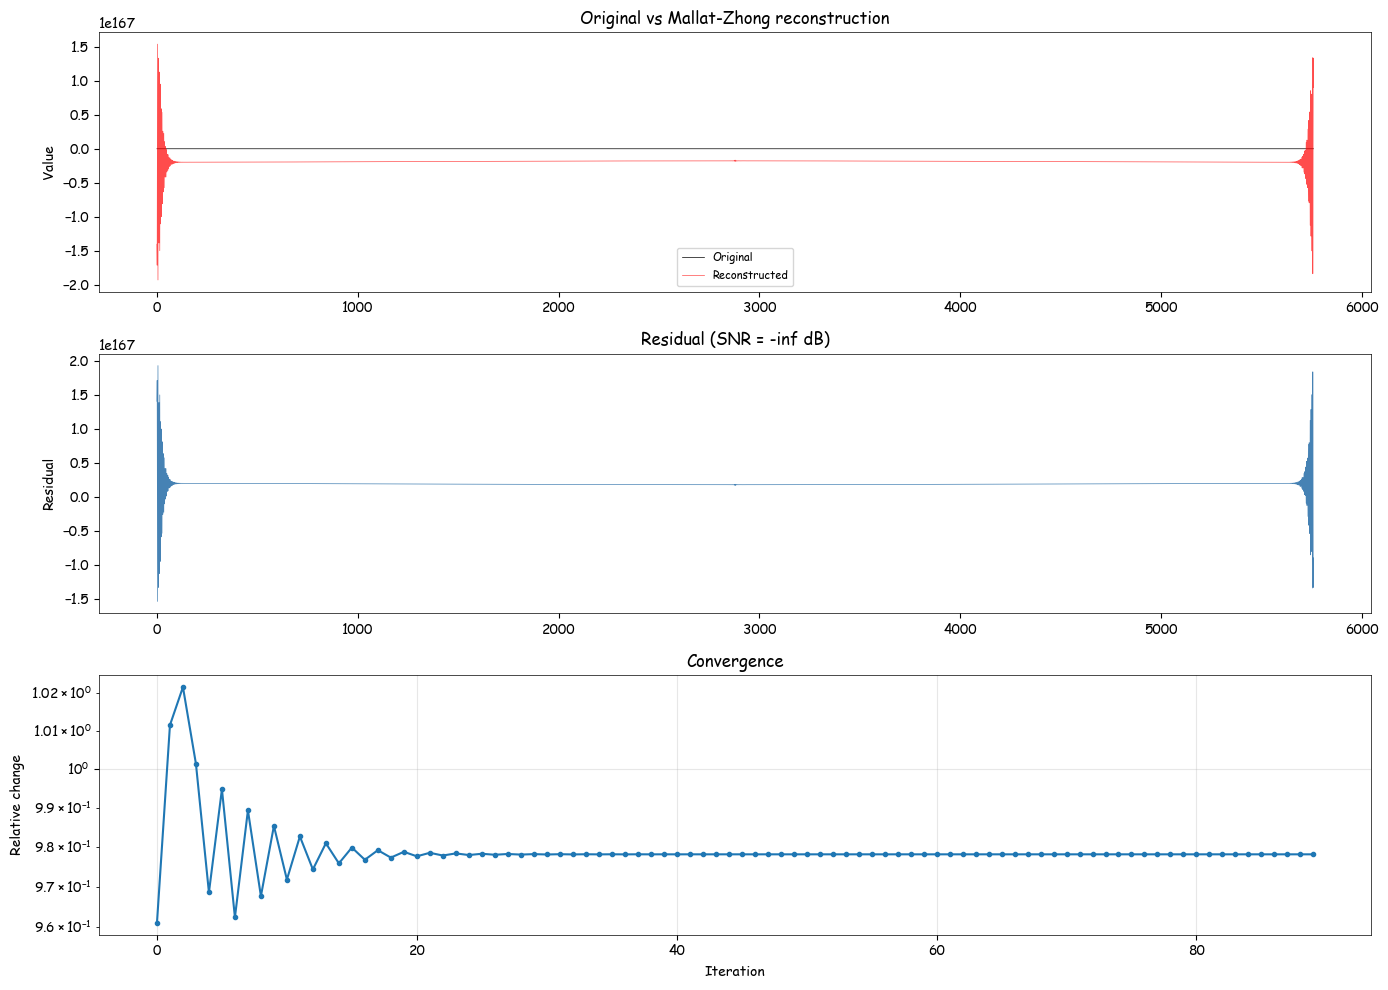


Reconstruction quality:
  SNR: -inf dB
  Max |residual|: 192723519591471407442396045081313480667398527030965771997110722001683805522097469092741203720907775556665631311032784745907725262492565501214292629408585347324809576448.0000
  RMS residual: inf
  Correlation: 0.00000000


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_67710/3642324036.py:109: RuntimeWarning: overflow encountered in square
  print(f'  RMS residual: {np.sqrt(np.mean(residual**2)):.4f}')
/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [ ]:
# Cell 24c: Mallat & Zhong reconstruction on creepmeter data
#
# Reconstruct the creepmeter signal from modulus maxima + zero crossings.
# This tests whether the extrema + ZC representation is sufficient
# for faithful signal recovery.

# ══════════════════════════════════════════════════════════════
# CONFIGURE: minimum chain length (voices) to include in reconstruction
# ══════════════════════════════════════════════════════════════
min_chain_length = 5  # only use chains with >= this many voices
# ══════════════════════════════════════════════════════════════

# Filter extrema: only keep those belonging to chains >= min_chain_length
ext_keep = [set() for _ in range(n_scales_c)]
for fi in range(len(ea_c[0])):
    chain_members = []
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        chain_members.append((cs, ci))
        ci = cl_c[cs][ci]
        cs += 1
    if len(chain_members) >= min_chain_length:
        for cs, ci in chain_members:
            ext_keep[cs].add(ci)

# Filter ZC: only keep those belonging to chains >= min_chain_length
zc_keep = [set() for _ in range(n_scales_c)]
for fi in range(len(zc_abs_c[0])):
    chain_members = []
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        chain_members.append((cs, ci))
        ci = zc_cl_c[cs][ci]
        cs += 1
    if len(chain_members) >= min_chain_length:
        for cs, ci in chain_members:
            zc_keep[cs].add(ci)

# Build filtered index arrays
ei_filt = []
zc_idx_filt = []
for s in range(n_scales_c):
    ei_filt.append(np.array([ei_c[s][k] for k in sorted(ext_keep[s])], dtype=np.int64) 
                   if ext_keep[s] else np.array([], dtype=np.int64))
    zc_idx_filt.append(np.array([zc_idx_c[s][k] for k in sorted(zc_keep[s])], dtype=np.int64)
                       if zc_keep[s] else np.array([], dtype=np.int64))

n_ext_kept = sum(len(a) for a in ei_filt)
n_zc_kept = sum(len(a) for a in zc_idx_filt)
n_ext_total = sum(len(a) for a in ei_c)
n_zc_total = sum(len(a) for a in zc_idx_c)
print(f'Chain length cutoff: {min_chain_length} voices')
print(f'Extrema: {n_ext_total} -> {n_ext_kept} ({100*n_ext_kept/n_ext_total:.1f}%)')
print(f'ZC:      {n_zc_total} -> {n_zc_kept} ({100*n_zc_kept/n_zc_total:.1f}%)')

# Build mask from filtered extrema + zero crossings
mask_c, known_c = build_maxima_zc_mask(
    coeffs_c, ea_c, eo_c, ei_filt, zc_abs_c, zc_idx_filt, n_scales_c)

# Reconstruct
print(f'\nReconstructing from {mask_c.sum()} constraint points...')
t0 = time.time()
x_recon, recon_errors = reconstruct_mallat_zhong(
    coeffs_c, mask_c, known_c,
    a_min=1.0, n_oct=n_oct_c, n_voice=n_voice_c,
    wavelet_name='g3', expo=-1.0,
    n_iter=100, tol=1e-8, verbose=True)
t1 = time.time()
print(f'Reconstruction: {t1-t0:.1f}s, {len(recon_errors)} iterations')

# Compare
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# (0) Original vs reconstructed
ax = axes[0]
ax.plot(segment_c, linewidth=0.5, label='Original', color='black')
ax.plot(x_recon, linewidth=0.5, label='Reconstructed', color='red', alpha=0.7)
ax.set_ylabel('Value')
ax.set_title('Original vs Mallat-Zhong reconstruction')
ax.legend(fontsize=8)

# (1) Residual
ax = axes[1]
residual = segment_c - x_recon[:len(segment_c)]
ax.plot(residual, linewidth=0.5, color='steelblue')
ax.set_ylabel('Residual')
snr = 10 * np.log10(np.var(segment_c) / (np.var(residual) + 1e-30))
ax.set_title(f'Residual (SNR = {snr:.1f} dB)')

# (2) Convergence
ax = axes[2]
if recon_errors:
    ax.semilogy(recon_errors, 'o-', markersize=3)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative change')
    ax.set_title('Convergence')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nReconstruction quality:')
print(f'  SNR: {snr:.1f} dB')
print(f'  Max |residual|: {np.max(np.abs(residual)):.4f}')
print(f'  RMS residual: {np.sqrt(np.mean(residual**2)):.4f}')
print(f'  Correlation: {np.corrcoef(segment_c, x_recon[:len(segment_c)])[0,1]:.8f}')

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_67710/2037151203.py:19: RuntimeWarning: divide by zero encountered in log10
  snr = 10 * np.log10(np.var(segment_c) / (np.var(residual) + 1e-30))


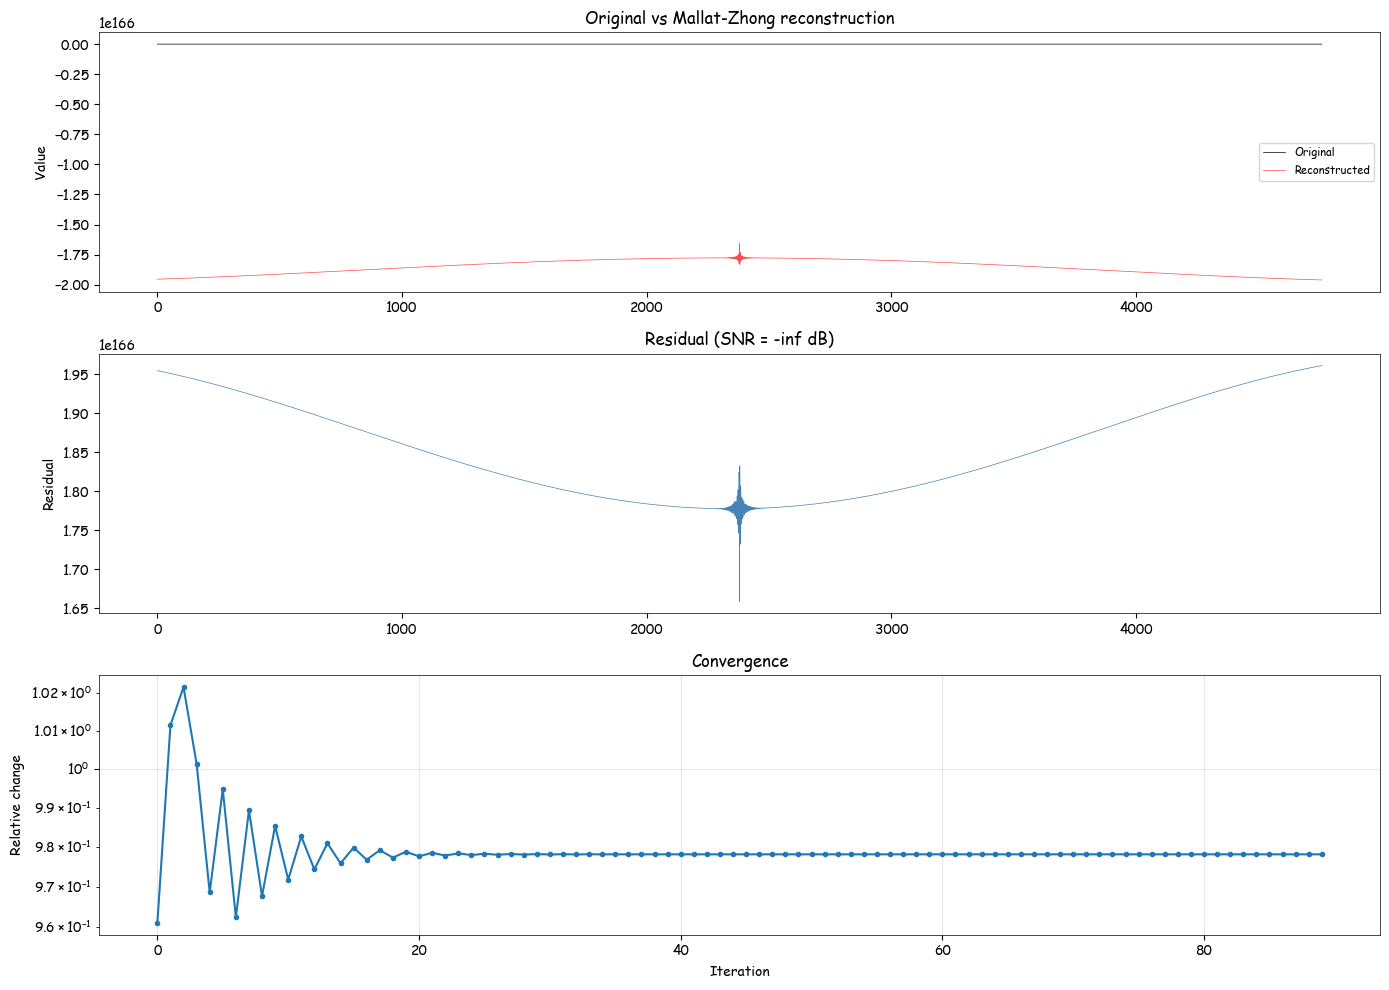


Reconstruction quality:
  SNR: -inf dB
  Max |residual|: 19611050318235282808427093980514487234403944295233188866781265041644727852705034579375283283682224141353759165913120397487440534033842085506412101098532440275991658496.0000
  RMS residual: inf
  Correlation: 0.00000000


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_67710/2037151203.py:37: RuntimeWarning: overflow encountered in square
  print(f'  RMS residual: {np.sqrt(np.mean(residual**2)):.4f}')


In [ ]:

# Compare
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
segd = segment_c[500:-500]
# (0) Original vs reconstructed
ax = axes[0]
ax.plot(segd, linewidth=0.5, label='Original', color='black')
ax.plot(x_recon[500:-500], linewidth=0.5, label='Reconstructed', color='red', alpha=0.7)
ax.set_ylabel('Value')
ax.set_title('Original vs Mallat-Zhong reconstruction')
ax.legend(fontsize=8)

# (1) Residual
ax = axes[1]
residual = segd - x_recon[500:-500][:len(segd)]
ax.plot(residual, linewidth=0.5, color='steelblue')
ax.set_ylabel('Residual')
snr = 10 * np.log10(np.var(segment_c) / (np.var(residual) + 1e-30))
ax.set_title(f'Residual (SNR = {snr:.1f} dB)')

# (2) Convergence
ax = axes[2]
if recon_errors:
    ax.semilogy(recon_errors, 'o-', markersize=3)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative change')
    ax.set_title('Convergence')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nReconstruction quality:')
print(f'  SNR: {snr:.1f} dB')
print(f'  Max |residual|: {np.max(np.abs(residual)):.4f}')
print(f'  RMS residual: {np.sqrt(np.mean(residual**2)):.4f}')
print(f'  Correlation: {np.corrcoef(segment_c, x_recon[:len(segment_c)])[0,1]:.8f}')

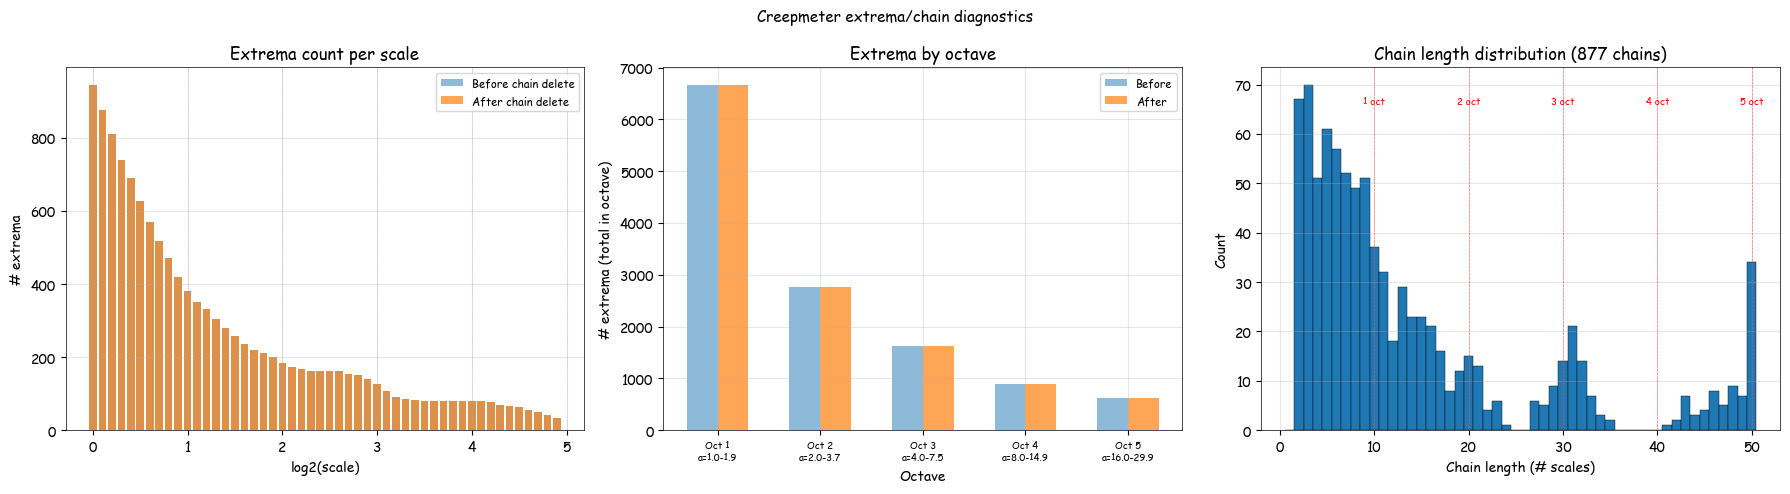

 Scale  log2(a)        a    Pre   Post  Deleted%
--------------------------------------------------
     0     0.00     1.00    946    946      0.0%
     1     0.10     1.07    877    877      0.0%
     2     0.20     1.15    810    810      0.0%
     3     0.30     1.23    740    740      0.0%
     4     0.40     1.32    689    689      0.0%
     5     0.50     1.41    628    628      0.0%
     6     0.60     1.52    571    571      0.0%
     7     0.70     1.62    519    519      0.0%
     8     0.80     1.74    470    470      0.0%
     9     0.90     1.87    420    419      0.2%
    10     1.00     2.00    382    382      0.0%
    11     1.10     2.14    350    350      0.0%
    12     1.20     2.30    332    332      0.0%
    13     1.30     2.46    303    303      0.0%
    14     1.40     2.64    280    280      0.0%
    15     1.50     2.83    257    257      0.0%
    16     1.60     3.03    236    236      0.0%
    17     1.70     3.25    220    220      0.0%
    18     1.80   

In [ ]:
# Cell 25b: Extrema count per scale — before and after chain processing
#
# Helps decide where to set regression range (log2_a_min, log2_a_max)
# and whether fine scales are dominated by tidal/noise extrema.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Counts before chain processing (from pre-deletion state)
pre_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    pre_counts[s] = len(pre_del_abs_c[s])

# Counts after chain_delete + chainmax
post_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    post_counts[s] = len(ea_c[s])

log2_scales_c = np.log2(scales_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Bar chart: extrema count per scale
ax = axes[0]
ax.bar(log2_scales_c, pre_counts, width=0.08, alpha=0.5, label='Before chain delete')
ax.bar(log2_scales_c, post_counts, width=0.08, alpha=0.7, label='After chain delete')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('# extrema')
ax.set_title('Extrema count per scale')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Mark octave boundaries
for o in range(n_oct_c + 1):
    ax.axvline(np.log2(1.0) + o, color='gray', ls=':', lw=0.5, alpha=0.5)

# (1) Extrema count by octave (grouped)
ax = axes[1]
octave_pre = np.zeros(n_oct_c)
octave_post = np.zeros(n_oct_c)
for o in range(n_oct_c):
    for v in range(n_voice_c):
        s = o * n_voice_c + v
        octave_pre[o] += pre_counts[s]
        octave_post[o] += post_counts[s]
x_oct = np.arange(n_oct_c)
ax.bar(x_oct - 0.15, octave_pre, width=0.3, alpha=0.5, label='Before')
ax.bar(x_oct + 0.15, octave_post, width=0.3, alpha=0.7, label='After')
ax.set_xlabel('Octave')
ax.set_ylabel('# extrema (total in octave)')
ax.set_xticks(x_oct)
ax.set_xticklabels([f'Oct {o+1}\na={scales_c[o*n_voice_c]:.1f}-{scales_c[min((o+1)*n_voice_c-1, n_scales_c-1)]:.1f}'
                     for o in range(n_oct_c)], fontsize=7)
ax.set_title('Extrema by octave')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) Chain length histogram
ax = axes[2]
chain_lengths = np.array([len(pos) for pos, sv, sign in post_del_chains_c])
ax.hist(chain_lengths, bins=np.arange(0.5, chain_lengths.max()+1.5, 1),
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Chain length (# scales)')
ax.set_ylabel('Count')
ax.set_title(f'Chain length distribution ({len(post_del_chains_c)} chains)')
ax.grid(True, alpha=0.3)
# Mark octave lengths
for o in range(1, n_oct_c + 1):
    ax.axvline(o * n_voice_c, color='red', ls='--', lw=0.5, alpha=0.5)
    ax.text(o * n_voice_c, ax.get_ylim()[1]*0.9, f'{o} oct', fontsize=7,
            ha='center', color='red')

plt.suptitle('Creepmeter extrema/chain diagnostics', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary table
print(f'{"Scale":>6} {"log2(a)":>8} {"a":>8} {"Pre":>6} {"Post":>6} {"Deleted%":>9}')
print('-' * 50)
for s in range(n_scales_c):
    pct = 100*(1 - post_counts[s]/pre_counts[s]) if pre_counts[s] > 0 else 0
    print(f'{s:6d} {log2_scales_c[s]:8.2f} {scales_c[s]:8.2f} {pre_counts[s]:6d} {post_counts[s]:6d} {pct:8.1f}%')


Scale threshold: 1.1 (log2a >= 0.00, a >= 1.0)
Chains reaching threshold: 877
Chains below threshold:    0


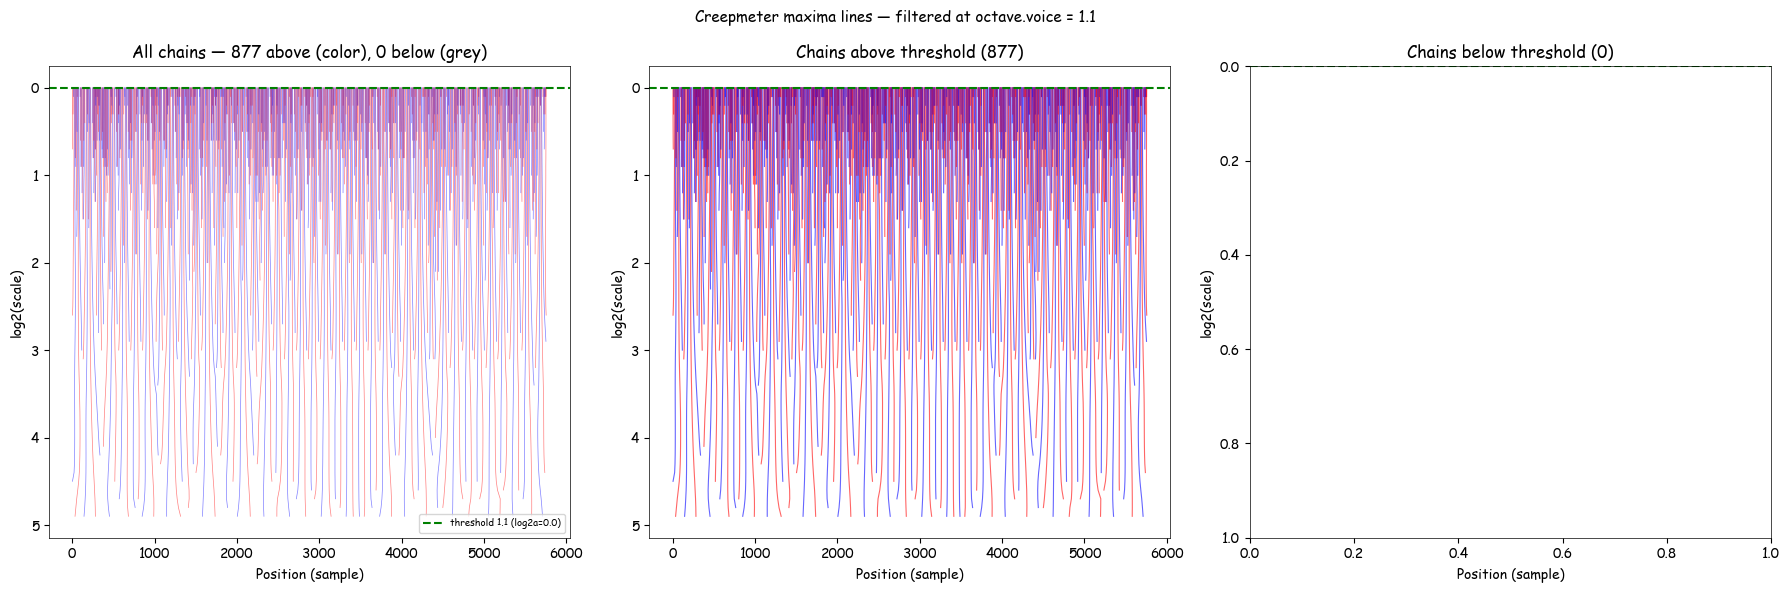


Above threshold: lengths min=2, max=50, median=9


In [ ]:
# Cell 25c: Extrema representation filtered by scale range
#
# Visualize only chains that reach above/below a scale threshold.
# Chains reaching coarser scales = large-scale singularities (creep events).
# Chains confined to fine scales = tidal/noise.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Configure scale threshold ──
scale_threshold_ov = 1.1  # octave.voice — chains must reach at least this scale
# 1.1 = finest scale, 2.1 = one octave up, 3.1 = two octaves up
# voice goes from 1 to n_voice_c (e.g. 2.6 = octave 2, voice 6)
scale_threshold = ov_to_log2a(scale_threshold_ov)

# Classify chains
chains_above = []  # chains reaching >= threshold
chains_below = []  # chains confined below threshold

for pos, sv, sign in post_del_chains_c:
    max_log2a = max(sv)  # coarsest scale reached by this chain
    if max_log2a >= scale_threshold:
        chains_above.append((pos, sv, sign))
    else:
        chains_below.append((pos, sv, sign))

print(f'Scale threshold: {scale_threshold_ov} (log2a >= {scale_threshold:.2f}, a >= {2**scale_threshold:.1f})')
print(f'Chains reaching threshold: {len(chains_above)}')
print(f'Chains below threshold:    {len(chains_below)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) All chains with threshold line
ax = axes[0]
for pos, sv, sign in chains_below:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.3, linewidth=0.5)
for pos, sv, sign in chains_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5, label=f'threshold {scale_threshold_ov} (log2a={scale_threshold:.1f})')
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'All chains — {len(chains_above)} above (color), {len(chains_below)} below (grey)')
ax.legend(fontsize=7)
ax.invert_yaxis()

# (1) Only chains above threshold
ax = axes[1]
for pos, sv, sign in chains_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.6, linewidth=0.8)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Chains above threshold ({len(chains_above)})')
ax.invert_yaxis()

# (2) Only chains below threshold
ax = axes[2]
for pos, sv, sign in chains_below:
    color = 'salmon' if sign > 0 else 'cornflowerblue'
    ax.plot(pos, sv, '-', color=color, alpha=0.4, linewidth=0.5)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Chains below threshold ({len(chains_below)})')
ax.invert_yaxis()

plt.suptitle(f'Creepmeter maxima lines — filtered at octave.voice = {scale_threshold_ov}', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Chain length stats by group
if chains_above:
    lens_above = [len(pos) for pos, sv, sign in chains_above]
    print(f'\nAbove threshold: lengths min={min(lens_above)}, max={max(lens_above)}, '
          f'median={np.median(lens_above):.0f}')
if chains_below:
    lens_below = [len(pos) for pos, sv, sign in chains_below]
    print(f'Below threshold: lengths min={min(lens_below)}, max={max(lens_below)}, '
          f'median={np.median(lens_below):.0f}')


In [51]:
# Cell 25d: Chain profiles — chainmax view (running supremum of |W|)
#
# For each chain, at each scale a we display sup{|W(a')| : a' <= a}.
# This is the chainmax operation: replacing each coefficient with the
# running maximum from finer scales, which removes smooth perturbations
# and isolates true singularities.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Trace chains, collecting raw CWT ordinates + running supremum ──
chain_profiles = []  # (log2_scales, log2_raw, log2_sup, sign, max_log2a)
for fi in range(len(ea_c[0])):
    log2_sc = []
    raw_vals = []
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        pos = ea_c[cs][ci]
        # Look up raw CWT coefficient at this position and scale
        idx = int(round(pos))
        if 0 <= idx < coeffs_c.shape[1]:
            raw_val = abs(coeffs_c[cs, idx])
        else:
            raw_val = 0.0
        if raw_val > 0:
            raw_vals.append(raw_val)
            log2_sc.append(np.log2(scales_c[cs]))
        ci = cl_c[cs][ci]
        cs += 1
    if len(log2_sc) > 1:
        # Compute running supremum from fine to coarse
        sup_vals = np.maximum.accumulate(raw_vals)
        sign = 1 if eo_c[0][fi] > 0 else -1
        chain_profiles.append((
            log2_sc,
            np.log2(raw_vals),
            np.log2(sup_vals),
            sign,
            max(log2_sc)
        ))

# Filter by scale threshold (from Cell 25c)
profiles_above = [p for p in chain_profiles if p[4] >= scale_threshold]
profiles_below = [p for p in chain_profiles if p[4] < scale_threshold]

print(f'Total chains: {len(chain_profiles)}')
print(f'Above threshold (log2a >= {scale_threshold}): {len(profiles_above)}')
print(f'Below threshold: {len(profiles_below)}')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Raw CWT coefficients along chains
ax = axes[0]
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_raw, '-', color=color, alpha=0.2, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2|W|')
ax.set_title(f'Raw |W| along chains ({len(profiles_above)} chains)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (1) Chainmax'd (running supremum)
ax = axes[1]
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.2, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title(f'Chainmax (running sup) along chains')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (2) Chainmax'd colored by slope (Hölder exponent h)
ax = axes[2]
slopes = []
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    if len(log2_sc) >= 3:
        slope, _ = np.polyfit(log2_sc, log2_sup, 1)
        slopes.append(slope)
        color = plt.cm.coolwarm((slope - 0) / 2.0)
        ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)

if slopes:
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
                                norm=plt.Normalize(vmin=min(slopes), vmax=max(slopes)))
    plt.colorbar(sm, ax=ax, label='slope ≈ h (Hölder exponent)')

ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title(f'Chainmax colored by slope (h)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

plt.suptitle('Chain profiles: raw vs chainmax (running supremum of |W|)', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

if slopes:
    slopes = np.array(slopes)
    print(f'\nChainmax slope (h) stats: mean={slopes.mean():.3f}, median={np.median(slopes):.3f}, '
          f'std={slopes.std():.3f}, range=[{slopes.min():.3f}, {slopes.max():.3f}]')

NameError: name 'scale_threshold' is not defined

Chains above threshold: 1350 original → 760 after trimming
Mean chain length: 15.5 → 14.4 scales
Total scale points trimmed: 5593
Extrema for PF: 10933


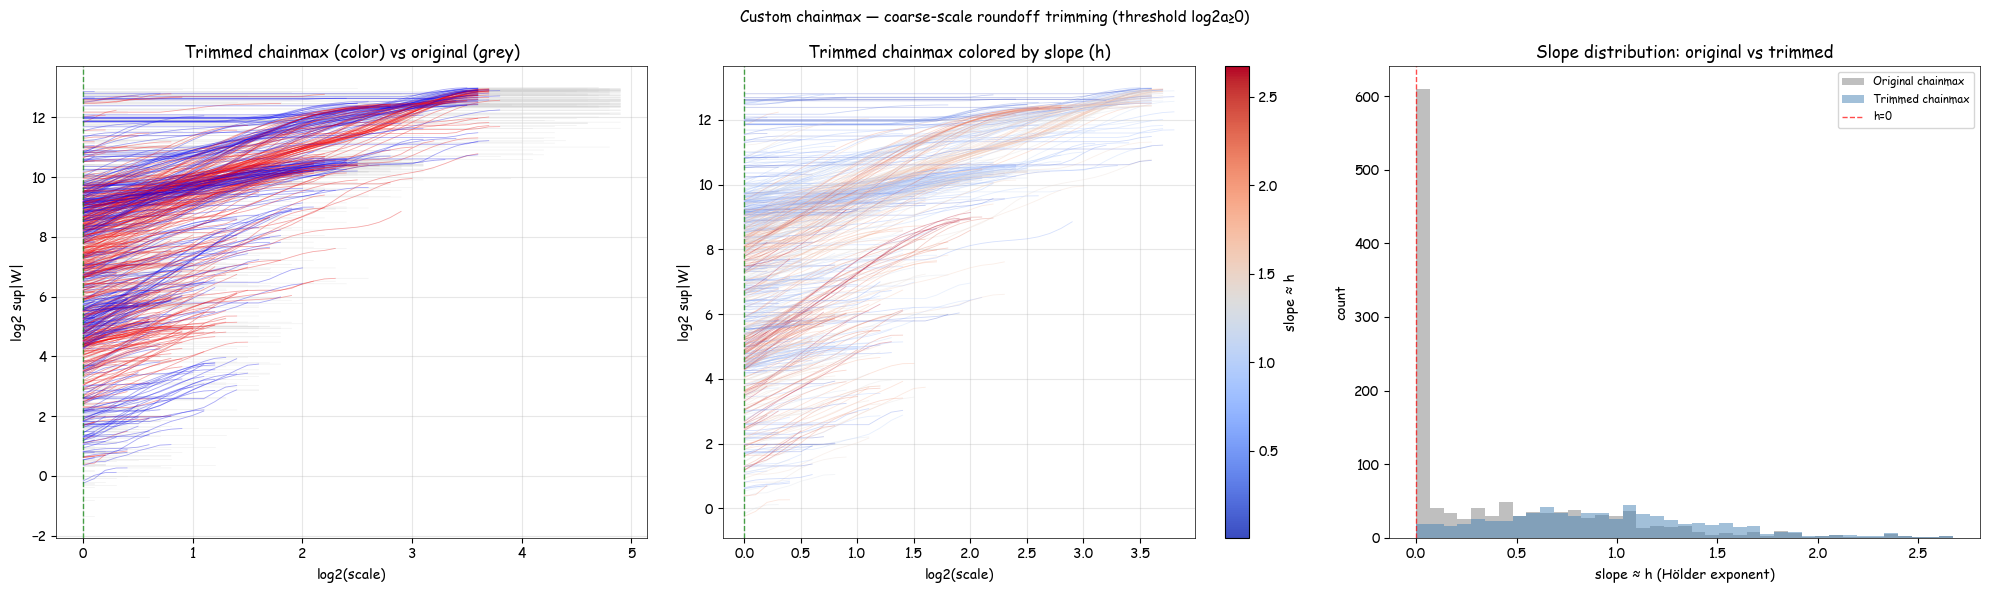


Trimmed slope stats: mean=0.930, median=0.890, std=0.534, range=[0.010, 2.673]
Chains with |h| < 0.1: 31 (4.5%)


In [ ]:
# Cell 25e: Custom chainmax — discard coarse-scale roundoff artifacts
#
# Standard chainmax walks fine→coarse keeping a running sup.
# Problem: at coarse scales, the CWT value can be dominated by roundoff
# or smooth components, giving |W(coarse)| < sup|W(fine)|. Standard
# chainmax replaces these with the sup, creating flat plateaus (h≈0).
#
# Fix: walk coarse→fine. At the coarsest end, if |W| < sup from finer
# scales, DISCARD that scale point entirely (don't include in PF).
# Once we reach the scale where the sup was achieved, resume normal
# chainmax from there downward.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Custom chainmax: trim coarse-scale roundoff ──
chain_profiles_trimmed = []  # (log2_scales, log2_sup, sign, max_log2a)

for fi in range(len(ea_c[0])):
    # First pass: collect raw |W| along chain (fine→coarse)
    chain_data = []  # list of (scale_idx, array_idx, log2_scale, raw_abs_val)
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        pos = ea_c[cs][ci]
        idx = int(round(pos))
        if 0 <= idx < coeffs_c.shape[1]:
            raw_val = abs(coeffs_c[cs, idx])
        else:
            raw_val = 0.0
        if raw_val > 0:
            chain_data.append((cs, ci, np.log2(scales_c[cs]), raw_val))
        ci = cl_c[cs][ci]
        cs += 1

    if len(chain_data) < 2:
        continue

    # Compute running sup from fine→coarse
    raw_vals = np.array([d[3] for d in chain_data])
    sup_fine_to_coarse = np.maximum.accumulate(raw_vals)

    # Find where the global sup is first achieved
    global_sup = sup_fine_to_coarse[-1]
    sup_scale_idx = len(raw_vals) - 1
    for k in range(len(raw_vals)):
        if raw_vals[k] >= global_sup:
            sup_scale_idx = k
            break

    # Walk from coarsest: trim scales where |W| < sup from finer scales
    # i.e., discard the coarse tail where the chain is just plateau
    trim_from = len(chain_data)  # keep everything by default
    for k in range(len(chain_data) - 1, sup_scale_idx, -1):
        if raw_vals[k] < sup_fine_to_coarse[k - 1]:
            trim_from = k  # discard this and coarser
        else:
            break  # found a scale where |W| exceeds prior sup — stop trimming

    # Trimmed chain: fine scales up to trim point
    trimmed = chain_data[:trim_from]
    if len(trimmed) < 2:
        continue

    trimmed_vals = np.array([d[3] for d in trimmed])
    trimmed_sup = np.maximum.accumulate(trimmed_vals)
    trimmed_log2s = [d[2] for d in trimmed]
    sign = 1 if eo_c[0][fi] > 0 else -1

    chain_profiles_trimmed.append((
        trimmed_log2s,
        np.log2(trimmed_vals),
        np.log2(trimmed_sup),
        sign,
        max(trimmed_log2s),
        # Also store (scale_idx, array_idx) for building filtered PF input
        [(d[0], d[1]) for d in trimmed]
    ))

# Filter by scale threshold
profiles_trimmed_above = [p for p in chain_profiles_trimmed if p[4] >= scale_threshold]

# Stats
n_orig_above = len([p for p in chain_profiles if p[4] >= scale_threshold])  # from Cell 25d
n_trimmed_above = len(profiles_trimmed_above)
orig_lengths = [len(p[0]) for p in chain_profiles if p[4] >= scale_threshold]
trimmed_lengths = [len(p[0]) for p in profiles_trimmed_above]

print(f'Chains above threshold: {n_orig_above} original → {n_trimmed_above} after trimming')
if orig_lengths and trimmed_lengths:
    print(f'Mean chain length: {np.mean(orig_lengths):.1f} → {np.mean(trimmed_lengths):.1f} scales')
    n_trimmed_pts = sum(o - t for o, t in zip(orig_lengths, trimmed_lengths) if o > t)
    print(f'Total scale points trimmed: {n_trimmed_pts}')

# ── Build filtered ordinates for PF (trimmed chains above threshold) ──
trimmed_members = [set() for _ in range(n_scales_c)]
for log2_sc, log2_raw, log2_sup, sign, max_l2a, member_indices in profiles_trimmed_above:
    for cs, ci in member_indices:
        trimmed_members[cs].add(ci)

eo_trimmed = []
for s in range(n_scales_c):
    indices = sorted(trimmed_members[s])
    if indices:
        # Use chainmax'd values: running sup of raw |W|
        # Recompute per-extremum: for each extremum in a chain, the sup up to that scale
        eo_trimmed.append(np.array([eo_c[s][i] for i in indices]))
    else:
        eo_trimmed.append(np.array([], dtype=np.float64))

n_ext_trimmed = sum(len(a) for a in eo_trimmed)
print(f'Extrema for PF: {n_ext_trimmed}')

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Original chainmax profiles (from 25d) vs trimmed
ax = axes[0]
for log2_sc, log2_raw, log2_sup, sign, _ in [p for p in chain_profiles if p[4] >= scale_threshold]:
    ax.plot(log2_sc, log2_sup, '-', color='lightgrey', alpha=0.3, linewidth=0.5)
for log2_sc, log2_raw, log2_sup, sign, _, _ in profiles_trimmed_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title('Trimmed chainmax (color) vs original (grey)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (1) Trimmed profiles colored by slope
ax = axes[1]
slopes_trimmed = []
for log2_sc, log2_raw, log2_sup, sign, _, _ in profiles_trimmed_above:
    if len(log2_sc) >= 3:
        slope, _ = np.polyfit(log2_sc, log2_sup, 1)
        slopes_trimmed.append(slope)
        color = plt.cm.coolwarm((slope - 0) / 2.0)
        ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)

if slopes_trimmed:
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
                                norm=plt.Normalize(vmin=min(slopes_trimmed), vmax=max(slopes_trimmed)))
    plt.colorbar(sm, ax=ax, label='slope ≈ h')

ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title('Trimmed chainmax colored by slope (h)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (2) Histogram: slope comparison original vs trimmed
ax = axes[2]
if len(slopes) > 0 and len(slopes_trimmed) > 0:  # slopes from Cell 25d
    bins = np.linspace(min(min(slopes), min(slopes_trimmed)),
                       max(max(slopes), max(slopes_trimmed)), 40)
    ax.hist(slopes, bins=bins, alpha=0.5, color='grey', label='Original chainmax')
    ax.hist(slopes_trimmed, bins=bins, alpha=0.5, color='steelblue', label='Trimmed chainmax')
    ax.axvline(0, color='red', ls='--', lw=1, alpha=0.7, label='h=0')
    ax.set_xlabel('slope ≈ h (Hölder exponent)')
    ax.set_ylabel('count')
    ax.set_title('Slope distribution: original vs trimmed')
    ax.legend(fontsize=8)

plt.suptitle(f'Custom chainmax — coarse-scale roundoff trimming (threshold log2a≥{scale_threshold})',
             fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

if slopes_trimmed:
    slopes_trimmed = np.array(slopes_trimmed)
    print(f'\nTrimmed slope stats: mean={slopes_trimmed.mean():.3f}, '
          f'median={np.median(slopes_trimmed):.3f}, '
          f'std={slopes_trimmed.std():.3f}, range=[{slopes_trimmed.min():.3f}, {slopes_trimmed.max():.3f}]')
    near_zero = np.sum(np.abs(slopes_trimmed) < 0.1)
    print(f'Chains with |h| < 0.1: {near_zero} ({100*near_zero/len(slopes_trimmed):.1f}%)')

Scale threshold: log2(a) >= 0
Extrema: 21055 total → 10933 after trimming (51.9%)
Partition function computed in 0.004s, up to scale index 38


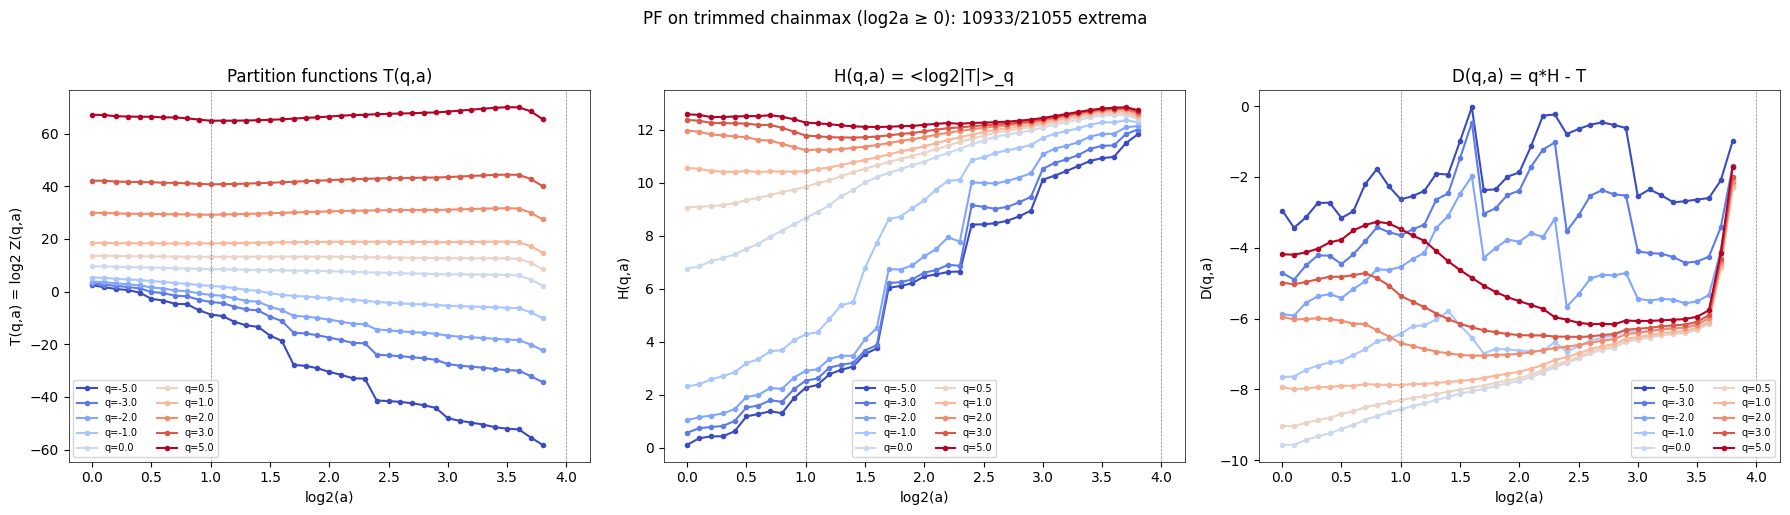

Gray dashed lines show regression range [log2(a)=1 to 4]


In [ ]:
# Cell 26: Partition functions on creepmeter data — trimmed chainmax
#
# Uses eo_trimmed from Cell 25e: coarse-scale roundoff artifacts discarded,
# only chains above scale_threshold, only surviving scale points.

q_list_c = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

n_ext_trimmed = sum(len(a) for a in eo_trimmed)
n_total = sum(len(eo_c[s]) for s in range(n_scales_c))
print(f'Scale threshold: log2(a) >= {scale_threshold}')
print(f'Extrema: {n_total} total → {n_ext_trimmed} after trimming ({100*n_ext_trimmed/n_total:.1f}%)')

t0 = time.time()
pf_c = compute_partition_function(eo_trimmed, n_oct=n_oct_c, n_voice=n_voice_c,
                                  a_min=1.0, q_list=q_list_c)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf_c["index_max"]}')

# Plot T(q,a), H(q,a), D(q,a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes.flatten():
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_ac = pf_c['log2_a']
valid_c = slice(0, pf_c['index_max'] + 1)
colors_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_c)))

ax = axes[0]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_T(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

ax = axes[1]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_H(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

ax = axes[2]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_D(pf_c, i, q)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'PF on trimmed chainmax (log2a ≥ {scale_threshold}): '
             f'{n_ext_trimmed}/{n_total} extrema', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')

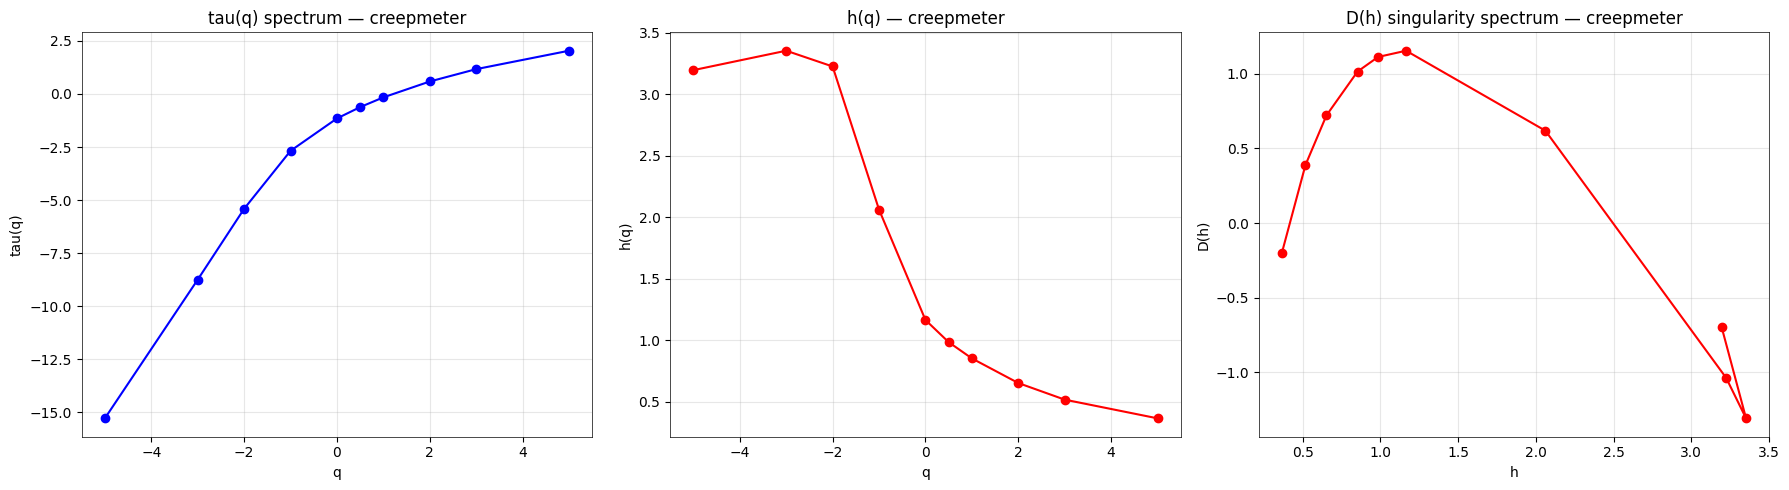


Creepmeter WTMM multifractal analysis:
q	 tau(q)		 h(q)		 D(q)
 -5.0	 -15.2778	   3.1945	  -0.6947
 -3.0	  -8.7474	   3.3523	  -1.3095
 -2.0	  -5.4106	   3.2244	  -1.0381
 -1.0	  -2.6806	   2.0617	   0.6190
  0.0	  -1.1552	   1.1656	   1.1552
  0.5	  -0.6205	   0.9856	   1.1133
  1.0	  -0.1619	   0.8536	   1.0155
  2.0	   0.5856	   0.6536	   0.7216
  3.0	   1.1670	   0.5186	   0.3889
  5.0	   2.0346	   0.3668	  -0.2005


In [ ]:
# Cell 27: tau(q), h(q), D(h) spectra for creepmeter data
# Adjust log2_a_min and log2_a_max based on visual inspection of Cell 14

reg_min_ov = 2.7  # octave.voice — regression range start
reg_max_ov = 4.7  # octave.voice — regression range end
spectra_c = compute_spectra(pf_c, log2_a_min=ov_to_log2a(reg_min_ov), log2_a_max=ov_to_log2a(reg_max_ov))
print(f'Regression range: {reg_min_ov} to {reg_max_ov} (log2a: {ov_to_log2a(reg_min_ov):.2f} to {ov_to_log2a(reg_max_ov):.2f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'ro-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'ro-', markersize=6)
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum — creepmeter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCreepmeter WTMM multifractal analysis:')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_c['q_list']):
    print(f'{q:5.1f}\t {spectra_c["tau_q"][i]:8.4f}\t {spectra_c["h_q"][i]:8.4f}\t {spectra_c["D_q"][i]:8.4f}')

In [ ]:
# Cell 28: Decimate creepmeter to hourly — 6 phase-shifted sub-signals
#
# 10-min sampling → every 6th sample = 1-hour sampling.
# Offsets 0..5 give 6 independent hourly series (like 6 "realizations").
# This is analogous to DemoWTMM1DDevilStair's 50 random realizations,
# except our "realizations" are phase offsets of the same physical process.

DECIM = 6  # decimation factor (10min × 6 = 60min = 1 hour)

# Build 6 hourly sub-signals
hourly_signals = []
for offset in range(DECIM):
    sub = segment_c[offset::DECIM].copy()
    hourly_signals.append(sub)
    
min_len = min(len(s) for s in hourly_signals)
print(f'Original signal: {len(segment_c)} samples at 10-min')
print(f'Decimated: {DECIM} sub-signals of {min_len} samples at 1-hour')
print(f'  (duration: {min_len / 24:.1f} days = {min_len / 24 / 365.25:.2f} years)')

# Plot all 6 overlaid
fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
for offset in range(DECIM):
    t_hr = np.arange(len(hourly_signals[offset])) / 24  # days
    ax.plot(t_hr, hourly_signals[offset], alpha=0.6, linewidth=0.5,
            label=f'offset {offset}')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (mm)')
ax.set_title(f'6 hourly sub-signals (decimation factor {DECIM})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: PF accumulation — matching LastWave's "pf add" (PFStandardAddition)
#
# Standard addition: element-wise sum of all 7 arrays, increment signalNumber.
# The intensive-mode accessors then divide by signalNumber to get averages.

def pf_standard_addition(pf_accum, pf_new):
    """Add pf_new into pf_accum in-place. Matches LastWave's PFStandardAddition.
    
    All 7 arrays are summed element-wise; signalNumber incremented.
    """
    for key in ['sTq', 'sTqLogT', 'logSTq', 'sTqLogT_sTq',
                'log2STq', 'sTqLogT_sTq2', 'logSTqSTqLogT_sTq']:
        pf_accum[key] += pf_new[key]
    
    pf_accum['signal_number'] += pf_new['signal_number']
    pf_accum['index_max'] = min(pf_accum['index_max'], pf_new['index_max'])

import copy

def pf_copy(pf):
    """Deep copy a partition function dict."""
    return {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in pf.items()}

print('pf_standard_addition() and pf_copy() defined.')

In [ ]:
# Cell 29: Full WTMM pipeline on each hourly sub-signal, accumulate with pf add
#
# Mirrors DemoWTMM1DDevilStair loop:
#   foreach i 0:nrepeat-1 {
#       cwtd w amin omax nv wavelet -b 'mir'
#       extrema w
#       chainmax w.extrep 1
#       if (i == 0) { pft = [pf wtmm w.extrep qlist] }
#       else { pft = [pf add pft [pf wtmm w.extrep qlist]] }
#   }

# Parameters — match the single-signal creepmeter analysis
n_oct_h = n_oct_c      # same octave count
n_voice_h = n_voice_c  # same voices per octave
a_min_h = 1.0
wavelet_h = 'g2'
expo_h = -1.0
q_list_h = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

pf_accumulated = None
t_total = time.time()

for offset in range(DECIM):
    sig = hourly_signals[offset][:min_len]  # trim to same length
    t0 = time.time()
    
    # 1. CWT
    coeffs_h, scales_h, vr_h = cwtd_batched(sig, a_min=a_min_h, n_oct=n_oct_h,
                                              n_voice=n_voice_h, wavelet_name=wavelet_h,
                                              expo=expo_h)
    
    # 2. Extrema
    ea_h, eo_h, ei_h = compute_extrep(coeffs_h, scales_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                       a_min=a_min_h, valid_ranges=vr_h,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain + delete + chainmax
    cl_h, fl_h = chain_all(ea_h, eo_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_delete_all(ea_h, eo_h, ei_h, cl_h, fl_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_max_wrapper(eo_h, cl_h, n_oct=n_oct_h, n_voice=n_voice_h, a_min=a_min_h, expo=1.0)
    
    # 4. Partition function
    pf_h = compute_partition_function(eo_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                      a_min=a_min_h, q_list=q_list_h)
    
    # 5. Accumulate
    if pf_accumulated is None:
        pf_accumulated = pf_copy(pf_h)
    else:
        pf_standard_addition(pf_accumulated, pf_h)
    
    n_ext_h = sum(len(a) for a in ea_h)
    t1 = time.time()
    print(f'  Offset {offset}: {len(sig)} samples, {n_ext_h} extrema after pruning, '
          f'index_max={pf_h["index_max"]}, {t1-t0:.2f}s')

print(f'\nTotal: {time.time() - t_total:.2f}s')
print(f'Accumulated {pf_accumulated["signal_number"]} realizations')
print(f'Combined index_max: {pf_accumulated["index_max"]}')

In [ ]:
# Cell 30: Intensive-mode partition functions — T, H, D vs log2(a)
#
# Intensive mode divides logSTq and sTqLogT_sTq by signalNumber,
# giving the *average* across realizations. This reduces noise in
# the scaling plots and gives more reliable regression slopes.

log2_ah = pf_accumulated['log2_a']
valid_h = slice(0, pf_accumulated['index_max'] + 1)
q_arr = pf_accumulated['q_list']
colors_h = plt.cm.coolwarm(np.linspace(0, 1, len(q_arr)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# T(q,a) — intensive
ax = axes[0]
for i, q in enumerate(q_arr):
    y = pf_get_T(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) intensive')
ax.set_title(f'Intensive T(q,a) — {pf_accumulated["signal_number"]} hourly sub-signals')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a) — intensive
ax = axes[1]
for i, q in enumerate(q_arr):
    y = pf_get_H(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a) intensive')
ax.set_title('Intensive H(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a) — intensive
ax = axes[2]
for i, q in enumerate(q_arr):
    y = pf_get_D(pf_accumulated, i, q, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) intensive')
ax.set_title('Intensive D(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'Hourly decimated creepmeter — intensive mode ({DECIM} realizations)', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show default regression range [log2(a)=1 to 4]. Adjust below if needed.')

In [ ]:
# Cell 31: tau(q), h(q), D(h) spectra — intensive mode, compared to single-signal extensive
#
# The intensive mode should give smoother, more reliable spectra because it
# averages the log-partition functions across 6 realizations before regression.

reg_min_ov_h = 2.1  # octave.voice — regression range start
reg_max_ov_h = 5.1  # octave.voice — regression range end
spectra_h = compute_spectra(pf_accumulated, log2_a_min=ov_to_log2a(reg_min_ov_h), log2_a_max=ov_to_log2a(reg_max_ov_h), mode='intensive')
print(f'Regression range: {reg_min_ov_h} to {reg_max_ov_h} (log2a: {ov_to_log2a(reg_min_ov_h):.2f} to {ov_to_log2a(reg_max_ov_h):.2f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# tau(q)
ax = axes[0]
ax.plot(spectra_h['q_list'], spectra_h['tau_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
ax.plot(spectra_h['q_list'], spectra_h['h_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q)')
ax.legend()
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
ax.plot(spectra_h['h_q'], spectra_h['D_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Intensive (hourly decimated) vs Extensive (single signal)', y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(f'\nIntensive WTMM ({DECIM} hourly sub-signals):')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_h['q_list']):
    print(f'{q:5.1f}\t {spectra_h["tau_q"][i]:8.4f}\t {spectra_h["h_q"][i]:8.4f}\t {spectra_h["D_q"][i]:8.4f}')